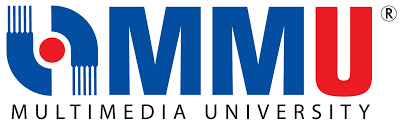

# CDS6344 Social Media Computing  
## Assignment Part 3: Project Code Repository  

### Project Title  
**Aspect-Based Sentiment Analysis of Social Networking App Reviews Using Machine Learning and Transformer Models**

### Group Information  

| Group Number | Student Name | Student ID |
|---|---|---|
| 9 | Venggadanaathan | 1231303562 |
| 9 | Tharraniah Tamilwanan | 1211111799 |

### Dataset  
**AWARE_Social_Networking.csv**

### Notebook 3 Purpose  
This notebook performs the third part of the project pipeline:

1. Loading cleaned datasets from Notebook 1 and Notebook 2  
2. Preparing train-test splits  
3. Training traditional machine learning models  
4. Training a deep learning model  
5. Training a transformer-based model  
6. Evaluating all models using accuracy, precision, recall, macro F1-score, weighted F1-score, and confusion matrices  
7. Comparing models and selecting the best-performing approach  
8. Exporting final model results for the report, presentation, and GitHub repository  

### Main Focus of Notebook 3  
Notebook 3 focuses on **model training and evaluation**.

It includes two modelling tasks:

1. **Task A: Rating-Based Review-Level Sentiment Classification**  
   - Input: full review text  
   - Target: rating-based sentiment created from the 1–5 rating column  
   - Classes: Positive, Neutral, Negative  

2. **Task B: Aspect-Level Sentiment Classification**  
   - Input: sentence + aspect category + aspect term  
   - Target: aspect sentiment  
   - Classes: positive, negative  

# 1. Notebook 3 Modelling Plan

This notebook trains and compares several sentiment classification models.

## Task A: Rating-Based Review-Level Sentiment Classification

This task uses the review-level dataset created in Notebook 1.

| Item | Description |
|---|---|
| Dataset | `review_level_social_reviews.csv` |
| Input text | `ml_clean_review` |
| Target label | `rating_sentiment` |
| Classes | Positive, Neutral, Negative |
| Purpose | Uses the 1–5 rating column required for the assignment |

## Task B: Aspect-Level Sentiment Classification

This task uses the aspect-level dataset created in Notebook 1.

| Item | Description |
|---|---|
| Dataset | `aspect_level_social_reviews.csv` |
| Input text | `aspect_model_input_ml` or `aspect_model_input` |
| Target label | `sentiment` |
| Classes | positive, negative |
| Purpose | Main ABSA modelling task |

## Models Planned

| Model Type | Models |
|---|---|
| Traditional ML | Naive Bayes, Logistic Regression, Linear SVM, Random Forest |
| Deep Learning | BiLSTM |
| Transformer | DistilBERT |

## Evaluation Metrics

Every model will be evaluated using:

- Accuracy  
- Precision  
- Recall  
- Macro F1-score  
- Weighted F1-score  
- Confusion matrix  
- Classification report  

Macro F1-score is important because the review-level dataset has a smaller Neutral class.

# 2. Required Input Files

Upload the following cleaned dataset files:

```text
review_level_social_reviews.csv
aspect_level_social_reviews.csv

# **Install Required Libraries**

In [84]:
# This cell installs libraries needed for traditional machine
# learning, deep learning, and transformer-based modelling.
#
# scikit-learn: traditional ML models and evaluation
# tensorflow: BiLSTM model
# transformers + torch: DistilBERT transformer model
# ============================================================

!pip install -q scikit-learn tensorflow transformers torch accelerate

print("Required libraries installed successfully.")

Required libraries installed successfully.


# **Import Libraries**

In [85]:
# This cell imports all libraries required for:
# - data loading
# - train-test splitting
# - TF-IDF feature extraction
# - traditional ML models
# - deep learning model
# - transformer model
# - evaluation and visualization
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
import zipfile
import shutil
import warnings
import random

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# TensorFlow / Keras for BiLSTM
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping

# PyTorch and Transformers for DistilBERT
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# **Set Random Seeds**

In [86]:
# This cell improves reproducibility.
#
# Results may still vary slightly in deep learning models,
# especially when using GPU, but this helps keep outputs stable.
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seeds set to:", SEED)

Random seeds set to: 42


# **Set Chart Style**

In [87]:
# This cell sets a consistent style for all Notebook 3 charts.
# The same colors are used across Notebook 1, 2, and 3.
# ============================================================

sns.set_theme(style="whitegrid")

SENTIMENT_COLORS = {
    "Positive": "#2EAD65",
    "Neutral": "#F2B84B",
    "Negative": "#D94F4F",
    "positive": "#2EAD65",
    "negative": "#D94F4F",
    "neutral": "#F2B84B"
}

MAIN_BLUE = "#2563EB"
MAIN_PURPLE = "#7C3AED"
MAIN_ORANGE = "#F97316"
MAIN_TEAL = "#0D9488"
MAIN_RED = "#DC2626"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"

print("Chart style configured successfully.")

Chart style configured successfully.


# **Create Clean Output Folders**

In [88]:
# This cell creates clean output folders for Notebook 3.
#
# Existing Notebook 3 output folders are cleared first to avoid
# mixing old results with final results.
# ============================================================

output_folders = [
    "results_notebook3",
    "visualizations_notebook3",
    "exports_notebook3",
    "models_notebook3"
]

for folder in output_folders:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

print("Clean Notebook 3 folders created:")
print("- results_notebook3/")
print("- visualizations_notebook3/")
print("- exports_notebook3/")
print("- models_notebook3/")

Clean Notebook 3 folders created:
- results_notebook3/
- visualizations_notebook3/
- exports_notebook3/
- models_notebook3/


# **Helper Function for Bar Labels**

In [89]:
# This helper function adds value labels to bar charts.
# It improves readability for report and presentation visuals.
# ============================================================

def add_bar_labels(ax, fmt="{:.0f}", padding=3):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=9)

# **Check GPU Availability**

In [90]:
# This cell checks whether a GPU is available.
#
# GPU is useful for BiLSTM and especially DistilBERT.
# In Colab, use:
# Runtime > Change runtime type > T4 GPU
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Traditional ML will run fine, but DistilBERT may be slow.")

PyTorch device: cuda
GPU name: Tesla T4


# **Upload Required Datasets**

In [91]:
# Upload the two cleaned CSV files from Notebook 1:
#
# 1. review_level_social_reviews.csv
# 2. aspect_level_social_reviews.csv
#
# Optional:
# - final_aspect_level_social_reviews_with_opinion_features.csv
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving aspect_level_social_reviews.csv to aspect_level_social_reviews.csv
Saving AWARE_Social_Networking.csv to AWARE_Social_Networking.csv
Saving final_aspect_level_social_reviews_with_opinion_features.csv to final_aspect_level_social_reviews_with_opinion_features.csv
Saving review_level_social_reviews.csv to review_level_social_reviews.csv


# **Load Review-Level and Aspect-Level Datasets**

In [92]:
# This cell loads the two main modelling datasets.
#
# review_df:
# - one row per unique review
# - used for rating-based document-level sentiment classification
#
# aspect_df:
# - one row per aspect-level sentence/aspect entry
# - used for ABSA sentiment classification
# ============================================================

review_file = "review_level_social_reviews.csv"
aspect_file = "aspect_level_social_reviews.csv"

review_df = pd.read_csv(review_file)
aspect_df = pd.read_csv(aspect_file)

print("Review-level dataset loaded successfully.")
print("Review-level shape:", review_df.shape)

print("\nAspect-level dataset loaded successfully.")
print("Aspect-level shape:", aspect_df.shape)

display(review_df.head())
display(aspect_df.head())

Review-level dataset loaded successfully.
Review-level shape: (1615, 10)

Aspect-level dataset loaded successfully.
Aspect-level shape: (3097, 20)


,domain,app,review_id,title,review,rating,rating_sentiment,basic_clean_review,ml_clean_review,review_word_count
0,social networking,whatsapp-messenger,aa65ef9e-27c0-496e-be43-089c1b186ff9,Need video call through WhatsApp Web,I like WhatsApp to talk to friends that aren’t...,4,Positive,i like whatsapp to talk to friends that are no...,like whatsapp talk friend not america recently...,96
1,social networking,discord,fb8b4293-2956-446e-9181-02ed3ceff8ac,Sharing Screens,"As a mobile user, it is unfortunate that we ca...",4,Positive,as a mobile user it is unfortunate that we can...,mobile user unfortunate cannot share screen mo...,170
2,social networking,teamspeak-3,b9c54729-6dea-44da-877e-f1891cf977c6,Great!!,Does everything the desktop app does! Slight b...,5,Positive,does everything the desktop app does slight bu...,everything desktop app slight bug switching wi...,49
3,social networking,free-tone-calling-texting,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,"Deleted my credits and history, changed my number",I logged in today and my credits and history w...,1,Negative,i logged in today and my credits and history w...,logged today credit history gone number change...,197
4,social networking,discord,86ed17e1-571f-47ba-b405-d2b7991a3a42,Wow!,"I’ve been using Skype for years as a gamer, an...",5,Positive,i ve been using skype for years as a gamer and...,using skype year gamer liked mobile recent upd...,136


,domain,app,review_id,sentence_id,title,review,sentence,rating,rating_sentiment,is_opinion,category,term,from,to,sentiment,basic_clean_sentence,ml_clean_sentence,sentence_word_count,aspect_model_input,aspect_model_input_ml
0,social networking,whatsapp-messenger,aa65ef9e-27c0-496e-be43-089c1b186ff9,00437139-ab26-4f42-8050-8b464b0a90cd,Need video call through WhatsApp Web,I like WhatsApp to talk to friends that aren’t...,I just drained about 15-20 percent of my phone...,4,Positive,True,efficiency,video call,67.0,77.0,negative,i just drained about percent of my phone batte...,drained percent phone battery video call bet l...,24,i just drained about percent of my phone batte...,drained percent phone battery video call bet l...
1,social networking,discord,fb8b4293-2956-446e-9181-02ed3ceff8ac,007ecad5-2bd1-47de-b94c-4c367b7e2c59,Sharing Screens,"As a mobile user, it is unfortunate that we ca...","On an iPad Pro, I would honestly expect somewa...",4,Positive,True,effectiveness,share,52.0,57.0,negative,on an ipad pro i would honestly expect someway...,ipad pro would honestly expect someway share s...,18,on an ipad pro i would honestly expect someway...,ipad pro would honestly expect someway share s...
2,social networking,teamspeak-3,b9c54729-6dea-44da-877e-f1891cf977c6,0097e9d8-fe91-45d1-b66f-3e6cac36459e,Great!!,Does everything the desktop app does! Slight b...,Would be awesome if you could press the volume...,5,Positive,True,usability,volume,41.0,47.0,negative,would be awesome if you could press the volume...,would awesome could press volume button activa...,25,would be awesome if you could press the volume...,would awesome could press volume button activa...
3,social networking,free-tone-calling-texting,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,00a23065-9b78-483b-8bf3-21f1fe59bad8,"Deleted my credits and history, changed my number",I logged in today and my credits and history w...,I've always had trouble with the alerts not wo...,1,Negative,True,reliability,phone call,66.0,76.0,negative,i ve always had trouble with the alerts not wo...,always trouble alert not working get phone cal...,18,i ve always had trouble with the alerts not wo...,always trouble alert not working get phone cal...
4,social networking,discord,86ed17e1-571f-47ba-b405-d2b7991a3a42,0172311b-9191-45f5-a119-8bab09e21358,Wow!,"I’ve been using Skype for years as a gamer, an...",But the mobile recent update just killed it.,5,Positive,True,general,recent update,16.0,29.0,negative,but the mobile recent update just killed it,mobile recent update killed,8,but the mobile recent update just killed it [S...,mobile recent update killed sep general sep re...


# **Load Optional Notebook 2 Dataset if Available**

In [93]:
# If the final Notebook 2 dataset was uploaded, this cell loads it.
# Otherwise, it continues without error.
#
# This optional dataset includes opinion mining features.
# The main model training can proceed without it.
# ============================================================

optional_file = "final_aspect_level_social_reviews_with_opinion_features.csv"

if optional_file in uploaded.keys():
    aspect_opinion_df = pd.read_csv(optional_file)
    print("Optional Notebook 2 opinion-feature dataset loaded.")
    print("Shape:", aspect_opinion_df.shape)
else:
    aspect_opinion_df = None
    print("Optional Notebook 2 opinion-feature dataset not uploaded. Continuing with main datasets.")

Optional Notebook 2 opinion-feature dataset loaded.
Shape: (3097, 29)


# **Validate Required Columns**

In [94]:
# This cell checks whether all required columns exist before
# starting model training.
# ============================================================

required_review_columns = [
    "review_id",
    "review",
    "rating",
    "rating_sentiment",
    "basic_clean_review",
    "ml_clean_review"
]

required_aspect_columns = [
    "review_id",
    "sentence_id",
    "sentence",
    "category",
    "term",
    "sentiment",
    "basic_clean_sentence",
    "ml_clean_sentence",
    "aspect_model_input",
    "aspect_model_input_ml"
]

missing_review_columns = [
    col for col in required_review_columns
    if col not in review_df.columns
]

missing_aspect_columns = [
    col for col in required_aspect_columns
    if col not in aspect_df.columns
]

if len(missing_review_columns) == 0:
    print("All required review-level columns are available.")
else:
    print("Missing review-level columns:")
    print(missing_review_columns)

if len(missing_aspect_columns) == 0:
    print("\nAll required aspect-level columns are available.")
else:
    print("\nMissing aspect-level columns:")
    print(missing_aspect_columns)

All required review-level columns are available.

All required aspect-level columns are available.


# **Dataset Information**

In [95]:
# This cell displays data types and non-null counts.
#
# Assignment usage:
# - Confirms dataset readiness before modelling
# - Supports Methodology if needed
# ============================================================

print("Review-level dataset info:")
review_df.info()

print("\n" + "=" * 80 + "\n")

print("Aspect-level dataset info:")
aspect_df.info()

Review-level dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   domain              1615 non-null   object
 1   app                 1615 non-null   object
 2   review_id           1615 non-null   object
 3   title               1615 non-null   object
 4   review              1615 non-null   object
 5   rating              1615 non-null   int64 
 6   rating_sentiment    1615 non-null   object
 7   basic_clean_review  1615 non-null   object
 8   ml_clean_review     1615 non-null   object
 9   review_word_count   1615 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 126.3+ KB


Aspect-level dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3097 entries, 0 to 3096
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  ----- 

# **Missing Values Check**

In [96]:
# This cell checks missing values in both modelling datasets.
#
# Important:
# Model input and target columns must not contain missing values.
# ============================================================

review_missing = review_df.isnull().sum().sort_values(ascending=False)
aspect_missing = aspect_df.isnull().sum().sort_values(ascending=False)

print("Missing values in review-level dataset:")
print(review_missing)

print("\nMissing values in aspect-level dataset:")
print(aspect_missing)

Missing values in review-level dataset:
domain                0
app                   0
review_id             0
title                 0
review                0
rating                0
rating_sentiment      0
basic_clean_review    0
ml_clean_review       0
review_word_count     0
dtype: int64

Missing values in aspect-level dataset:
from                     18
to                       18
domain                    0
app                       0
sentence_id               0
review_id                 0
title                     0
review                    0
rating_sentiment          0
is_opinion                0
sentence                  0
rating                    0
term                      0
category                  0
sentiment                 0
basic_clean_sentence      0
ml_clean_sentence         0
sentence_word_count       0
aspect_model_input        0
aspect_model_input_ml     0
dtype: int64


# **Class Distribution Tables**

In [97]:
# This cell checks class distribution for both modelling tasks.
#
# Task A:
# - rating_sentiment: Positive, Neutral, Negative
#
# Task B:
# - sentiment: positive, negative
# ============================================================

review_class_distribution = (
    review_df["rating_sentiment"]
    .value_counts()
    .reset_index()
)

review_class_distribution.columns = ["Class", "Count"]

review_class_distribution["Percentage"] = (
    review_class_distribution["Count"] /
    review_class_distribution["Count"].sum() * 100
).round(2)

aspect_class_distribution = (
    aspect_df["sentiment"]
    .value_counts()
    .reset_index()
)

aspect_class_distribution.columns = ["Class", "Count"]

aspect_class_distribution["Percentage"] = (
    aspect_class_distribution["Count"] /
    aspect_class_distribution["Count"].sum() * 100
).round(2)

review_class_distribution.to_csv(
    "results_notebook3/review_class_distribution.csv",
    index=False
)

aspect_class_distribution.to_csv(
    "results_notebook3/aspect_class_distribution.csv",
    index=False
)

print("Review-level class distribution:")
display(review_class_distribution)

print("\nAspect-level class distribution:")
display(aspect_class_distribution)

Review-level class distribution:


,Class,Count,Percentage
0,Positive,804,49.78
1,Negative,551,34.12
2,Neutral,260,16.10



Aspect-level class distribution:


,Class,Count,Percentage
0,negative,1715,55.38
1,positive,1382,44.62


# **Class Distribution Charts**

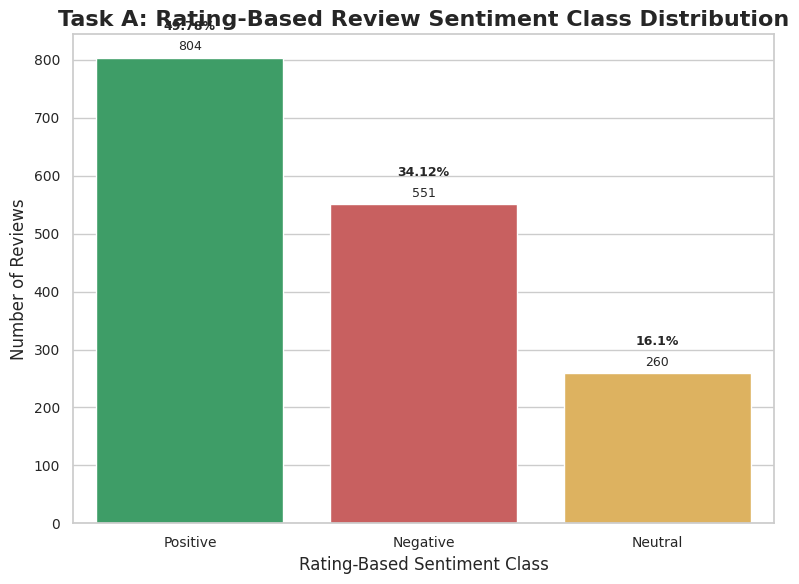

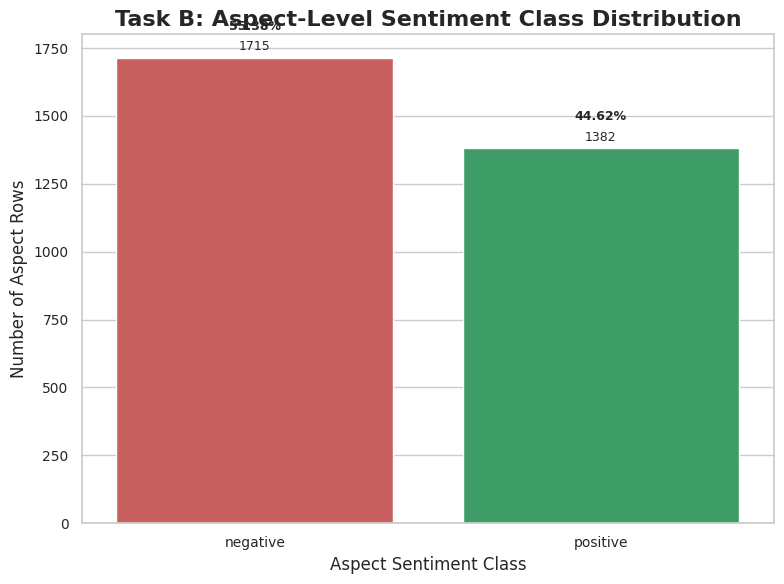

In [98]:
# This cell visualizes class distributions for both tasks.
#
# Assignment usage:
# - Shows class imbalance
# - Justifies macro F1-score and weighted F1-score usage
# ============================================================

# Review-level chart
plt.figure(figsize=(8, 6))

review_palette = [
    SENTIMENT_COLORS.get(cls, MAIN_BLUE)
    for cls in review_class_distribution["Class"]
]

ax = sns.barplot(
    data=review_class_distribution,
    x="Class",
    y="Count",
    palette=review_palette
)

plt.title("Task A: Rating-Based Review Sentiment Class Distribution")
plt.xlabel("Rating-Based Sentiment Class")
plt.ylabel("Number of Reviews")

add_bar_labels(ax)

for i, row in review_class_distribution.iterrows():
    ax.text(
        i,
        row["Count"] + review_class_distribution["Count"].max() * 0.06,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/review_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Aspect-level chart
plt.figure(figsize=(8, 6))

aspect_palette = [
    SENTIMENT_COLORS.get(cls, MAIN_BLUE)
    for cls in aspect_class_distribution["Class"]
]

ax = sns.barplot(
    data=aspect_class_distribution,
    x="Class",
    y="Count",
    palette=aspect_palette
)

plt.title("Task B: Aspect-Level Sentiment Class Distribution")
plt.xlabel("Aspect Sentiment Class")
plt.ylabel("Number of Aspect Rows")

add_bar_labels(ax)

for i, row in aspect_class_distribution.iterrows():
    ax.text(
        i,
        row["Count"] + aspect_class_distribution["Count"].max() * 0.06,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/aspect_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Text Length Summary**

In [99]:
# This cell summarizes text length for both modelling tasks.
#
# Assignment usage:
# - Helps explain why review-level and aspect-level modelling differ
# - Review text is longer
# - Aspect model input is shorter and more targeted
# ============================================================

review_df["model_review_word_count"] = review_df["ml_clean_review"].astype(str).apply(
    lambda x: len(x.split())
)

aspect_df["model_aspect_word_count"] = aspect_df["aspect_model_input_ml"].astype(str).apply(
    lambda x: len(x.split())
)

text_length_summary = pd.DataFrame({
    "Dataset": ["Review-Level", "Aspect-Level"],
    "Average Word Count": [
        round(review_df["model_review_word_count"].mean(), 2),
        round(aspect_df["model_aspect_word_count"].mean(), 2)
    ],
    "Median Word Count": [
        round(review_df["model_review_word_count"].median(), 2),
        round(aspect_df["model_aspect_word_count"].median(), 2)
    ],
    "Maximum Word Count": [
        review_df["model_review_word_count"].max(),
        aspect_df["model_aspect_word_count"].max()
    ]
})

text_length_summary.to_csv(
    "results_notebook3/text_length_summary.csv",
    index=False
)

text_length_summary

,Dataset,Average Word Count,Median Word Count,Maximum Word Count
0,Review-Level,50.75,46.0,221
1,Aspect-Level,12.78,13.0,23


# 3. Train-Test Split and Evaluation Setup

This phase prepares the modelling pipeline.

The goals are:

1. Create stratified train-test splits for both modelling tasks.
2. Encode target labels.
3. Define reusable evaluation functions.
4. Define reusable confusion matrix plotting functions.
5. Create containers to store model results.

Two tasks are prepared:

## Task A: Rating-Based Review-Level Sentiment Classification

| Item | Description |
|---|---|
| Input | `ml_clean_review` |
| Target | `rating_sentiment` |
| Classes | Positive, Neutral, Negative |

## Task B: Aspect-Level Sentiment Classification

| Item | Description |
|---|---|
| Input | `aspect_model_input_ml` |
| Target | `sentiment` |
| Classes | positive, negative |

Stratified splitting is used so that the train and test sets preserve the original class distribution.

# **Prepare Task A and Task B Data**

In [100]:
# This cell prepares input text and target labels for both tasks.
#
# Task A:
# - Review-level rating-based sentiment classification
#
# Task B:
# - Aspect-level sentiment classification
#
# Assignment usage:
# - Supports Methodology section
# - Clearly separates document-level and aspect-level modelling
# ============================================================

# Task A: review-level sentiment classification
X_review = review_df["ml_clean_review"].astype(str)
y_review = review_df["rating_sentiment"].astype(str)

# Task B: aspect-level sentiment classification
X_aspect = aspect_df["aspect_model_input_ml"].astype(str)
y_aspect = aspect_df["sentiment"].astype(str)

print("Task A - Review-level data:")
print("Input shape:", X_review.shape)
print("Target shape:", y_review.shape)
print(y_review.value_counts())

print("\nTask B - Aspect-level data:")
print("Input shape:", X_aspect.shape)
print("Target shape:", y_aspect.shape)
print(y_aspect.value_counts())

Task A - Review-level data:
Input shape: (1615,)
Target shape: (1615,)
rating_sentiment
Positive    804
Negative    551
Neutral     260
Name: count, dtype: int64

Task B - Aspect-level data:
Input shape: (3097,)
Target shape: (3097,)
sentiment
negative    1715
positive    1382
Name: count, dtype: int64


# **Create Stratified Train-Test Splits**

In [101]:
# This cell splits both tasks into training and testing sets.
#
# Test size:
# - 20% test set
# - 80% training set
#
# Stratify:
# - Keeps class proportions similar in train and test sets.
#
# Assignment usage:
# - Ensures fair model evaluation
# - Supports Methodology section
# ============================================================

TEST_SIZE = 0.20

X_review_train, X_review_test, y_review_train, y_review_test = train_test_split(
    X_review,
    y_review,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_review
)

X_aspect_train, X_aspect_test, y_aspect_train, y_aspect_test = train_test_split(
    X_aspect,
    y_aspect,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_aspect
)

print("Task A - Review-level split:")
print("Training samples:", X_review_train.shape[0])
print("Testing samples:", X_review_test.shape[0])

print("\nReview training class distribution:")
print(y_review_train.value_counts())

print("\nReview testing class distribution:")
print(y_review_test.value_counts())

print("\n" + "=" * 80)

print("\nTask B - Aspect-level split:")
print("Training samples:", X_aspect_train.shape[0])
print("Testing samples:", X_aspect_test.shape[0])

print("\nAspect training class distribution:")
print(y_aspect_train.value_counts())

print("\nAspect testing class distribution:")
print(y_aspect_test.value_counts())

Task A - Review-level split:
Training samples: 1292
Testing samples: 323

Review training class distribution:
rating_sentiment
Positive    643
Negative    441
Neutral     208
Name: count, dtype: int64

Review testing class distribution:
rating_sentiment
Positive    161
Negative    110
Neutral      52
Name: count, dtype: int64


Task B - Aspect-level split:
Training samples: 2477
Testing samples: 620

Aspect training class distribution:
sentiment
negative    1372
positive    1105
Name: count, dtype: int64

Aspect testing class distribution:
sentiment
negative    343
positive    277
Name: count, dtype: int64


# **Save Train-Test Split Summaries**

In [102]:
# This cell saves train-test distribution summaries.
#
# Assignment usage:
# - Useful for Methodology
# - Shows that stratified splitting was applied correctly
# ============================================================

review_split_summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Total Samples": [len(y_review_train), len(y_review_test)],
    "Positive": [
        (y_review_train == "Positive").sum(),
        (y_review_test == "Positive").sum()
    ],
    "Neutral": [
        (y_review_train == "Neutral").sum(),
        (y_review_test == "Neutral").sum()
    ],
    "Negative": [
        (y_review_train == "Negative").sum(),
        (y_review_test == "Negative").sum()
    ]
})

aspect_split_summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Total Samples": [len(y_aspect_train), len(y_aspect_test)],
    "positive": [
        (y_aspect_train == "positive").sum(),
        (y_aspect_test == "positive").sum()
    ],
    "negative": [
        (y_aspect_train == "negative").sum(),
        (y_aspect_test == "negative").sum()
    ]
})

review_split_summary.to_csv(
    "results_notebook3/review_train_test_split_summary.csv",
    index=False
)

aspect_split_summary.to_csv(
    "results_notebook3/aspect_train_test_split_summary.csv",
    index=False
)

print("Review-level split summary:")
display(review_split_summary)

print("\nAspect-level split summary:")
display(aspect_split_summary)

Review-level split summary:


,Dataset,Total Samples,Positive,Neutral,Negative
0,Train,1292,643,208,441
1,Test,323,161,52,110



Aspect-level split summary:


,Dataset,Total Samples,positive,negative
0,Train,2477,1105,1372
1,Test,620,277,343


# **Define Global Result Containers**

In [103]:
# These lists will store evaluation results from all models.
#
# Later phases will append results into these lists.
# ============================================================

document_model_results = []
aspect_model_results = []

print("Model result containers created.")

Model result containers created.


# **Evaluation Function**

In [104]:
# This function calculates standard classification metrics.
#
# Metrics:
# - Accuracy
# - Precision
# - Recall
# - Macro F1-score
# - Weighted F1-score
#
# Why macro F1 matters:
# - It treats all classes equally.
# - Important for review-level task because Neutral is smaller.
#
# Why weighted F1 matters:
# - It accounts for class support.
# - Useful for imbalanced datasets.
# ============================================================

def evaluate_predictions(task_name, model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision_macro = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    recall_macro = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    f1_macro = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    f1_weighted = f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    result = {
        "Task": task_name,
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Macro Precision": round(precision_macro, 4),
        "Macro Recall": round(recall_macro, 4),
        "Macro F1": round(f1_macro, 4),
        "Weighted F1": round(f1_weighted, 4)
    }

    return result

# **Classification Report Function**

In [105]:
# This function prints and saves a detailed classification report.
#
# Assignment usage:
# - Provides precision, recall, and F1-score per class
# - Useful for appendix and model evaluation section
# ============================================================

def save_classification_report(y_true, y_pred, output_path):
    report_text = classification_report(
        y_true,
        y_pred,
        zero_division=0
    )

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(report_text)

    print(report_text)

# **Confusion Matrix Plot Function**

In [106]:
# This function creates and saves a confusion matrix heatmap.
#
# Assignment usage:
# - Required for model evaluation
# - Shows which classes are commonly confused
# ============================================================

def plot_confusion_matrix(y_true, y_pred, labels, title, output_path):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor="white"
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return cm

# **Save Prediction Examples Function**

In [107]:
# This function saves predicted vs actual labels.
#
# Assignment usage:
# - Useful for error analysis
# - Helps identify misclassified examples in Phase 8
# ============================================================

def save_prediction_examples(texts, y_true, y_pred, output_path, extra_df=None):
    prediction_df = pd.DataFrame({
        "Text": list(texts),
        "Actual": list(y_true),
        "Predicted": list(y_pred)
    })

    prediction_df["Correct"] = prediction_df["Actual"] == prediction_df["Predicted"]

    if extra_df is not None:
        extra_df_reset = extra_df.reset_index(drop=True)
        prediction_df = pd.concat(
            [extra_df_reset, prediction_df],
            axis=1
        )

    prediction_df.to_csv(output_path, index=False)

    return prediction_df

# **Model Comparison Plot Function**

In [108]:
# This function creates a bar chart comparing model performance.
#
# It will be used later after traditional ML, BiLSTM, and DistilBERT.
# ============================================================

def plot_model_comparison(results_df, title, output_path):
    plot_df = results_df.sort_values("Macro F1", ascending=False)

    plt.figure(figsize=(12, 7))

    ax = sns.barplot(
        data=plot_df,
        x="Macro F1",
        y="Model",
        color=MAIN_BLUE
    )

    plt.title(title)
    plt.xlabel("Macro F1-score")
    plt.ylabel("Model")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

    plt.xlim(0, 1)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

# 4. Traditional Machine Learning for Rating-Based Review Sentiment Classification

This phase trains traditional machine learning models for **Task A: Rating-Based Review-Level Sentiment Classification**.

## Task A Details

| Item | Description |
|---|---|
| Input text | `ml_clean_review` |
| Target label | `rating_sentiment` |
| Classes | Positive, Neutral, Negative |
| Train samples | 1,292 |
| Test samples | 323 |

The purpose of this task is to classify the overall sentiment of a full app review using the sentiment label created from the 1–5 rating column.

## Rating-to-Sentiment Mapping

| Rating | Sentiment |
|---|---|
| 1–2 | Negative |
| 3 | Neutral |
| 4–5 | Positive |

Traditional machine learning models use TF-IDF features extracted from the cleaned review text.

## Models Trained

1. Multinomial Naive Bayes  
2. Logistic Regression  
3. Linear Support Vector Machine  
4. Random Forest  

Since the Neutral class is smaller than Positive and Negative, macro F1-score is used as an important evaluation metric.

# **Define Traditional ML Models for Review-Level Task**

In [109]:
# This cell defines traditional machine learning models for
# rating-based review-level sentiment classification.
#
# TF-IDF converts review text into numerical features.
#
# class_weight="balanced" is used for Logistic Regression and
# Linear SVM because the Neutral class is smaller.
#
# Assignment usage:
# - Supports Sentiment Analysis section
# - Provides baseline ML models before deep learning/transformers
# ============================================================

review_ml_models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    )
}

print("Traditional ML models for review-level task created:")
for model_name in review_ml_models.keys():
    print("-", model_name)

Traditional ML models for review-level task created:
- Naive Bayes
- Logistic Regression
- Linear SVM
- Random Forest


# **Train and Evaluate Review-Level Traditional ML Models**

Training model: Naive Bayes

Evaluation result:
{'Task': 'Review-Level Rating-Based Sentiment', 'Model': 'Naive Bayes', 'Accuracy': 0.5851, 'Macro Precision': 0.4643, 'Macro Recall': 0.422, 'Macro F1': 0.3788, 'Weighted F1': 0.4982}

Classification report:
              precision    recall  f1-score   support

    Negative       0.84      0.29      0.43       110
     Neutral       0.00      0.00      0.00        52
    Positive       0.55      0.98      0.70       161

    accuracy                           0.59       323
   macro avg       0.46      0.42      0.38       323
weighted avg       0.56      0.59      0.50       323



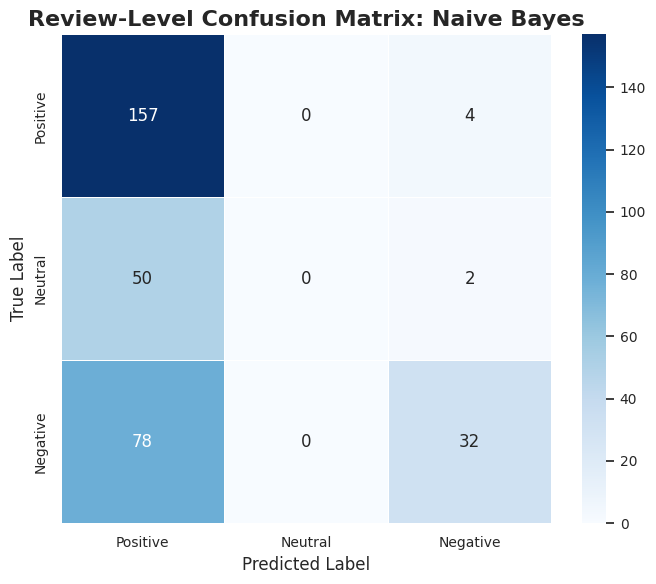

Training model: Logistic Regression

Evaluation result:
{'Task': 'Review-Level Rating-Based Sentiment', 'Model': 'Logistic Regression', 'Accuracy': 0.6563, 'Macro Precision': 0.5668, 'Macro Recall': 0.5649, 'Macro F1': 0.5652, 'Weighted F1': 0.6502}

Classification report:
              precision    recall  f1-score   support

    Negative       0.70      0.70      0.70       110
     Neutral       0.27      0.23      0.25        52
    Positive       0.73      0.76      0.75       161

    accuracy                           0.66       323
   macro avg       0.57      0.56      0.57       323
weighted avg       0.65      0.66      0.65       323



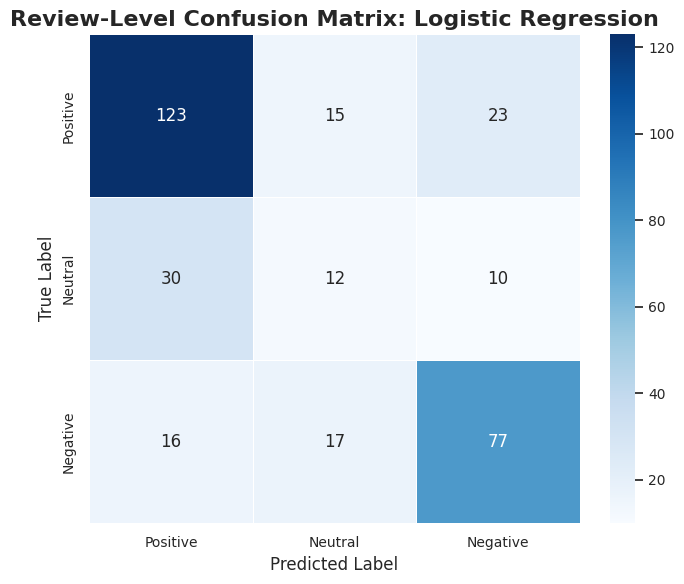

Training model: Linear SVM

Evaluation result:
{'Task': 'Review-Level Rating-Based Sentiment', 'Model': 'Linear SVM', 'Accuracy': 0.6656, 'Macro Precision': 0.5585, 'Macro Recall': 0.5504, 'Macro F1': 0.5446, 'Weighted F1': 0.6421}

Classification report:
              precision    recall  f1-score   support

    Negative       0.70      0.71      0.70       110
     Neutral       0.28      0.13      0.18        52
    Positive       0.70      0.81      0.75       161

    accuracy                           0.67       323
   macro avg       0.56      0.55      0.54       323
weighted avg       0.63      0.67      0.64       323



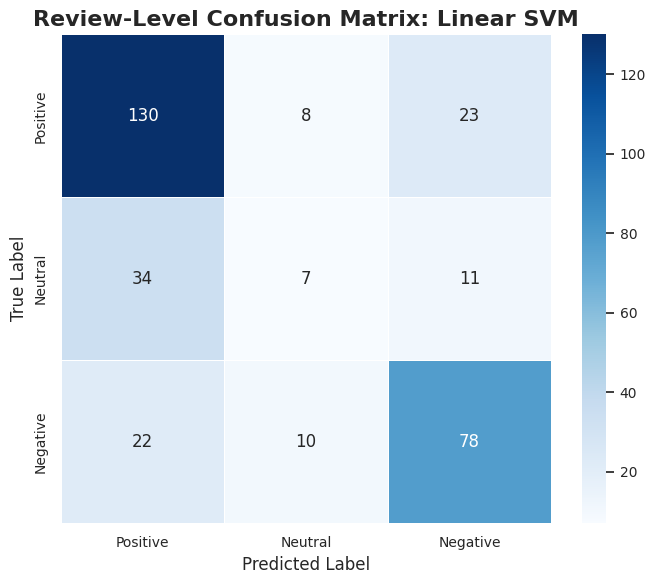

Training model: Random Forest

Evaluation result:
{'Task': 'Review-Level Rating-Based Sentiment', 'Model': 'Random Forest', 'Accuracy': 0.6656, 'Macro Precision': 0.4618, 'Macro Recall': 0.5094, 'Macro F1': 0.4742, 'Weighted F1': 0.6028}

Classification report:
              precision    recall  f1-score   support

    Negative       0.75      0.61      0.67       110
     Neutral       0.00      0.00      0.00        52
    Positive       0.63      0.92      0.75       161

    accuracy                           0.67       323
   macro avg       0.46      0.51      0.47       323
weighted avg       0.57      0.67      0.60       323



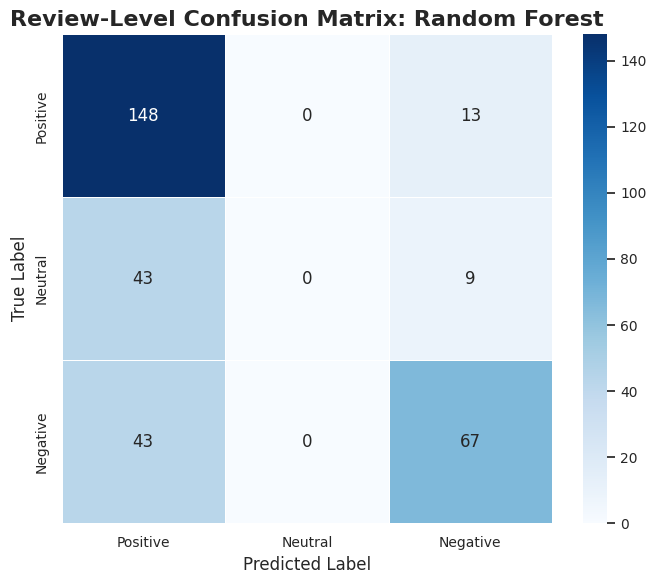

Review-level traditional ML training completed.


In [110]:
# This cell trains each traditional ML model using:
# - TF-IDF vectorization
# - Review-level cleaned text
# - Rating-based sentiment labels
#
# For each model, it saves:
# - Evaluation metrics
# - Classification report
# - Confusion matrix
# - Prediction examples
# ============================================================

review_labels_order = ["Positive", "Neutral", "Negative"]

review_ml_predictions = {}

for model_name, model in review_ml_models.items():
    print("=" * 100)
    print(f"Training model: {model_name}")
    print("=" * 100)

    # Create TF-IDF + model pipeline
    pipeline = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=8000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95
            )
        ),
        ("classifier", model)
    ])

    # Train model
    pipeline.fit(X_review_train, y_review_train)

    # Predict on test set
    y_pred = pipeline.predict(X_review_test)

    # Save predictions for later analysis
    review_ml_predictions[model_name] = {
        "pipeline": pipeline,
        "y_pred": y_pred
    }

    # Evaluate model
    result = evaluate_predictions(
        task_name="Review-Level Rating-Based Sentiment",
        model_name=model_name,
        y_true=y_review_test,
        y_pred=y_pred
    )

    document_model_results.append(result)

    print("\nEvaluation result:")
    print(result)

    # Save classification report
    safe_model_name = model_name.lower().replace(" ", "_")

    report_path = f"results_notebook3/review_{safe_model_name}_classification_report.txt"

    print("\nClassification report:")
    save_classification_report(
        y_true=y_review_test,
        y_pred=y_pred,
        output_path=report_path
    )

    # Save confusion matrix
    cm_path = f"visualizations_notebook3/review_{safe_model_name}_confusion_matrix.png"

    plot_confusion_matrix(
        y_true=y_review_test,
        y_pred=y_pred,
        labels=review_labels_order,
        title=f"Review-Level Confusion Matrix: {model_name}",
        output_path=cm_path
    )

    # Save prediction examples
    prediction_path = f"results_notebook3/review_{safe_model_name}_predictions.csv"

    save_prediction_examples(
        texts=X_review_test,
        y_true=y_review_test,
        y_pred=y_pred,
        output_path=prediction_path
    )

print("Review-level traditional ML training completed.")

# **Review-Level Traditional ML Results Table**

In [111]:
# This cell creates a comparison table for the review-level
# traditional ML models.
#
# Assignment usage:
# - Supports Result & Visualization section
# - Shows model comparison using fair evaluation metrics
# ============================================================

review_traditional_results_df = pd.DataFrame(document_model_results)

review_traditional_results_df = review_traditional_results_df[
    review_traditional_results_df["Task"] == "Review-Level Rating-Based Sentiment"
].copy()

review_traditional_results_df = review_traditional_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

review_traditional_results_df.to_csv(
    "results_notebook3/review_traditional_ml_results.csv",
    index=False
)

review_traditional_results_df

,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Review-Level Rating-Based Sentiment,Logistic Regression,0.6563,0.5668,0.5649,0.5652,0.6502
1,Review-Level Rating-Based Sentiment,Linear SVM,0.6656,0.5585,0.5504,0.5446,0.6421
2,Review-Level Rating-Based Sentiment,Random Forest,0.6656,0.4618,0.5094,0.4742,0.6028
3,Review-Level Rating-Based Sentiment,Naive Bayes,0.5851,0.4643,0.4220,0.3788,0.4982


# **Review-Level Traditional ML Comparison Chart**

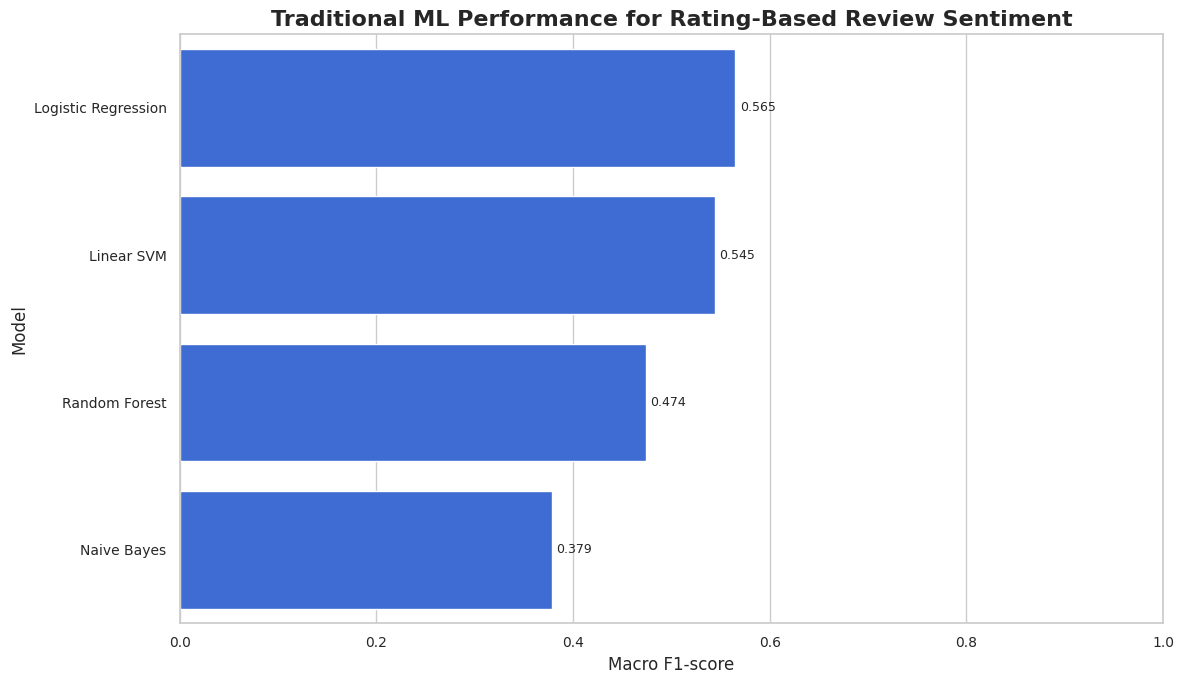

In [112]:
# This chart compares traditional ML models using Macro F1-score.
#
# Macro F1 is emphasized because the Neutral class is smaller.
# ============================================================

plot_model_comparison(
    results_df=review_traditional_results_df,
    title="Traditional ML Performance for Rating-Based Review Sentiment",
    output_path="visualizations_notebook3/review_traditional_ml_macro_f1_comparison.png"
)

# **Review-Level Weighted F1 Comparison Chart**

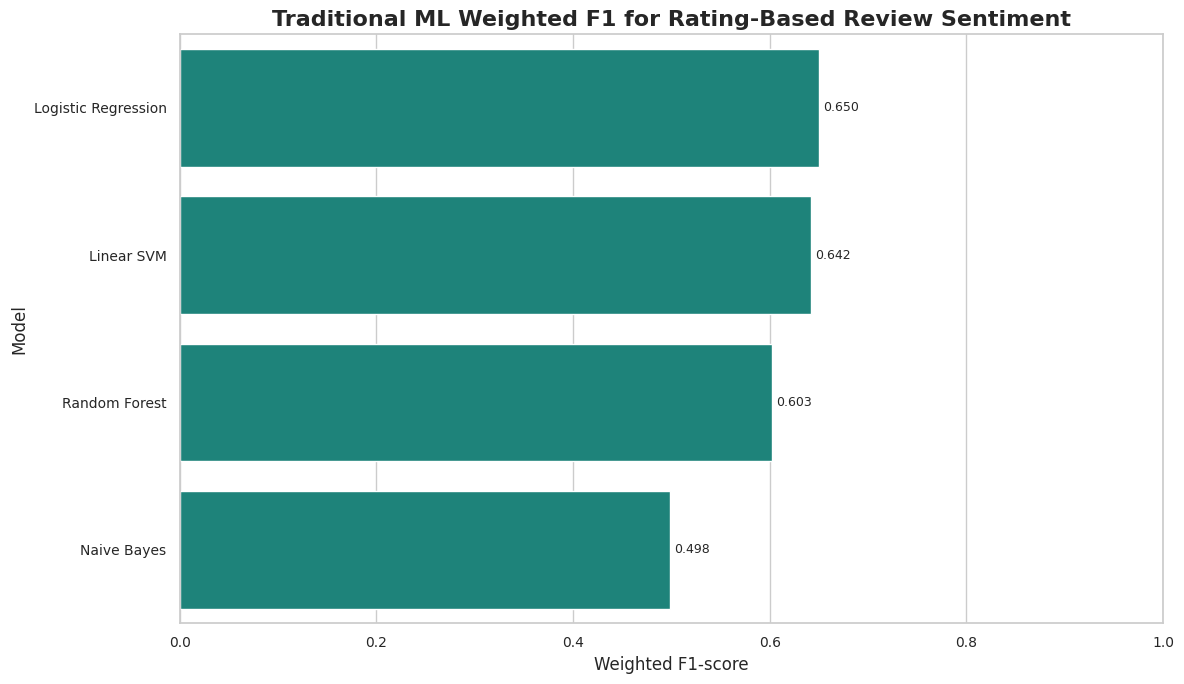

In [113]:
# This chart compares traditional ML models using Weighted F1-score.
#
# Weighted F1 accounts for class support and is useful for
# imbalanced datasets.
# ============================================================

weighted_plot_df = review_traditional_results_df.sort_values(
    by="Weighted F1",
    ascending=False
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=weighted_plot_df,
    x="Weighted F1",
    y="Model",
    color=MAIN_TEAL
)

plt.title("Traditional ML Weighted F1 for Rating-Based Review Sentiment")
plt.xlabel("Weighted F1-score")
plt.ylabel("Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.xlim(0, 1)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/review_traditional_ml_weighted_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Identify Best Review-Level Traditional ML Model**

In [114]:
# This cell identifies the best traditional ML model for the
# review-level task using Macro F1-score.
#
# Assignment usage:
# - Supports model comparison and discussion
# ============================================================

best_review_traditional_model_row = review_traditional_results_df.iloc[0]

best_review_traditional_model_name = best_review_traditional_model_row["Model"]
best_review_traditional_macro_f1 = best_review_traditional_model_row["Macro F1"]
best_review_traditional_weighted_f1 = best_review_traditional_model_row["Weighted F1"]

print("Best review-level traditional ML model:")
print("Model:", best_review_traditional_model_name)
print("Macro F1:", best_review_traditional_macro_f1)
print("Weighted F1:", best_review_traditional_weighted_f1)

best_review_traditional_summary = pd.DataFrame([best_review_traditional_model_row])

best_review_traditional_summary.to_csv(
    "results_notebook3/best_review_traditional_model.csv",
    index=False
)

best_review_traditional_summary

Best review-level traditional ML model:
Model: Logistic Regression
Macro F1: 0.5652
Weighted F1: 0.6502


,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Review-Level Rating-Based Sentiment,Logistic Regression,0.6563,0.5668,0.5649,0.5652,0.6502


# **Misclassified Review-Level Examples from Best Traditional Model**

In [115]:
# This cell extracts misclassified examples from the best
# review-level traditional ML model.
#
# Assignment usage:
# - Useful for Discussion section
# - Helps explain model limitations
# ============================================================

best_review_y_pred = review_ml_predictions[best_review_traditional_model_name]["y_pred"]

review_error_analysis_df = pd.DataFrame({
    "Review Text": list(X_review_test),
    "Actual": list(y_review_test),
    "Predicted": list(best_review_y_pred)
})

review_error_analysis_df["Correct"] = (
    review_error_analysis_df["Actual"] == review_error_analysis_df["Predicted"]
)

review_misclassified_examples = review_error_analysis_df[
    review_error_analysis_df["Correct"] == False
].copy()

review_misclassified_examples.to_csv(
    "results_notebook3/review_best_traditional_misclassified_examples.csv",
    index=False
)

print("Number of misclassified review-level examples:")
print(len(review_misclassified_examples))

review_misclassified_examples.head(15)

Number of misclassified review-level examples:
111


,Review Text,Actual,Predicted,Correct
0,device iphone audio quiet term mic speaker fri...,Neutral,Negative,False
5,functionality part fine text seem working corr...,Neutral,Positive,False
6,waiting forever update ca not login t since re...,Neutral,Negative,False
8,audio problem lot others also suffer people ta...,Negative,Positive,False
9,app starting bug really bad message keep faili...,Negative,Positive,False
13,app need search bar,Neutral,Positive,False
14,app work fine beware ad say something click sc...,Neutral,Positive,False
16,app almost year never ever encountered issue e...,Negative,Neutral,False
21,secure messaging app one huge flaw audio messa...,Negative,Neutral,False
25,app really cool besides picture messaging not ...,Neutral,Positive,False


# 5. Traditional Machine Learning for Aspect-Level Sentiment Classification

This phase trains traditional machine learning models for **Task B: Aspect-Level Sentiment Classification**.

## Task B Details

| Item | Description |
|---|---|
| Input text | `aspect_model_input_ml` |
| Target label | `sentiment` |
| Classes | positive, negative |
| Train samples | 2,477 |
| Test samples | 620 |

This is the main ABSA modelling task because it classifies sentiment toward a specific aspect, rather than only predicting the overall review sentiment.

## Input Format

The aspect-level input was created in Notebook 1 using:

```text
sentence + aspect category + aspect term

# **Define Traditional ML Models for Aspect-Level Task**

In [116]:
# This cell defines traditional machine learning models for
# aspect-level sentiment classification.
#
# Task B:
# - Input: sentence + aspect category + aspect term
# - Target: aspect-level sentiment
#
# Assignment usage:
# - Supports ABSA model development
# - Provides strong baseline models before BiLSTM and DistilBERT
# ============================================================

aspect_ml_models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    )
}

print("Traditional ML models for aspect-level task created:")
for model_name in aspect_ml_models.keys():
    print("-", model_name)

Traditional ML models for aspect-level task created:
- Naive Bayes
- Logistic Regression
- Linear SVM
- Random Forest


# **Train and Evaluate Aspect-Level Traditional ML Models**

Training model: Naive Bayes

Evaluation result:
{'Task': 'Aspect-Level Sentiment Classification', 'Model': 'Naive Bayes', 'Accuracy': 0.7306, 'Macro Precision': 0.7553, 'Macro Recall': 0.71, 'Macro F1': 0.7096, 'Weighted F1': 0.7179}

Classification report:
              precision    recall  f1-score   support

    negative       0.70      0.90      0.79       343
    positive       0.81      0.52      0.63       277

    accuracy                           0.73       620
   macro avg       0.76      0.71      0.71       620
weighted avg       0.75      0.73      0.72       620



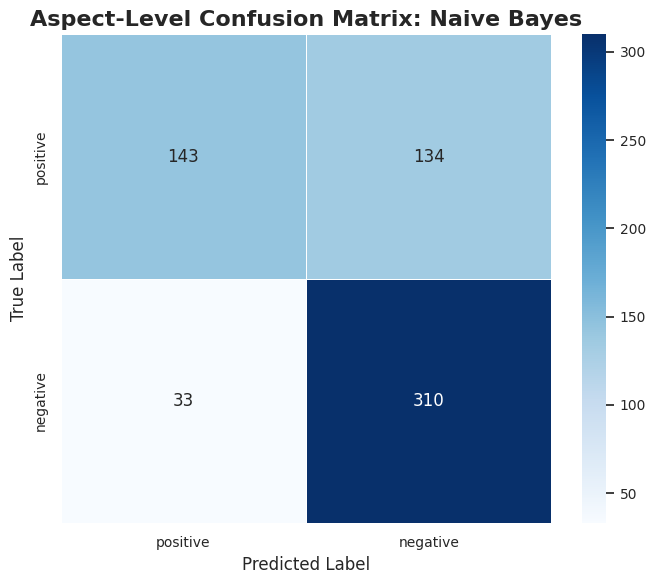

Training model: Logistic Regression

Evaluation result:
{'Task': 'Aspect-Level Sentiment Classification', 'Model': 'Logistic Regression', 'Accuracy': 0.6903, 'Macro Precision': 0.6876, 'Macro Recall': 0.6889, 'Macro F1': 0.688, 'Weighted F1': 0.6908}

Classification report:
              precision    recall  f1-score   support

    negative       0.73      0.70      0.72       343
    positive       0.65      0.68      0.66       277

    accuracy                           0.69       620
   macro avg       0.69      0.69      0.69       620
weighted avg       0.69      0.69      0.69       620



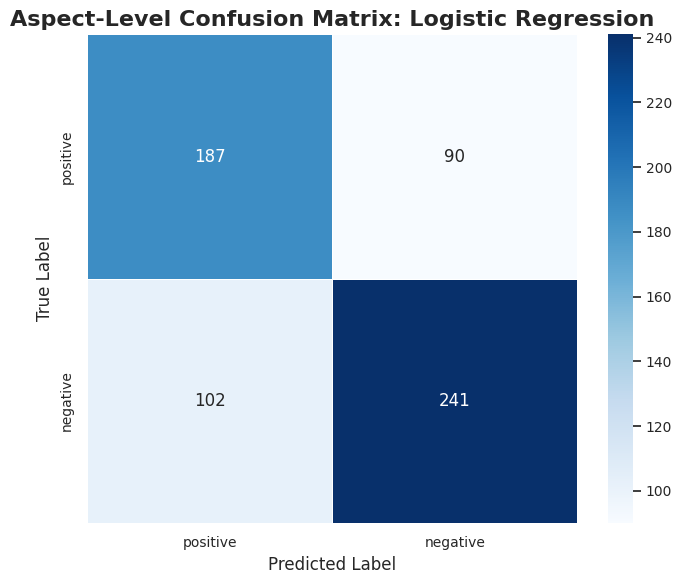

Training model: Linear SVM

Evaluation result:
{'Task': 'Aspect-Level Sentiment Classification', 'Model': 'Linear SVM', 'Accuracy': 0.7194, 'Macro Precision': 0.7161, 'Macro Recall': 0.7158, 'Macro F1': 0.7159, 'Weighted F1': 0.7193}

Classification report:
              precision    recall  f1-score   support

    negative       0.74      0.75      0.75       343
    positive       0.69      0.68      0.68       277

    accuracy                           0.72       620
   macro avg       0.72      0.72      0.72       620
weighted avg       0.72      0.72      0.72       620



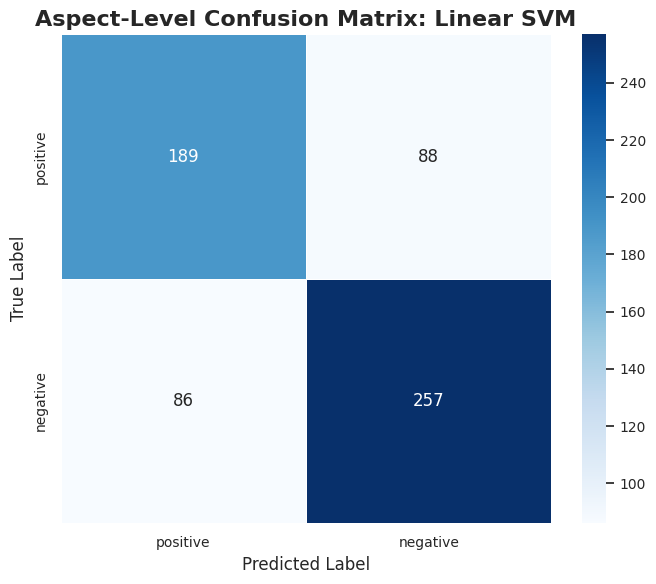

Training model: Random Forest

Evaluation result:
{'Task': 'Aspect-Level Sentiment Classification', 'Model': 'Random Forest', 'Accuracy': 0.7129, 'Macro Precision': 0.7097, 'Macro Recall': 0.7068, 'Macro F1': 0.7078, 'Weighted F1': 0.7119}

Classification report:
              precision    recall  f1-score   support

    negative       0.73      0.76      0.75       343
    positive       0.69      0.65      0.67       277

    accuracy                           0.71       620
   macro avg       0.71      0.71      0.71       620
weighted avg       0.71      0.71      0.71       620



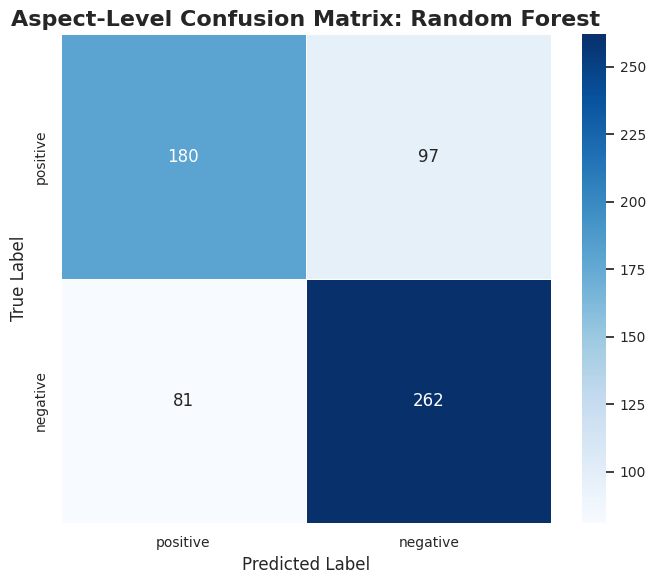

Aspect-level traditional ML training completed.


In [117]:
# This cell trains each traditional ML model using:
# - TF-IDF vectorization
# - Aspect-level model input text
# - Aspect sentiment labels
#
# For each model, it saves:
# - Evaluation metrics
# - Classification report
# - Confusion matrix
# - Prediction examples
# ============================================================

aspect_labels_order = ["positive", "negative"]

aspect_ml_predictions = {}

for model_name, model in aspect_ml_models.items():
    print("=" * 100)
    print(f"Training model: {model_name}")
    print("=" * 100)

    # Create TF-IDF + model pipeline
    pipeline = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=8000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95
            )
        ),
        ("classifier", model)
    ])

    # Train model
    pipeline.fit(X_aspect_train, y_aspect_train)

    # Predict on test set
    y_pred = pipeline.predict(X_aspect_test)

    # Save predictions for later analysis
    aspect_ml_predictions[model_name] = {
        "pipeline": pipeline,
        "y_pred": y_pred
    }

    # Evaluate model
    result = evaluate_predictions(
        task_name="Aspect-Level Sentiment Classification",
        model_name=model_name,
        y_true=y_aspect_test,
        y_pred=y_pred
    )

    aspect_model_results.append(result)

    print("\nEvaluation result:")
    print(result)

    # Save classification report
    safe_model_name = model_name.lower().replace(" ", "_")

    report_path = f"results_notebook3/aspect_{safe_model_name}_classification_report.txt"

    print("\nClassification report:")
    save_classification_report(
        y_true=y_aspect_test,
        y_pred=y_pred,
        output_path=report_path
    )

    # Save confusion matrix
    cm_path = f"visualizations_notebook3/aspect_{safe_model_name}_confusion_matrix.png"

    plot_confusion_matrix(
        y_true=y_aspect_test,
        y_pred=y_pred,
        labels=aspect_labels_order,
        title=f"Aspect-Level Confusion Matrix: {model_name}",
        output_path=cm_path
    )

    # Save prediction examples
    prediction_path = f"results_notebook3/aspect_{safe_model_name}_predictions.csv"

    save_prediction_examples(
        texts=X_aspect_test,
        y_true=y_aspect_test,
        y_pred=y_pred,
        output_path=prediction_path
    )

print("Aspect-level traditional ML training completed.")

# **Aspect-Level Traditional ML Results Table**

In [118]:
# This cell creates a comparison table for the aspect-level
# traditional ML models.
#
# Assignment usage:
# - Supports ABSA Result & Visualization section
# - Shows model comparison using accuracy, macro F1 and weighted F1
# ============================================================

aspect_traditional_results_df = pd.DataFrame(aspect_model_results)

aspect_traditional_results_df = aspect_traditional_results_df[
    aspect_traditional_results_df["Task"] == "Aspect-Level Sentiment Classification"
].copy()

aspect_traditional_results_df = aspect_traditional_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

aspect_traditional_results_df.to_csv(
    "results_notebook3/aspect_traditional_ml_results.csv",
    index=False
)

aspect_traditional_results_df

,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Aspect-Level Sentiment Classification,Linear SVM,0.7194,0.7161,0.7158,0.7159,0.7193
1,Aspect-Level Sentiment Classification,Naive Bayes,0.7306,0.7553,0.7100,0.7096,0.7179
2,Aspect-Level Sentiment Classification,Random Forest,0.7129,0.7097,0.7068,0.7078,0.7119
3,Aspect-Level Sentiment Classification,Logistic Regression,0.6903,0.6876,0.6889,0.6880,0.6908


# **Aspect-Level Traditional ML Macro F1 Comparison Chart**

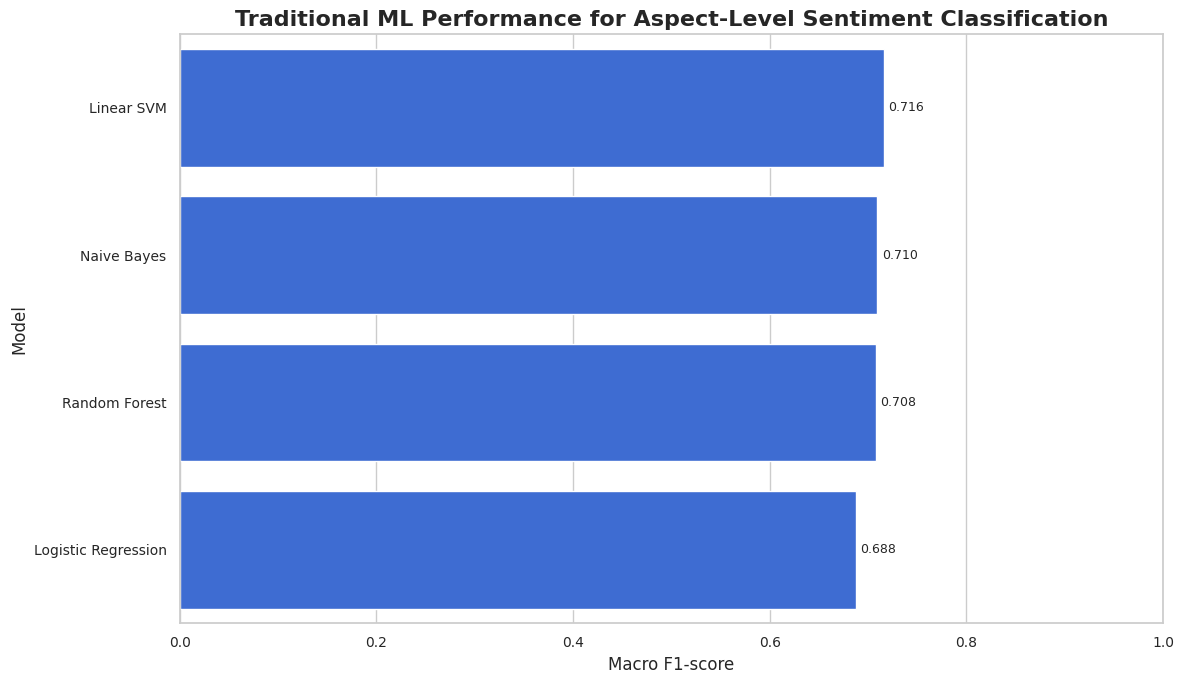

In [119]:
# This chart compares traditional ML models using Macro F1-score.
#
# Assignment usage:
# - Main report visual candidate
# - Shows which baseline model performs best for ABSA
# ============================================================

plot_model_comparison(
    results_df=aspect_traditional_results_df,
    title="Traditional ML Performance for Aspect-Level Sentiment Classification",
    output_path="visualizations_notebook3/aspect_traditional_ml_macro_f1_comparison.png"
)

# **App-Level High-Risk Aspect Term Table**

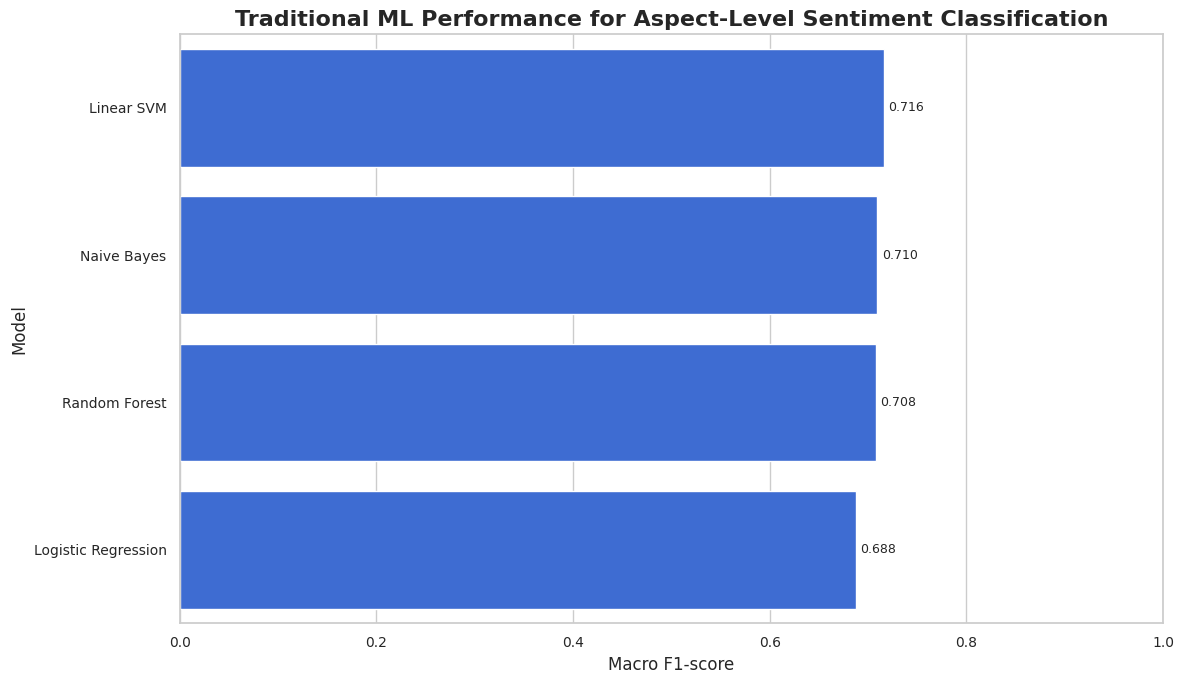

In [120]:
# This chart compares traditional ML models using Macro F1-score.
#
# Assignment usage:
# - Main report visual candidate
# - Shows which baseline model performs best for ABSA
# ============================================================

plot_model_comparison(
    results_df=aspect_traditional_results_df,
    title="Traditional ML Performance for Aspect-Level Sentiment Classification",
    output_path="visualizations_notebook3/aspect_traditional_ml_macro_f1_comparison.png"
)

# **Aspect-Level Weighted F1 Comparison Chart**

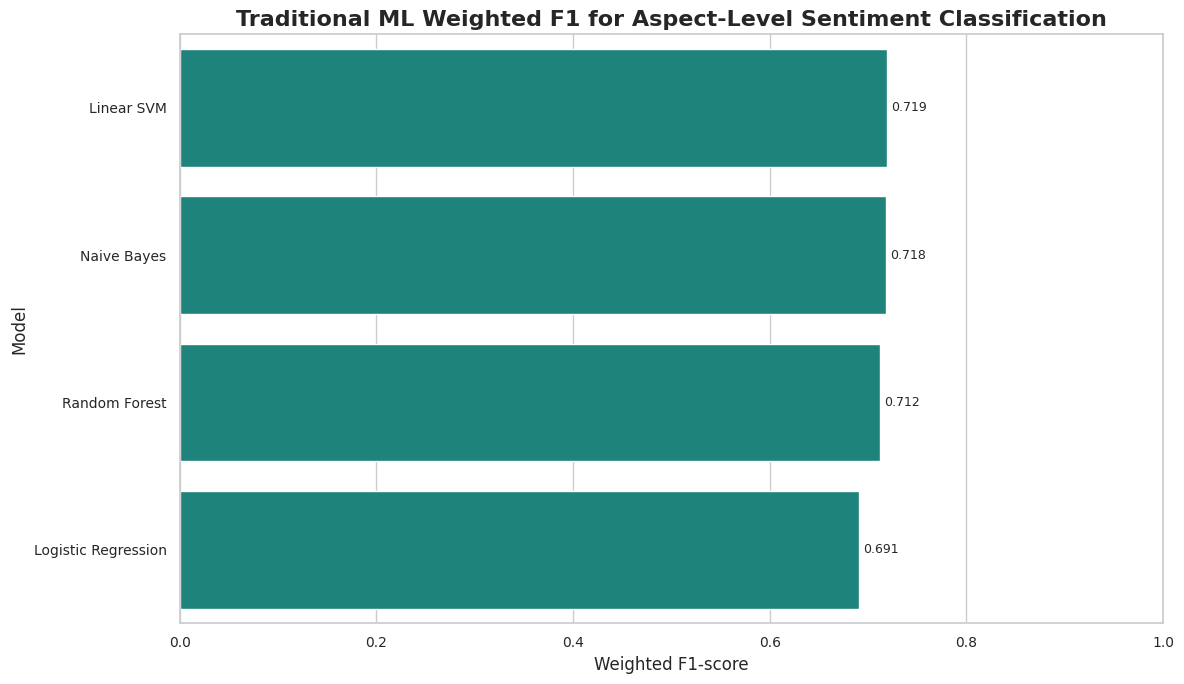

In [121]:
# This chart compares traditional ML models using Weighted F1-score.
# ============================================================

weighted_plot_df = aspect_traditional_results_df.sort_values(
    by="Weighted F1",
    ascending=False
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=weighted_plot_df,
    x="Weighted F1",
    y="Model",
    color=MAIN_TEAL
)

plt.title("Traditional ML Weighted F1 for Aspect-Level Sentiment Classification")
plt.xlabel("Weighted F1-score")
plt.ylabel("Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.xlim(0, 1)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/aspect_traditional_ml_weighted_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Identify Best Aspect-Level Traditional ML Model**

In [122]:
# This cell identifies the best traditional ML model for the
# aspect-level task using Macro F1-score.
#
# Assignment usage:
# - Supports ABSA model comparison and discussion
# ============================================================

best_aspect_traditional_model_row = aspect_traditional_results_df.iloc[0]

best_aspect_traditional_model_name = best_aspect_traditional_model_row["Model"]
best_aspect_traditional_macro_f1 = best_aspect_traditional_model_row["Macro F1"]
best_aspect_traditional_weighted_f1 = best_aspect_traditional_model_row["Weighted F1"]

print("Best aspect-level traditional ML model:")
print("Model:", best_aspect_traditional_model_name)
print("Macro F1:", best_aspect_traditional_macro_f1)
print("Weighted F1:", best_aspect_traditional_weighted_f1)

best_aspect_traditional_summary = pd.DataFrame([best_aspect_traditional_model_row])

best_aspect_traditional_summary.to_csv(
    "results_notebook3/best_aspect_traditional_model.csv",
    index=False
)

best_aspect_traditional_summary

Best aspect-level traditional ML model:
Model: Linear SVM
Macro F1: 0.7159
Weighted F1: 0.7193


,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Aspect-Level Sentiment Classification,Linear SVM,0.7194,0.7161,0.7158,0.7159,0.7193


# **Misclassified Aspect-Level Examples from Best Traditional Model**

In [123]:
# This cell extracts misclassified examples from the best
# aspect-level traditional ML model.
#
# Assignment usage:
# - Useful for Discussion section
# - Helps explain ABSA model limitations
# ============================================================

best_aspect_y_pred = aspect_ml_predictions[best_aspect_traditional_model_name]["y_pred"]

aspect_error_analysis_df = pd.DataFrame({
    "Aspect Input Text": list(X_aspect_test),
    "Actual": list(y_aspect_test),
    "Predicted": list(best_aspect_y_pred)
})

aspect_error_analysis_df["Correct"] = (
    aspect_error_analysis_df["Actual"] == aspect_error_analysis_df["Predicted"]
)

aspect_misclassified_examples = aspect_error_analysis_df[
    aspect_error_analysis_df["Correct"] == False
].copy()

aspect_misclassified_examples.to_csv(
    "results_notebook3/aspect_best_traditional_misclassified_examples.csv",
    index=False
)

print("Number of misclassified aspect-level examples:")
print(len(aspect_misclassified_examples))

aspect_misclassified_examples.head(15)

Number of misclassified aspect-level examples:
174


,Aspect Input Text,Actual,Predicted,Correct
0,think direction share video sep usability sep ...,negative,positive,False
3,go mobile version discord like talk sound brok...,negative,positive,False
4,purchase sep cost sep purchase,positive,negative,False
5,keep getting weird phone call sep security sep...,negative,positive,False
7,put limit often change personal profile pictur...,negative,positive,False
8,consistent desktop version couple major flaw s...,positive,negative,False
13,enable two factor authentication day ago start...,negative,positive,False
14,cannot make voice call okay sep effectiveness ...,negative,positive,False
16,wo not allow avatar photo pc charge u sep usab...,positive,negative,False
19,prevents joining chat room sep general sep chat,negative,positive,False


# **Count Custom Opinion Words**

In [124]:
# This cell extracts misclassified examples from the best
# aspect-level traditional ML model.
#
# Assignment usage:
# - Useful for Discussion section
# - Helps explain ABSA model limitations
# ============================================================

best_aspect_y_pred = aspect_ml_predictions[best_aspect_traditional_model_name]["y_pred"]

aspect_error_analysis_df = pd.DataFrame({
    "Aspect Input Text": list(X_aspect_test),
    "Actual": list(y_aspect_test),
    "Predicted": list(best_aspect_y_pred)
})

aspect_error_analysis_df["Correct"] = (
    aspect_error_analysis_df["Actual"] == aspect_error_analysis_df["Predicted"]
)

aspect_misclassified_examples = aspect_error_analysis_df[
    aspect_error_analysis_df["Correct"] == False
].copy()

aspect_misclassified_examples.to_csv(
    "results_notebook3/aspect_best_traditional_misclassified_examples.csv",
    index=False
)

print("Number of misclassified aspect-level examples:")
print(len(aspect_misclassified_examples))

aspect_misclassified_examples.head(15)

Number of misclassified aspect-level examples:
174


,Aspect Input Text,Actual,Predicted,Correct
0,think direction share video sep usability sep ...,negative,positive,False
3,go mobile version discord like talk sound brok...,negative,positive,False
4,purchase sep cost sep purchase,positive,negative,False
5,keep getting weird phone call sep security sep...,negative,positive,False
7,put limit often change personal profile pictur...,negative,positive,False
8,consistent desktop version couple major flaw s...,positive,negative,False
13,enable two factor authentication day ago start...,negative,positive,False
14,cannot make voice call okay sep effectiveness ...,negative,positive,False
16,wo not allow avatar photo pc charge u sep usab...,positive,negative,False
19,prevents joining chat room sep general sep chat,negative,positive,False


# **Save Best Traditional ML Pipelines**

In [125]:
# This cell saves the best review-level and aspect-level
# traditional ML model pipelines using joblib.
#
# Assignment usage:
# - Useful for reproducibility
# - Can be included in GitHub repository if file size is acceptable
# ============================================================

import joblib

best_review_pipeline = review_ml_predictions[best_review_traditional_model_name]["pipeline"]
best_aspect_pipeline = aspect_ml_predictions[best_aspect_traditional_model_name]["pipeline"]

joblib.dump(
    best_review_pipeline,
    "models_notebook3/best_review_traditional_model.joblib"
)

joblib.dump(
    best_aspect_pipeline,
    "models_notebook3/best_aspect_traditional_model.joblib"
)

print("Best traditional ML pipelines saved:")
print("- models_notebook3/best_review_traditional_model.joblib")
print("- models_notebook3/best_aspect_traditional_model.joblib")

Best traditional ML pipelines saved:
- models_notebook3/best_review_traditional_model.joblib
- models_notebook3/best_aspect_traditional_model.joblib


# 6. Deep Learning Model: BiLSTM for Aspect-Level Sentiment Classification

This phase trains a Bidirectional LSTM model for the main ABSA task.

## Task

| Item | Description |
|---|---|
| Input | `aspect_model_input` |
| Target | `sentiment` |
| Classes | positive, negative |
| Model | Bidirectional LSTM |
| Purpose | Deep learning sequence model for aspect-level sentiment classification |

BiLSTM is used because it can learn word order and sequential context better than traditional TF-IDF models. This is useful for aspect-level sentiment because the meaning of a sentence can depend on word sequence, negation, and context.

The model is trained only on the aspect-level task because this is the main ABSA task and has better class balance than the review-level task.

# **Prepare BiLSTM Data**

In [126]:
# This cell prepares text and labels for the BiLSTM model.
#
# Input:
# - aspect_model_input
#
# Target:
# - sentiment
#
# Labels:
# - positive = 1
# - negative = 0
# ============================================================

# Use less aggressively cleaned text for deep learning
X_bilstm = aspect_df["aspect_model_input"].astype(str)
y_bilstm = aspect_df["sentiment"].astype(str)

# Encode binary labels
bilstm_label_mapping = {
    "negative": 0,
    "positive": 1
}

y_bilstm_encoded = y_bilstm.map(bilstm_label_mapping)

# Train-test split using same random seed
X_bilstm_train, X_bilstm_test, y_bilstm_train, y_bilstm_test = train_test_split(
    X_bilstm,
    y_bilstm_encoded,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_bilstm_encoded
)

print("BiLSTM data prepared.")
print("Training samples:", len(X_bilstm_train))
print("Testing samples:", len(X_bilstm_test))

print("\nTraining label distribution:")
print(y_bilstm_train.value_counts())

print("\nTesting label distribution:")
print(y_bilstm_test.value_counts())

BiLSTM data prepared.
Training samples: 2477
Testing samples: 620

Training label distribution:
sentiment
0    1372
1    1105
Name: count, dtype: int64

Testing label distribution:
sentiment
0    343
1    277
Name: count, dtype: int64


# **Tokenize and Pad Text for BiLSTM**

In [127]:
# This cell converts text into integer sequences and pads them
# to a fixed length.
#
# Tokenizer:
# - Converts words into numbers
#
# Padding:
# - Makes all text sequences the same length
# ============================================================

MAX_WORDS = 10000
MAX_SEQUENCE_LENGTH = 60
EMBEDDING_DIM = 128

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_bilstm_train)

X_bilstm_train_seq = tokenizer.texts_to_sequences(X_bilstm_train)
X_bilstm_test_seq = tokenizer.texts_to_sequences(X_bilstm_test)

X_bilstm_train_pad = pad_sequences(
    X_bilstm_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_bilstm_test_pad = pad_sequences(
    X_bilstm_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Tokenization and padding completed.")
print("Training padded shape:", X_bilstm_train_pad.shape)
print("Testing padded shape:", X_bilstm_test_pad.shape)
print("Vocabulary size:", min(MAX_WORDS, len(tokenizer.word_index) + 1))

Tokenization and padding completed.
Training padded shape: (2477, 60)
Testing padded shape: (620, 60)
Vocabulary size: 3064


# **Build BiLSTM Model**

In [128]:
# This cell builds a Bidirectional LSTM model for binary
# aspect-level sentiment classification.
#
# Architecture:
# - Embedding layer
# - Spatial dropout
# - Bidirectional LSTM
# - Dense hidden layer
# - Dropout
# - Sigmoid output
# ============================================================

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

bilstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    ),
    SpatialDropout1D(0.25),
    Bidirectional(
        LSTM(
            64,
            dropout=0.25,
            recurrent_dropout=0.25
        )
    ),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Train BiLSTM Model**

In [129]:
# This cell trains the BiLSTM model.
#
# EarlyStopping:
# - Stops training if validation loss does not improve.
# - Restores the best model weights.
#
# Assignment usage:
# - Supports Deep Learning Models section
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

BATCH_SIZE = 32
EPOCHS = 12

bilstm_history = bilstm_model.fit(
    X_bilstm_train_pad,
    y_bilstm_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 80s 727ms/step - accuracy: 0.5596 - loss: 0.6864 - val_accuracy: 0.5806 - val_loss: 0.6679
Epoch 2/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 54s 466ms/step - accuracy: 0.7093 - loss: 0.5793 - val_accuracy: 0.7446 - val_loss: 0.5155
Epoch 3/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 387ms/step - accuracy: 0.8038 - loss: 0.4413 - val_accuracy: 0.7527 - val_loss: 0.5114
Epoch 4/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 389ms/step - accuracy: 0.8570 - loss: 0.3426 - val_accuracy: 0.7500 - val_loss: 0.5516
Epoch 5/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 43s 420ms/step - accuracy: 0.8903 - loss: 0.2797 - val_accuracy: 0.7392 - val_loss: 0.6386
Epoch 6/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 456ms/step - accuracy: 0.9078 - loss: 0.2335 - val_accuracy: 0.7070 - val_loss: 0.7718


# **Plot BiLSTM Training Curves**

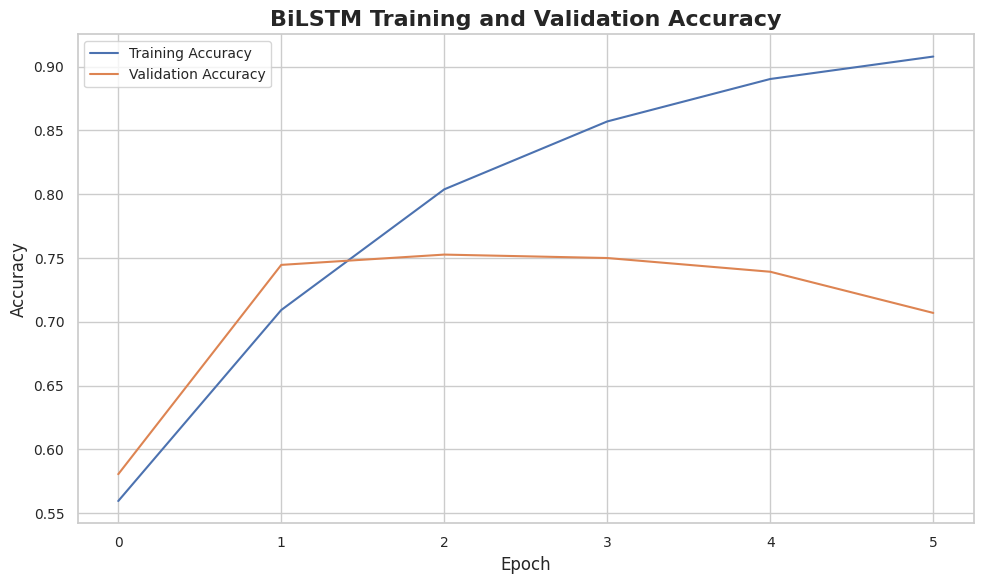

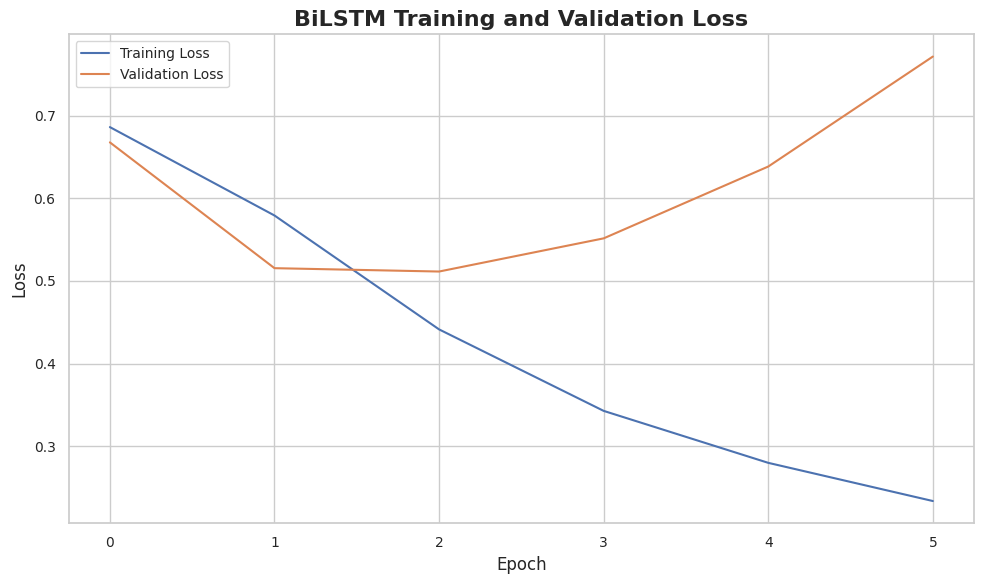

In [130]:
# This cell plots training and validation accuracy/loss.
#
# Assignment usage:
# - Shows deep learning training behavior
# - Useful for Transformers / Deep Learning Models section
# ============================================================

history_df = pd.DataFrame(bilstm_history.history)

history_df.to_csv(
    "results_notebook3/bilstm_training_history.csv",
    index=False
)

# Accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("BiLSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/bilstm_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Loss curve
plt.figure(figsize=(10, 6))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("BiLSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/bilstm_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Evaluate BiLSTM Model**

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step
BiLSTM evaluation result:
{'Task': 'Aspect-Level Sentiment Classification', 'Model': 'BiLSTM', 'Accuracy': 0.7065, 'Macro Precision': 0.703, 'Macro Recall': 0.7024, 'Macro F1': 0.7027, 'Weighted F1': 0.7062}

BiLSTM classification report:
              precision    recall  f1-score   support

    negative       0.73      0.74      0.74       343
    positive       0.67      0.66      0.67       277

    accuracy                           0.71       620
   macro avg       0.70      0.70      0.70       620
weighted avg       0.71      0.71      0.71       620



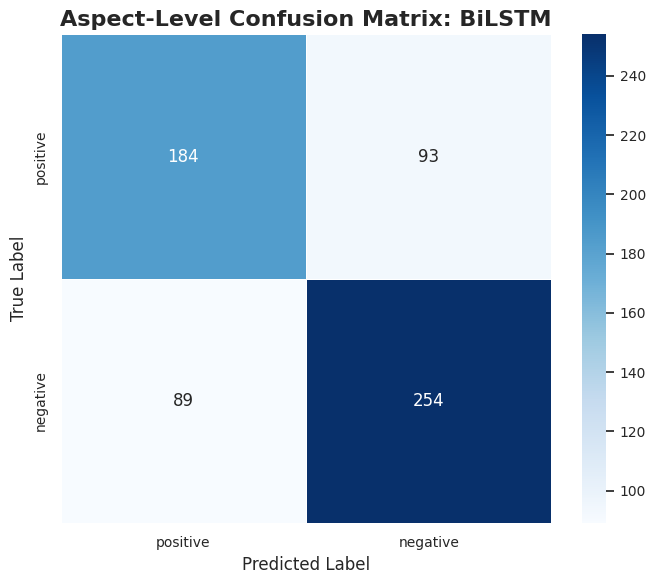

array([[184,  93],
       [ 89, 254]])

In [131]:
# This cell evaluates the BiLSTM model on the test set.
#
# Output:
# - Prediction labels
# - Evaluation metrics
# - Classification report
# - Confusion matrix
# ============================================================

bilstm_pred_prob = bilstm_model.predict(X_bilstm_test_pad)
bilstm_pred_encoded = (bilstm_pred_prob >= 0.5).astype(int).flatten()

reverse_bilstm_label_mapping = {
    0: "negative",
    1: "positive"
}

y_bilstm_test_labels = y_bilstm_test.map(reverse_bilstm_label_mapping)
bilstm_pred_labels = pd.Series(bilstm_pred_encoded).map(reverse_bilstm_label_mapping)

bilstm_result = evaluate_predictions(
    task_name="Aspect-Level Sentiment Classification",
    model_name="BiLSTM",
    y_true=y_bilstm_test_labels,
    y_pred=bilstm_pred_labels
)

aspect_model_results.append(bilstm_result)

print("BiLSTM evaluation result:")
print(bilstm_result)

print("\nBiLSTM classification report:")
save_classification_report(
    y_true=y_bilstm_test_labels,
    y_pred=bilstm_pred_labels,
    output_path="results_notebook3/bilstm_classification_report.txt"
)

plot_confusion_matrix(
    y_true=y_bilstm_test_labels,
    y_pred=bilstm_pred_labels,
    labels=["positive", "negative"],
    title="Aspect-Level Confusion Matrix: BiLSTM",
    output_path="visualizations_notebook3/bilstm_confusion_matrix.png"
)

# **Save BiLSTM Predictions and Model**

In [132]:
# This cell saves:
# - BiLSTM prediction examples
# - BiLSTM model file
# ============================================================

bilstm_predictions_df = save_prediction_examples(
    texts=X_bilstm_test,
    y_true=y_bilstm_test_labels,
    y_pred=bilstm_pred_labels,
    output_path="results_notebook3/bilstm_predictions.csv"
)

bilstm_model.save("models_notebook3/bilstm_aspect_sentiment_model.keras")

print("BiLSTM predictions saved:")
print("results_notebook3/bilstm_predictions.csv")

print("\nBiLSTM model saved:")
print("models_notebook3/bilstm_aspect_sentiment_model.keras")

BiLSTM predictions saved:
results_notebook3/bilstm_predictions.csv

BiLSTM model saved:
models_notebook3/bilstm_aspect_sentiment_model.keras


# **BiLSTM Misclassified Examples**

In [133]:
# This cell extracts examples misclassified by the BiLSTM model.
#
# Assignment usage:
# - Useful for Discussion section
# ============================================================

bilstm_misclassified_examples = bilstm_predictions_df[
    bilstm_predictions_df["Correct"] == False
].copy()

bilstm_misclassified_examples.to_csv(
    "results_notebook3/bilstm_misclassified_examples.csv",
    index=False
)

print("Number of BiLSTM misclassified examples:")
print(len(bilstm_misclassified_examples))

bilstm_misclassified_examples.head(15)

Number of BiLSTM misclassified examples:
182


,Text,Actual,Predicted,Correct
1,this is a replacement for those who do not wan...,positive,negative,False
2,for being a secure messaging app it has one hu...,negative,positive,False
3,so i go on the mobile version of discord and i...,negative,positive,False
4,will purchase if it is [SEP] cost [SEP] purchase,positive,negative,False
7,why put a limit on how often you can change yo...,negative,positive,False
10,lower th price to high for a communication app...,negative,positive,False
16,it wo not allow me to have an avatar photo as ...,positive,negative,False
17,but many thing from years ago may have not bee...,positive,negative,False
19,this now prevents me from joining any chat roo...,negative,positive,False
22,thank you for helping me realize that my data ...,positive,negative,False


# 7. Transformer Model: DistilBERT for Aspect-Level Sentiment Classification

This phase trains a DistilBERT transformer model for the main ABSA task.

## Task

| Item | Description |
|---|---|
| Input | `aspect_model_input` |
| Target | `sentiment` |
| Classes | negative, positive |
| Model | DistilBERT |
| Framework | PyTorch + Hugging Face Transformers |

DistilBERT is used because transformer models can capture contextual meaning better than traditional TF-IDF models and sequence models.

This is especially important for aspect-level sentiment analysis because sentiment may depend on:

- context
- negation
- feature-specific meaning
- mixed opinions
- short app review sentences

The model input combines:

```text
sentence [SEP] aspect category [SEP] aspect term



# **Prepare DistilBERT Dataset**

In [134]:
# This cell prepares the aspect-level dataset for DistilBERT.
#
# Input:
# - aspect_model_input
#
# Target:
# - sentiment
#
# Labels:
# - negative = 0
# - positive = 1
#
# Assignment usage:
# - Supports Transformer / Deep Learning Models section
# ============================================================

distilbert_df = aspect_df[
    ["aspect_model_input", "sentiment"]
].copy()

distilbert_df["aspect_model_input"] = distilbert_df["aspect_model_input"].astype(str)
distilbert_df["sentiment"] = distilbert_df["sentiment"].astype(str)

distilbert_label_mapping = {
    "negative": 0,
    "positive": 1
}

reverse_distilbert_label_mapping = {
    0: "negative",
    1: "positive"
}

distilbert_df["label"] = distilbert_df["sentiment"].map(distilbert_label_mapping)

print("DistilBERT dataset prepared.")
print("Shape:", distilbert_df.shape)

print("\nLabel distribution:")
print(distilbert_df["sentiment"].value_counts())

distilbert_df.head()

DistilBERT dataset prepared.
Shape: (3097, 3)

Label distribution:
sentiment
negative    1715
positive    1382
Name: count, dtype: int64


,aspect_model_input,sentiment,label
0,i just drained about percent of my phone batte...,negative,0
1,on an ipad pro i would honestly expect someway...,negative,0
2,would be awesome if you could press the volume...,negative,0
3,i ve always had trouble with the alerts not wo...,negative,0
4,but the mobile recent update just killed it [S...,negative,0


# **Create Train, Validation, and Test Splits**

In [135]:
# This cell creates:
# - training set
# - validation set
# - test set
#
# The final test set remains 20% of the dataset.
# The training set is further split to create validation data.
# ============================================================

X_transformer = distilbert_df["aspect_model_input"]
y_transformer = distilbert_df["label"]

X_temp_train, X_transformer_test, y_temp_train, y_transformer_test = train_test_split(
    X_transformer,
    y_transformer,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_transformer
)

X_transformer_train, X_transformer_val, y_transformer_train, y_transformer_val = train_test_split(
    X_temp_train,
    y_temp_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_temp_train
)

print("DistilBERT split completed.")

print("\nTraining samples:", len(X_transformer_train))
print("Validation samples:", len(X_transformer_val))
print("Testing samples:", len(X_transformer_test))

print("\nTraining label distribution:")
print(y_transformer_train.value_counts())

print("\nValidation label distribution:")
print(y_transformer_val.value_counts())

print("\nTesting label distribution:")
print(y_transformer_test.value_counts())

DistilBERT split completed.

Training samples: 2105
Validation samples: 372
Testing samples: 620

Training label distribution:
label
0    1166
1     939
Name: count, dtype: int64

Validation label distribution:
label
0    206
1    166
Name: count, dtype: int64

Testing label distribution:
label
0    343
1    277
Name: count, dtype: int64


# **Load DistilBERT Tokenizer**

In [136]:
# This cell loads the DistilBERT tokenizer.
#
# The tokenizer converts text into transformer input IDs
# and attention masks.
# ============================================================

DISTILBERT_MODEL_NAME = "distilbert-base-uncased"

distilbert_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_NAME)

MAX_LENGTH = 96

print("DistilBERT tokenizer loaded.")
print("Model name:", DISTILBERT_MODEL_NAME)
print("Maximum token length:", MAX_LENGTH)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBERT tokenizer loaded.
Model name: distilbert-base-uncased
Maximum token length: 96


# **Create PyTorch Dataset Class**

In [137]:
# This custom dataset tokenizes text and returns:
# - input_ids
# - attention_mask
# - label
#
# These are required by the DistilBERT model.
# ============================================================

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        label = int(self.labels[index])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(label, dtype=torch.long)
        }

# **Create DataLoaders**

In [138]:
# This cell creates PyTorch DataLoaders for training,
# validation, and testing.
#
# Batch size:
# - 16 if GPU is available
# - 8 if CPU is being used
# ============================================================

DISTILBERT_BATCH_SIZE = 16 if torch.cuda.is_available() else 8

train_dataset = SentimentDataset(
    X_transformer_train,
    y_transformer_train,
    distilbert_tokenizer,
    MAX_LENGTH
)

val_dataset = SentimentDataset(
    X_transformer_val,
    y_transformer_val,
    distilbert_tokenizer,
    MAX_LENGTH
)

test_dataset = SentimentDataset(
    X_transformer_test,
    y_transformer_test,
    distilbert_tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=DISTILBERT_BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=DISTILBERT_BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=DISTILBERT_BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created.")
print("Batch size:", DISTILBERT_BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created.
Batch size: 16
Train batches: 132
Validation batches: 24
Test batches: 39


# **Load DistilBERT Model**

In [139]:
# This cell loads DistilBERT for binary sequence classification.
#
# num_labels = 2:
# - negative
# - positive
# ============================================================

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL_NAME,
    num_labels=2
)

distilbert_model = distilbert_model.to(device)

print("DistilBERT model loaded and moved to device.")
print("Device:", device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded and moved to device.
Device: cuda


# **Set Optimizer and Scheduler**

In [140]:
# AdamW is commonly used for transformer fine-tuning.
#
# Learning rate is kept small because transformer models
# are sensitive to large updates.
# ============================================================

DISTILBERT_EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = torch.optim.AdamW(
    distilbert_model.parameters(),
    lr=LEARNING_RATE
)

total_training_steps = len(train_loader) * DISTILBERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_training_steps
)

print("Optimizer and scheduler prepared.")
print("Epochs:", DISTILBERT_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Total training steps:", total_training_steps)

Optimizer and scheduler prepared.
Epochs: 3
Learning rate: 2e-05
Total training steps: 396


# **Training and Evaluation Helper Functions**

In [141]:
# These helper functions train and evaluate the DistilBERT model.
# ============================================================

def train_distilbert_one_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()

    total_loss = 0

    for batch in data_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

    average_loss = total_loss / len(data_loader)

    return average_loss


def evaluate_distilbert_model(model, data_loader, device):
    model.eval()

    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    average_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")

    return average_loss, accuracy, macro_f1, all_labels, all_predictions

# **Train DistilBERT**

In [142]:
# This cell fine-tunes DistilBERT.
#
# It records:
# - training loss
# - validation loss
# - validation accuracy
# - validation macro F1
#
# Assignment usage:
# - Supports Transformer / Deep Learning Models section
# ============================================================

distilbert_training_history = []

best_val_macro_f1 = 0
best_model_path = "models_notebook3/best_distilbert_model.pt"

for epoch in range(DISTILBERT_EPOCHS):
    print("=" * 100)
    print(f"Epoch {epoch + 1}/{DISTILBERT_EPOCHS}")
    print("=" * 100)

    train_loss = train_distilbert_one_epoch(
        distilbert_model,
        train_loader,
        optimizer,
        scheduler,
        device
    )

    val_loss, val_accuracy, val_macro_f1, val_labels, val_predictions = evaluate_distilbert_model(
        distilbert_model,
        val_loader,
        device
    )

    epoch_result = {
        "Epoch": epoch + 1,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_accuracy,
        "Validation Macro F1": val_macro_f1
    }

    distilbert_training_history.append(epoch_result)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Macro F1: {val_macro_f1:.4f}")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        torch.save(distilbert_model.state_dict(), best_model_path)
        print("Best DistilBERT model saved.")

print("DistilBERT training completed.")

Epoch 1/3
Train Loss: 0.5786
Validation Loss: 0.4279
Validation Accuracy: 0.8172
Validation Macro F1: 0.8130
Best DistilBERT model saved.
Epoch 2/3
Train Loss: 0.4087
Validation Loss: 0.4234
Validation Accuracy: 0.8091
Validation Macro F1: 0.8060
Epoch 3/3
Train Loss: 0.3227
Validation Loss: 0.4553
Validation Accuracy: 0.7984
Validation Macro F1: 0.7954
DistilBERT training completed.




# **Plot DistilBERT Training Curves**

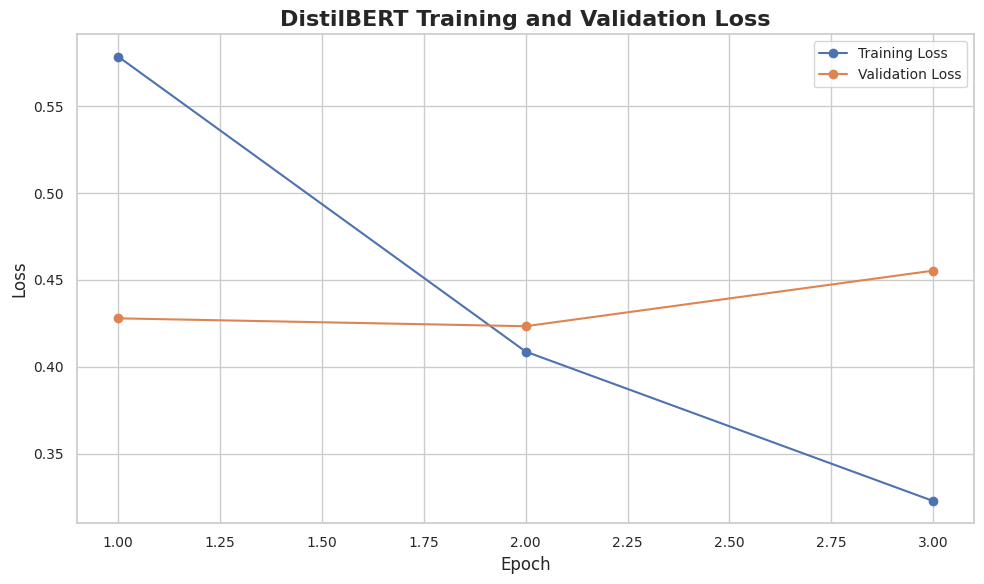

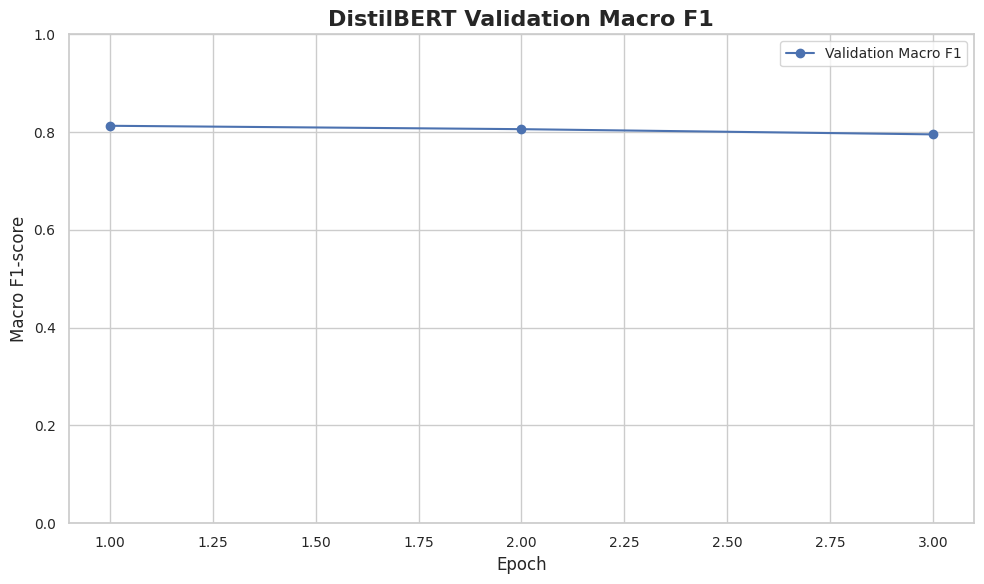

,Epoch,Train Loss,Validation Loss,Validation Accuracy,Validation Macro F1
0,1,0.578581,0.427895,0.817204,0.812966
1,2,0.408736,0.423356,0.809140,0.806044
2,3,0.322721,0.455342,0.798387,0.795393


In [143]:
# This cell plots DistilBERT training and validation metrics.
# ============================================================

distilbert_history_df = pd.DataFrame(distilbert_training_history)

distilbert_history_df.to_csv(
    "results_notebook3/distilbert_training_history.csv",
    index=False
)

# Loss curve
plt.figure(figsize=(10, 6))
plt.plot(distilbert_history_df["Epoch"], distilbert_history_df["Train Loss"], marker="o", label="Training Loss")
plt.plot(distilbert_history_df["Epoch"], distilbert_history_df["Validation Loss"], marker="o", label="Validation Loss")
plt.title("DistilBERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/distilbert_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Validation Macro F1 curve
plt.figure(figsize=(10, 6))
plt.plot(distilbert_history_df["Epoch"], distilbert_history_df["Validation Macro F1"], marker="o", label="Validation Macro F1")
plt.title("DistilBERT Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/distilbert_validation_macro_f1_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

distilbert_history_df

# **Evaluate Best DistilBERT on Test Set**

DistilBERT test result:
{'Task': 'Aspect-Level Sentiment Classification', 'Model': 'DistilBERT', 'Accuracy': 0.7984, 'Macro Precision': 0.8036, 'Macro Recall': 0.7886, 'Macro F1': 0.792, 'Weighted F1': 0.7959}

DistilBERT classification report:
              precision    recall  f1-score   support

    negative       0.78      0.88      0.83       343
    positive       0.82      0.70      0.76       277

    accuracy                           0.80       620
   macro avg       0.80      0.79      0.79       620
weighted avg       0.80      0.80      0.80       620



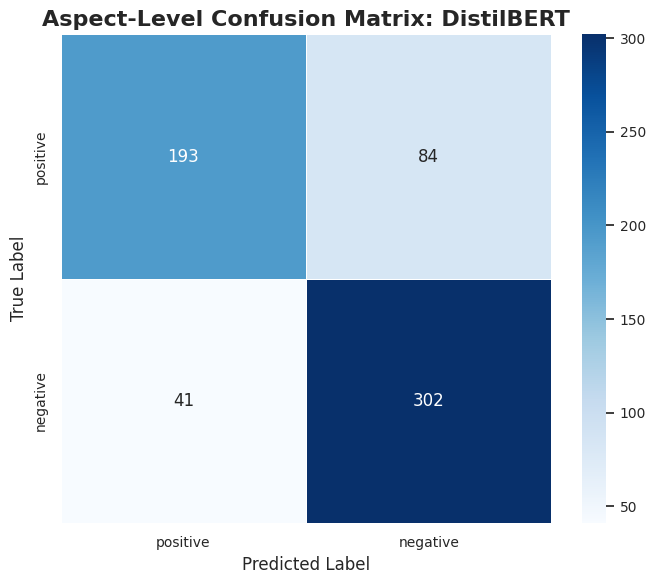

array([[193,  84],
       [ 41, 302]])

In [144]:
# This cell loads the best saved DistilBERT model and evaluates
# it on the test set.
# ============================================================

# Load best model weights
distilbert_model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

distilbert_model = distilbert_model.to(device)

test_loss, test_accuracy, test_macro_f1, test_labels_encoded, test_predictions_encoded = evaluate_distilbert_model(
    distilbert_model,
    test_loader,
    device
)

test_labels = [
    reverse_distilbert_label_mapping[label]
    for label in test_labels_encoded
]

test_predictions = [
    reverse_distilbert_label_mapping[pred]
    for pred in test_predictions_encoded
]

distilbert_result = evaluate_predictions(
    task_name="Aspect-Level Sentiment Classification",
    model_name="DistilBERT",
    y_true=test_labels,
    y_pred=test_predictions
)

aspect_model_results.append(distilbert_result)

print("DistilBERT test result:")
print(distilbert_result)

print("\nDistilBERT classification report:")
save_classification_report(
    y_true=test_labels,
    y_pred=test_predictions,
    output_path="results_notebook3/distilbert_classification_report.txt"
)

plot_confusion_matrix(
    y_true=test_labels,
    y_pred=test_predictions,
    labels=["positive", "negative"],
    title="Aspect-Level Confusion Matrix: DistilBERT",
    output_path="visualizations_notebook3/distilbert_confusion_matrix.png"
)

# **Save DistilBERT Predictions**

In [145]:
# This cell saves DistilBERT predictions for later error analysis.
# ============================================================

distilbert_predictions_df = save_prediction_examples(
    texts=X_transformer_test,
    y_true=test_labels,
    y_pred=test_predictions,
    output_path="results_notebook3/distilbert_predictions.csv"
)

distilbert_predictions_df.head()

,Text,Actual,Predicted,Correct
0,i think there should be directions on how to s...,negative,positive,False
1,this is a replacement for those who do not wan...,positive,positive,True
2,for being a secure messaging app it has one hu...,negative,negative,True
3,so i go on the mobile version of discord and i...,negative,negative,True
4,will purchase if it is [SEP] cost [SEP] purchase,positive,positive,True


# **DistilBERT Misclassified Examples**

In [146]:
# This cell extracts examples misclassified by DistilBERT.
#
# Assignment usage:
# - Useful for Discussion section
# ============================================================

distilbert_misclassified_examples = distilbert_predictions_df[
    distilbert_predictions_df["Correct"] == False
].copy()

distilbert_misclassified_examples.to_csv(
    "results_notebook3/distilbert_misclassified_examples.csv",
    index=False
)

print("Number of DistilBERT misclassified examples:")
print(len(distilbert_misclassified_examples))

distilbert_misclassified_examples.head(15)

Number of DistilBERT misclassified examples:
125


,Text,Actual,Predicted,Correct
0,i think there should be directions on how to s...,negative,positive,False
8,it is very consistent with the desktop version...,positive,negative,False
16,it wo not allow me to have an avatar photo as ...,positive,negative,False
17,but many thing from years ago may have not bee...,positive,negative,False
21,however i do it uninstalling and reinstalling ...,positive,negative,False
25,bucks for an app at least us know improvements...,positive,negative,False
29,however in app sounds return each and every ti...,positive,negative,False
35,so in the recent updates facebook finally sync...,positive,negative,False
38,i got the app and i was still logged into my o...,positive,negative,False
41,since i could not buy it at a store because of...,positive,negative,False


# **Save DistilBERT Model and Tokenizer**

In [147]:
# This saves the fine-tuned DistilBERT model and tokenizer.
#
# Note:
# The saved model folder may be large. It can be included in
# GitHub only if file size is acceptable. Otherwise, save results
# and mention the model was trained in Colab.
# ============================================================

distilbert_save_dir = "models_notebook3/distilbert_aspect_sentiment_model"

distilbert_model.save_pretrained(distilbert_save_dir)
distilbert_tokenizer.save_pretrained(distilbert_save_dir)

print("DistilBERT model and tokenizer saved to:")
print(distilbert_save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model and tokenizer saved to:
models_notebook3/distilbert_aspect_sentiment_model


# 8. Final Model Comparison and Best Model Selection

This phase combines all model results from the review-level and aspect-level sentiment classification tasks.

The goals are:

1. Compare traditional machine learning, deep learning, and transformer models.
2. Identify the best review-level sentiment classification model.
3. Identify the best aspect-level sentiment classification model.
4. Select the final best model for the project.
5. Generate final comparison tables and report-ready charts.

The final model is selected mainly based on **Macro F1-score**, because Macro F1 treats all classes equally and is more reliable when class distribution is not perfectly balanced.

For this project, the main task is **Aspect-Level Sentiment Classification**, so the final best model is expected to come from the ABSA task.

# **Combine Review-Level Model Results**

In [148]:
# This cell prepares the final review-level model comparison table.
#
# Task A:
# - Rating-based review-level sentiment classification
#
# Assignment usage:
# - Supports Sentiment Analysis section
# - Shows best model for rating-based sentiment classification
# ============================================================

final_review_results_df = pd.DataFrame(document_model_results)

final_review_results_df = final_review_results_df[
    final_review_results_df["Task"] == "Review-Level Rating-Based Sentiment"
].copy()

final_review_results_df = final_review_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

final_review_results_df.to_csv(
    "results_notebook3/final_review_level_model_comparison.csv",
    index=False
)

final_review_results_df

,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Review-Level Rating-Based Sentiment,Logistic Regression,0.6563,0.5668,0.5649,0.5652,0.6502
1,Review-Level Rating-Based Sentiment,Linear SVM,0.6656,0.5585,0.5504,0.5446,0.6421
2,Review-Level Rating-Based Sentiment,Random Forest,0.6656,0.4618,0.5094,0.4742,0.6028
3,Review-Level Rating-Based Sentiment,Naive Bayes,0.5851,0.4643,0.4220,0.3788,0.4982


# **Combine Aspect-Level Model Results**

In [149]:
# This cell prepares the final aspect-level model comparison table.
#
# Task B:
# - Aspect-level sentiment classification
#
# Assignment usage:
# - Supports ABSA and Transformer / Deep Learning Models sections
# - Shows the strongest final model for the main task
# ============================================================

final_aspect_results_df = pd.DataFrame(aspect_model_results)

final_aspect_results_df = final_aspect_results_df[
    final_aspect_results_df["Task"] == "Aspect-Level Sentiment Classification"
].copy()

final_aspect_results_df = final_aspect_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

final_aspect_results_df.to_csv(
    "results_notebook3/final_aspect_level_model_comparison.csv",
    index=False
)

final_aspect_results_df

,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Aspect-Level Sentiment Classification,DistilBERT,0.7984,0.8036,0.7886,0.7920,0.7959
1,Aspect-Level Sentiment Classification,Linear SVM,0.7194,0.7161,0.7158,0.7159,0.7193
2,Aspect-Level Sentiment Classification,Naive Bayes,0.7306,0.7553,0.7100,0.7096,0.7179
3,Aspect-Level Sentiment Classification,Random Forest,0.7129,0.7097,0.7068,0.7078,0.7119
4,Aspect-Level Sentiment Classification,BiLSTM,0.7065,0.7030,0.7024,0.7027,0.7062
5,Aspect-Level Sentiment Classification,Logistic Regression,0.6903,0.6876,0.6889,0.6880,0.6908


# **Create Overall Final Model Comparison Table**

In [150]:
# This cell combines both task results into one final table.
#
# Assignment usage:
# - Main model comparison table for Result & Visualization section
# - Useful for report and presentation
# ============================================================

final_model_comparison_df = pd.concat(
    [final_review_results_df, final_aspect_results_df],
    axis=0
).reset_index(drop=True)

final_model_comparison_df = final_model_comparison_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

final_model_comparison_df.to_csv(
    "results_notebook3/final_all_model_comparison.csv",
    index=False
)

final_model_comparison_df

,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Aspect-Level Sentiment Classification,DistilBERT,0.7984,0.8036,0.7886,0.7920,0.7959
1,Aspect-Level Sentiment Classification,Linear SVM,0.7194,0.7161,0.7158,0.7159,0.7193
2,Aspect-Level Sentiment Classification,Naive Bayes,0.7306,0.7553,0.7100,0.7096,0.7179
3,Aspect-Level Sentiment Classification,Random Forest,0.7129,0.7097,0.7068,0.7078,0.7119
4,Aspect-Level Sentiment Classification,BiLSTM,0.7065,0.7030,0.7024,0.7027,0.7062
5,Aspect-Level Sentiment Classification,Logistic Regression,0.6903,0.6876,0.6889,0.6880,0.6908
6,Review-Level Rating-Based Sentiment,Logistic Regression,0.6563,0.5668,0.5649,0.5652,0.6502
7,Review-Level Rating-Based Sentiment,Linear SVM,0.6656,0.5585,0.5504,0.5446,0.6421
8,Review-Level Rating-Based Sentiment,Random Forest,0.6656,0.4618,0.5094,0.4742,0.6028
9,Review-Level Rating-Based Sentiment,Naive Bayes,0.5851,0.4643,0.4220,0.3788,0.4982


# **Final Review-Level Model Comparison Chart**

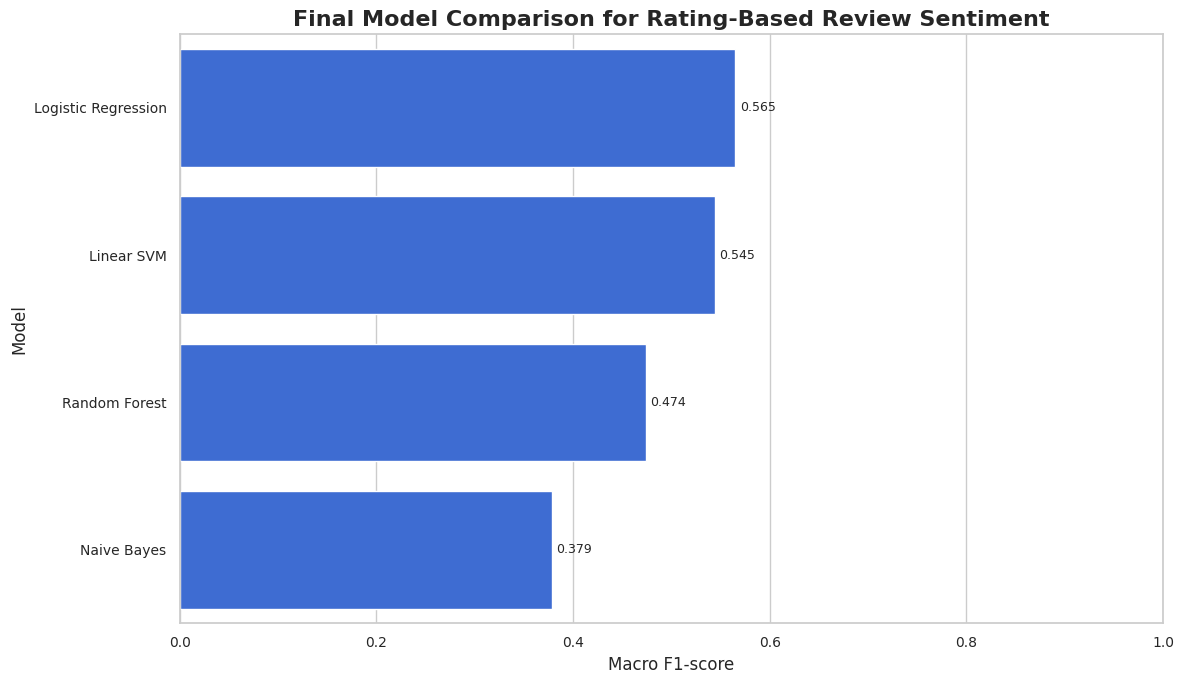

In [151]:
# This chart compares review-level models using Macro F1-score.
#
# Assignment usage:
# - Report-ready chart for rating-based sentiment classification
# ============================================================

plot_model_comparison(
    results_df=final_review_results_df,
    title="Final Model Comparison for Rating-Based Review Sentiment",
    output_path="visualizations_notebook3/final_review_model_comparison_macro_f1.png"
)



# **Final Aspect-Level Model Comparison Chart**

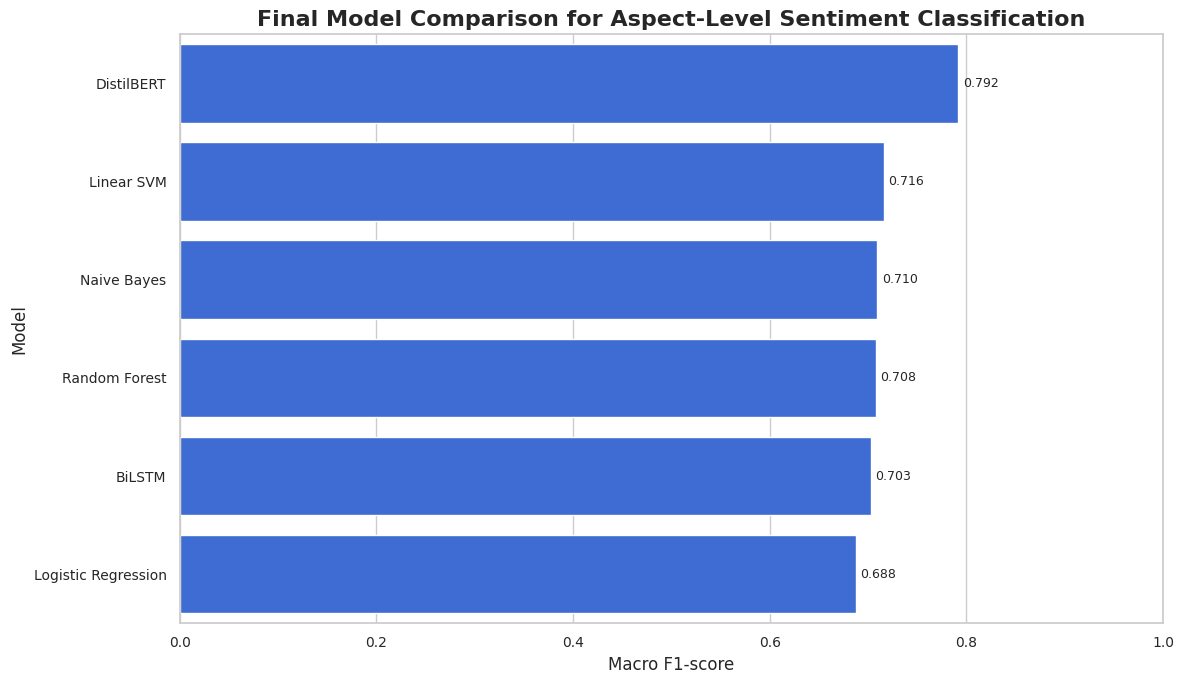

In [152]:
# This chart compares all aspect-level models using Macro F1-score.
#
# Assignment usage:
# - Main report visual for model comparison
# - Shows DistilBERT performance against ML and BiLSTM
# ============================================================

plot_model_comparison(
    results_df=final_aspect_results_df,
    title="Final Model Comparison for Aspect-Level Sentiment Classification",
    output_path="visualizations_notebook3/final_aspect_model_comparison_macro_f1.png"
)

# **Final Weighted F1 Comparison Chart**

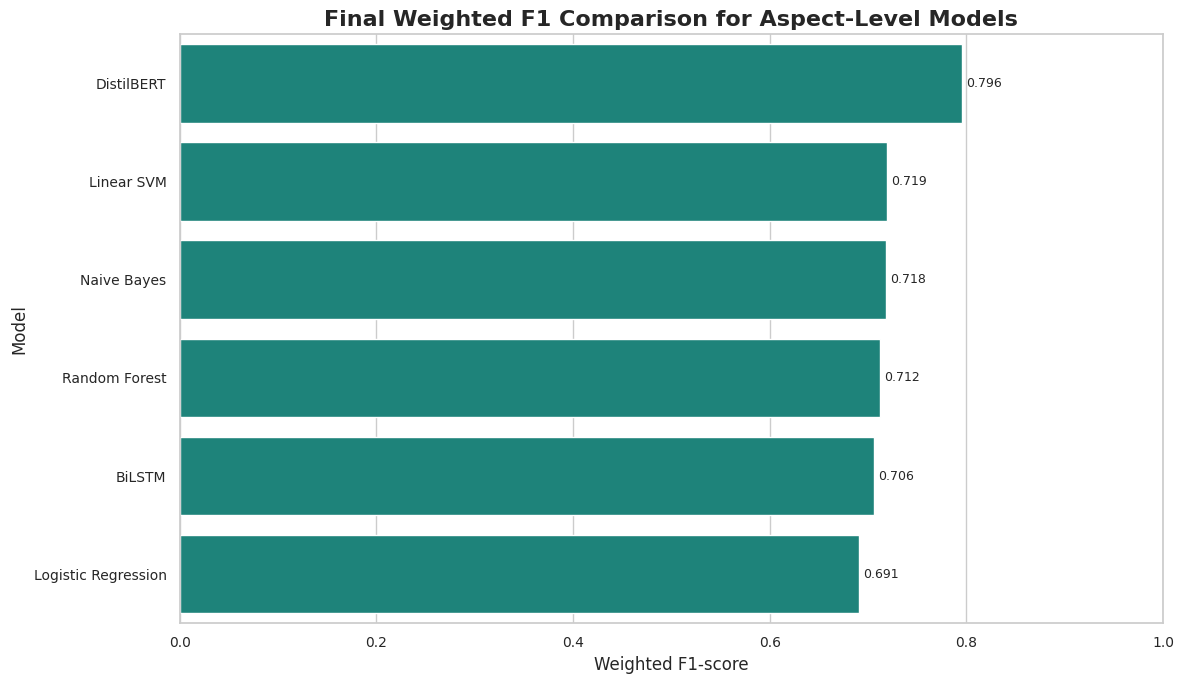

In [153]:
# This chart compares aspect-level models using Weighted F1-score.
#
# Assignment usage:
# - Complements Macro F1 comparison
# - Useful because aspect sentiment classes are not perfectly equal
# ============================================================

weighted_aspect_plot_df = final_aspect_results_df.sort_values(
    by="Weighted F1",
    ascending=False
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=weighted_aspect_plot_df,
    x="Weighted F1",
    y="Model",
    color=MAIN_TEAL
)

plt.title("Final Weighted F1 Comparison for Aspect-Level Models")
plt.xlabel("Weighted F1-score")
plt.ylabel("Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.xlim(0, 1)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/final_aspect_model_comparison_weighted_f1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Select Best Models**

In [154]:
# This cell selects:
# - Best review-level model
# - Best aspect-level model
# - Overall final best model
#
# Selection criterion:
# - Macro F1-score
#
# Assignment usage:
# - Supports final model decision in report
# ============================================================

best_review_model = final_review_results_df.iloc[0]
best_aspect_model = final_aspect_results_df.iloc[0]
overall_best_model = final_model_comparison_df.iloc[0]

best_models_summary = pd.DataFrame([
    {
        "Selection": "Best Review-Level Model",
        "Task": best_review_model["Task"],
        "Model": best_review_model["Model"],
        "Accuracy": best_review_model["Accuracy"],
        "Macro F1": best_review_model["Macro F1"],
        "Weighted F1": best_review_model["Weighted F1"]
    },
    {
        "Selection": "Best Aspect-Level Model",
        "Task": best_aspect_model["Task"],
        "Model": best_aspect_model["Model"],
        "Accuracy": best_aspect_model["Accuracy"],
        "Macro F1": best_aspect_model["Macro F1"],
        "Weighted F1": best_aspect_model["Weighted F1"]
    },
    {
        "Selection": "Overall Best Model",
        "Task": overall_best_model["Task"],
        "Model": overall_best_model["Model"],
        "Accuracy": overall_best_model["Accuracy"],
        "Macro F1": overall_best_model["Macro F1"],
        "Weighted F1": overall_best_model["Weighted F1"]
    }
])

best_models_summary.to_csv(
    "results_notebook3/best_models_summary.csv",
    index=False
)

best_models_summary

,Selection,Task,Model,Accuracy,Macro F1,Weighted F1
0,Best Review-Level Model,Review-Level Rating-Based Sentiment,Logistic Regression,0.6563,0.5652,0.6502
1,Best Aspect-Level Model,Aspect-Level Sentiment Classification,DistilBERT,0.7984,0.7920,0.7959
2,Overall Best Model,Aspect-Level Sentiment Classification,DistilBERT,0.7984,0.7920,0.7959


# **Model Type Summary**

In [155]:
# This cell groups models by modelling approach:
# - Traditional ML
# - Deep Learning
# - Transformer
#
# Assignment usage:
# - Supports the report discussion comparing methods
# ============================================================

def classify_model_type(model_name):
    if model_name in ["Naive Bayes", "Logistic Regression", "Linear SVM", "Random Forest"]:
        return "Traditional ML"
    elif model_name == "BiLSTM":
        return "Deep Learning"
    elif model_name == "DistilBERT":
        return "Transformer"
    else:
        return "Other"

final_aspect_results_df["Model Type"] = final_aspect_results_df["Model"].apply(
    classify_model_type
)

model_type_summary = (
    final_aspect_results_df
    .groupby("Model Type")[["Accuracy", "Macro F1", "Weighted F1"]]
    .max()
    .reset_index()
    .sort_values(by="Macro F1", ascending=False)
)

model_type_summary.to_csv(
    "results_notebook3/model_type_summary.csv",
    index=False
)

model_type_summary

,Model Type,Accuracy,Macro F1,Weighted F1
2,Transformer,0.7984,0.7920,0.7959
1,Traditional ML,0.7306,0.7159,0.7193
0,Deep Learning,0.7065,0.7027,0.7062


# **Model Type Comparison Chart**

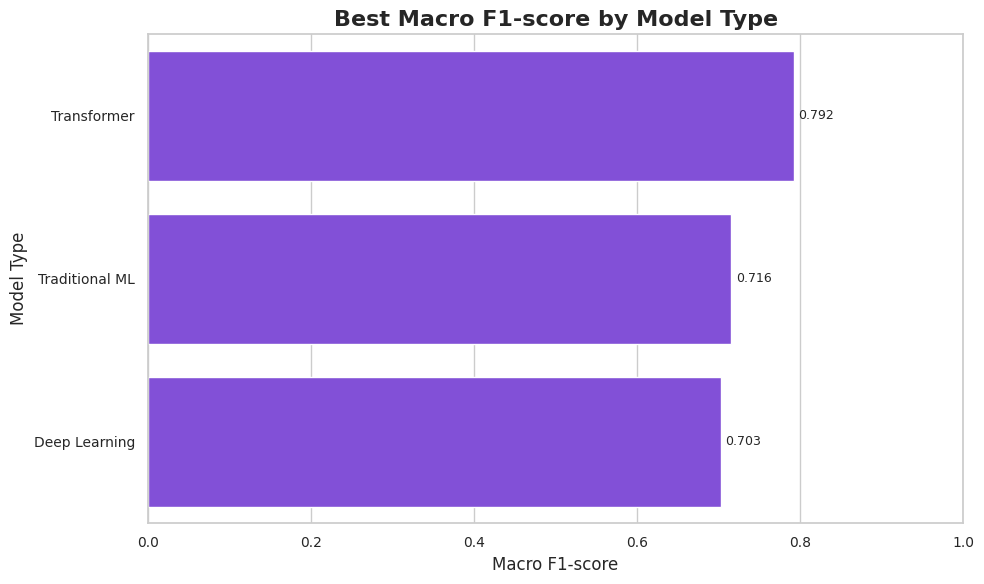

In [156]:
# This chart compares the best performance by model type.
#
# Assignment usage:
# - Useful for showing that transformer-based modelling performed best
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=model_type_summary,
    x="Macro F1",
    y="Model Type",
    color=MAIN_PURPLE
)

plt.title("Best Macro F1-score by Model Type")
plt.xlabel("Macro F1-score")
plt.ylabel("Model Type")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.xlim(0, 1)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/model_type_macro_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Create Final Model Findings Table**

In [157]:
# This cell creates a concise findings table for the report.
#
# Assignment usage:
# - Useful for Result & Visualization section
# - Useful for Discussion section
# ============================================================

final_model_findings = pd.DataFrame([
    {
        "Finding": "Best review-level model",
        "Result": f"{best_review_model['Model']} achieved Macro F1 = {best_review_model['Macro F1']}"
    },
    {
        "Finding": "Best aspect-level model",
        "Result": f"{best_aspect_model['Model']} achieved Macro F1 = {best_aspect_model['Macro F1']}"
    },
    {
        "Finding": "Overall best model",
        "Result": f"{overall_best_model['Model']} on {overall_best_model['Task']} achieved Macro F1 = {overall_best_model['Macro F1']}"
    },
    {
        "Finding": "Traditional ML strength",
        "Result": f"Best traditional ABSA model was {best_aspect_traditional_model_name} with Macro F1 = {best_aspect_traditional_macro_f1}"
    },
    {
        "Finding": "Deep learning result",
        "Result": f"BiLSTM achieved Macro F1 = {bilstm_result['Macro F1']} on aspect-level sentiment"
    },
    {
        "Finding": "Transformer result",
        "Result": f"DistilBERT achieved Macro F1 = {distilbert_result['Macro F1']} and outperformed all other models"
    }
])

final_model_findings.to_csv(
    "results_notebook3/final_model_findings.csv",
    index=False
)

final_model_findings

,Finding,Result
0,Best review-level model,Logistic Regression achieved Macro F1 = 0.5652
1,Best aspect-level model,DistilBERT achieved Macro F1 = 0.792
2,Overall best model,DistilBERT on Aspect-Level Sentiment Classific...
3,Traditional ML strength,Best traditional ABSA model was Linear SVM wit...
4,Deep learning result,BiLSTM achieved Macro F1 = 0.7027 on aspect-le...
5,Transformer result,DistilBERT achieved Macro F1 = 0.792 and outpe...


# 8.1 Phase 7B: Optimized Transformer Experiment

The baseline transformer model, DistilBERT, achieved the best result so far for the main ABSA task.

However, to improve performance further, this phase conducts an additional optimized transformer experiment using:

1. A clearer prompt-style input format  
2. A stronger transformer model: `roberta-base`  
3. Early stopping based on validation Macro F1-score  
4. Honest comparison against the previous DistilBERT result  

The purpose of this phase is not to force a higher score, but to test whether a stronger transformer and clearer input representation can improve aspect-level sentiment classification.

## Optimized Input Format

Instead of using:

```text
sentence [SEP] category [SEP] term

this experiment uses:

Review sentence: <sentence> Aspect category: <category> Aspect term: <term>

If RoBERTa improves over DistilBERT, it will be considered the final best model.
If it does not improve, DistilBERT remains the final best model.

# **Prepare Optimized Transformer Input**

In [158]:
# This cell creates a clearer input format for transformer models.
#
# Original input:
# sentence [SEP] category [SEP] term
#
# Optimized input:
# Review sentence: <sentence> Aspect category: <category> Aspect term: <term>
#
# Assignment usage:
# - Shows model improvement attempt
# - Supports Transformer / Deep Learning Models section
# - Helps explain feature engineering for transformer input
# ============================================================

optimized_transformer_df = aspect_df[
    ["sentence", "category", "term", "sentiment"]
].copy()

optimized_transformer_df["optimized_input"] = (
    "Review sentence: " +
    optimized_transformer_df["sentence"].astype(str) +
    " Aspect category: " +
    optimized_transformer_df["category"].astype(str) +
    " Aspect term: " +
    optimized_transformer_df["term"].astype(str)
)

optimized_label_mapping = {
    "negative": 0,
    "positive": 1
}

reverse_optimized_label_mapping = {
    0: "negative",
    1: "positive"
}

optimized_transformer_df["label"] = optimized_transformer_df["sentiment"].map(
    optimized_label_mapping
)

print("Optimized transformer dataset prepared.")
print("Shape:", optimized_transformer_df.shape)

print("\nLabel distribution:")
print(optimized_transformer_df["sentiment"].value_counts())

optimized_transformer_df[["optimized_input", "sentiment", "label"]].head()

Optimized transformer dataset prepared.
Shape: (3097, 6)

Label distribution:
sentiment
negative    1715
positive    1382
Name: count, dtype: int64


,optimized_input,sentiment,label
0,Review sentence: I just drained about 15-20 pe...,negative,0
1,"Review sentence: On an iPad Pro, I would hones...",negative,0
2,Review sentence: Would be awesome if you could...,negative,0
3,Review sentence: I've always had trouble with ...,negative,0
4,Review sentence: But the mobile recent update ...,negative,0


# **Train RoBERTa with Early Stopping**

In [159]:
# This cell fine-tunes roberta-base using the optimized input format.
#
# Early stopping:
# - Tracks validation Macro F1-score
# - Saves the best model
# - Stops if validation Macro F1 does not improve
#
# Important:
# Use GPU if possible:
# Runtime > Change runtime type > T4 GPU
# ============================================================

OPTIMIZED_MODEL_NAME = "roberta-base"
OPTIMIZED_MAX_LENGTH = 128
OPTIMIZED_BATCH_SIZE = 16 if torch.cuda.is_available() else 8
OPTIMIZED_EPOCHS = 5
OPTIMIZED_LEARNING_RATE = 1e-5
OPTIMIZED_PATIENCE = 2

# Train / validation / test split
X_opt = optimized_transformer_df["optimized_input"]
y_opt = optimized_transformer_df["label"]

X_opt_temp_train, X_opt_test, y_opt_temp_train, y_opt_test = train_test_split(
    X_opt,
    y_opt,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_opt
)

X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_opt_temp_train,
    y_opt_temp_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_opt_temp_train
)

print("Optimized transformer split:")
print("Train:", len(X_opt_train))
print("Validation:", len(X_opt_val))
print("Test:", len(X_opt_test))

# Load tokenizer and model
optimized_tokenizer = AutoTokenizer.from_pretrained(OPTIMIZED_MODEL_NAME)

optimized_model = AutoModelForSequenceClassification.from_pretrained(
    OPTIMIZED_MODEL_NAME,
    num_labels=2
)

optimized_model = optimized_model.to(device)

# Create datasets and dataloaders
optimized_train_dataset = SentimentDataset(
    X_opt_train,
    y_opt_train,
    optimized_tokenizer,
    OPTIMIZED_MAX_LENGTH
)

optimized_val_dataset = SentimentDataset(
    X_opt_val,
    y_opt_val,
    optimized_tokenizer,
    OPTIMIZED_MAX_LENGTH
)

optimized_test_dataset = SentimentDataset(
    X_opt_test,
    y_opt_test,
    optimized_tokenizer,
    OPTIMIZED_MAX_LENGTH
)

optimized_train_loader = DataLoader(
    optimized_train_dataset,
    batch_size=OPTIMIZED_BATCH_SIZE,
    shuffle=True
)

optimized_val_loader = DataLoader(
    optimized_val_dataset,
    batch_size=OPTIMIZED_BATCH_SIZE,
    shuffle=False
)

optimized_test_loader = DataLoader(
    optimized_test_dataset,
    batch_size=OPTIMIZED_BATCH_SIZE,
    shuffle=False
)

# Optimizer and scheduler
optimized_optimizer = torch.optim.AdamW(
    optimized_model.parameters(),
    lr=OPTIMIZED_LEARNING_RATE
)

optimized_total_steps = len(optimized_train_loader) * OPTIMIZED_EPOCHS

optimized_scheduler = get_linear_schedule_with_warmup(
    optimized_optimizer,
    num_warmup_steps=0,
    num_training_steps=optimized_total_steps
)

# Training loop with early stopping
optimized_training_history = []

best_optimized_val_macro_f1 = 0
optimized_no_improve_count = 0
best_optimized_model_path = "models_notebook3/best_optimized_roberta_model.pt"

for epoch in range(OPTIMIZED_EPOCHS):
    print("=" * 100)
    print(f"Optimized RoBERTa Epoch {epoch + 1}/{OPTIMIZED_EPOCHS}")
    print("=" * 100)

    train_loss = train_distilbert_one_epoch(
        optimized_model,
        optimized_train_loader,
        optimized_optimizer,
        optimized_scheduler,
        device
    )

    val_loss, val_accuracy, val_macro_f1, val_labels, val_predictions = evaluate_distilbert_model(
        optimized_model,
        optimized_val_loader,
        device
    )

    epoch_result = {
        "Epoch": epoch + 1,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_accuracy,
        "Validation Macro F1": val_macro_f1
    }

    optimized_training_history.append(epoch_result)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Macro F1: {val_macro_f1:.4f}")

    if val_macro_f1 > best_optimized_val_macro_f1:
        best_optimized_val_macro_f1 = val_macro_f1
        optimized_no_improve_count = 0
        torch.save(optimized_model.state_dict(), best_optimized_model_path)
        print("Best optimized RoBERTa model saved.")
    else:
        optimized_no_improve_count += 1
        print(f"No improvement count: {optimized_no_improve_count}/{OPTIMIZED_PATIENCE}")

    if optimized_no_improve_count >= OPTIMIZED_PATIENCE:
        print("Early stopping triggered.")
        break

optimized_history_df = pd.DataFrame(optimized_training_history)

optimized_history_df.to_csv(
    "results_notebook3/optimized_roberta_training_history.csv",
    index=False
)

optimized_history_df

Optimized transformer split:
Train: 2105
Validation: 372
Test: 620


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Optimized RoBERTa Epoch 1/5
Train Loss: 0.5764
Validation Loss: 0.3976
Validation Accuracy: 0.8495
Validation Macro F1: 0.8482
Best optimized RoBERTa model saved.
Optimized RoBERTa Epoch 2/5
Train Loss: 0.4159
Validation Loss: 0.4116
Validation Accuracy: 0.8468
Validation Macro F1: 0.8413
No improvement count: 1/2
Optimized RoBERTa Epoch 3/5
Train Loss: 0.3521
Validation Loss: 0.4197
Validation Accuracy: 0.8360
Validation Macro F1: 0.8336
No improvement count: 2/2
Early stopping triggered.


,Epoch,Train Loss,Validation Loss,Validation Accuracy,Validation Macro F1
0,1,0.576373,0.397616,0.849462,0.848194
1,2,0.415925,0.411583,0.846774,0.841315
2,3,0.352139,0.419750,0.836022,0.833586


# **Evaluate Optimized RoBERTa and Compare with DistilBERT**

Optimized RoBERTa test result:
{'Task': 'Aspect-Level Sentiment Classification', 'Model': 'Optimized RoBERTa', 'Accuracy': 0.8145, 'Macro Precision': 0.8138, 'Macro Recall': 0.8098, 'Macro F1': 0.8113, 'Weighted F1': 0.8139}

Optimized RoBERTa classification report:
              precision    recall  f1-score   support

    negative       0.82      0.85      0.84       343
    positive       0.81      0.77      0.79       277

    accuracy                           0.81       620
   macro avg       0.81      0.81      0.81       620
weighted avg       0.81      0.81      0.81       620



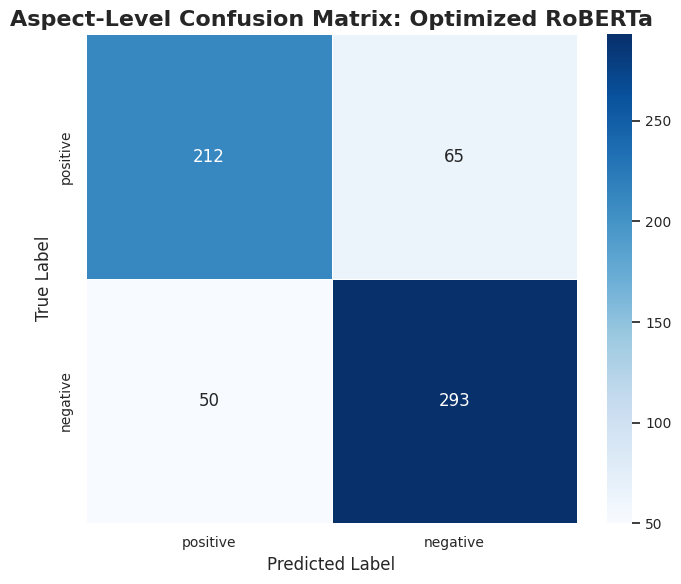


Transformer comparison:


,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Aspect-Level Sentiment Classification,Optimized RoBERTa,0.8145,0.8138,0.8098,0.8113,0.8139
1,Aspect-Level Sentiment Classification,DistilBERT,0.7984,0.8036,0.7886,0.7920,0.7959



Number of optimized RoBERTa misclassified examples:
115


,Text,Actual,Predicted,Correct
3,Review sentence: So I go on the mobile version...,negative,positive,False
7,Review sentence: Why put a limit on how often ...,negative,positive,False
8,Review sentence: It is very consistent with th...,positive,negative,False
10,Review sentence: Lower th price to high for a ...,negative,positive,False
13,Review sentence: I did enable two factor authe...,negative,positive,False
16,Review sentence: It won't allow me to have an ...,positive,negative,False
17,Review sentence: But many thing from years ago...,positive,negative,False
21,"Review sentence: However I do it, uninstalling...",positive,negative,False
25,Review sentence: 5 bucks for an app at least u...,positive,negative,False
29,"Review sentence: However, in-app sounds return...",positive,negative,False


In [160]:
# This cell evaluates the best optimized RoBERTa model on the test set
# and compares it with the previous DistilBERT result.
# ============================================================

# Load best optimized model
optimized_model.load_state_dict(
    torch.load(best_optimized_model_path, map_location=device)
)

optimized_model = optimized_model.to(device)

opt_test_loss, opt_test_accuracy, opt_test_macro_f1, opt_test_labels_encoded, opt_test_predictions_encoded = evaluate_distilbert_model(
    optimized_model,
    optimized_test_loader,
    device
)

opt_test_labels = [
    reverse_optimized_label_mapping[label]
    for label in opt_test_labels_encoded
]

opt_test_predictions = [
    reverse_optimized_label_mapping[pred]
    for pred in opt_test_predictions_encoded
]

optimized_roberta_result = evaluate_predictions(
    task_name="Aspect-Level Sentiment Classification",
    model_name="Optimized RoBERTa",
    y_true=opt_test_labels,
    y_pred=opt_test_predictions
)

# Add to aspect model results
aspect_model_results.append(optimized_roberta_result)

print("Optimized RoBERTa test result:")
print(optimized_roberta_result)

print("\nOptimized RoBERTa classification report:")
save_classification_report(
    y_true=opt_test_labels,
    y_pred=opt_test_predictions,
    output_path="results_notebook3/optimized_roberta_classification_report.txt"
)

plot_confusion_matrix(
    y_true=opt_test_labels,
    y_pred=opt_test_predictions,
    labels=["positive", "negative"],
    title="Aspect-Level Confusion Matrix: Optimized RoBERTa",
    output_path="visualizations_notebook3/optimized_roberta_confusion_matrix.png"
)

optimized_roberta_predictions_df = save_prediction_examples(
    texts=X_opt_test,
    y_true=opt_test_labels,
    y_pred=opt_test_predictions,
    output_path="results_notebook3/optimized_roberta_predictions.csv"
)

optimized_roberta_misclassified_examples = optimized_roberta_predictions_df[
    optimized_roberta_predictions_df["Correct"] == False
].copy()

optimized_roberta_misclassified_examples.to_csv(
    "results_notebook3/optimized_roberta_misclassified_examples.csv",
    index=False
)

# Compare transformer results
transformer_comparison_df = pd.DataFrame([
    distilbert_result,
    optimized_roberta_result
]).sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

transformer_comparison_df.to_csv(
    "results_notebook3/transformer_comparison_distilbert_vs_roberta.csv",
    index=False
)

print("\nTransformer comparison:")
display(transformer_comparison_df)

print("\nNumber of optimized RoBERTa misclassified examples:")
print(len(optimized_roberta_misclassified_examples))

optimized_roberta_misclassified_examples.head(10)

# **Plot Optimized RoBERTa Training and Transformer Comparison**

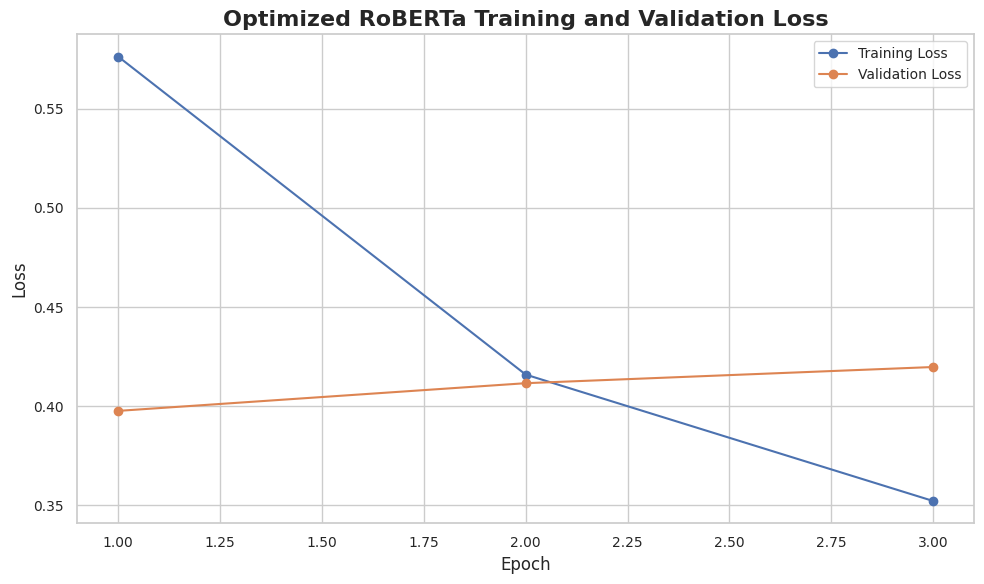

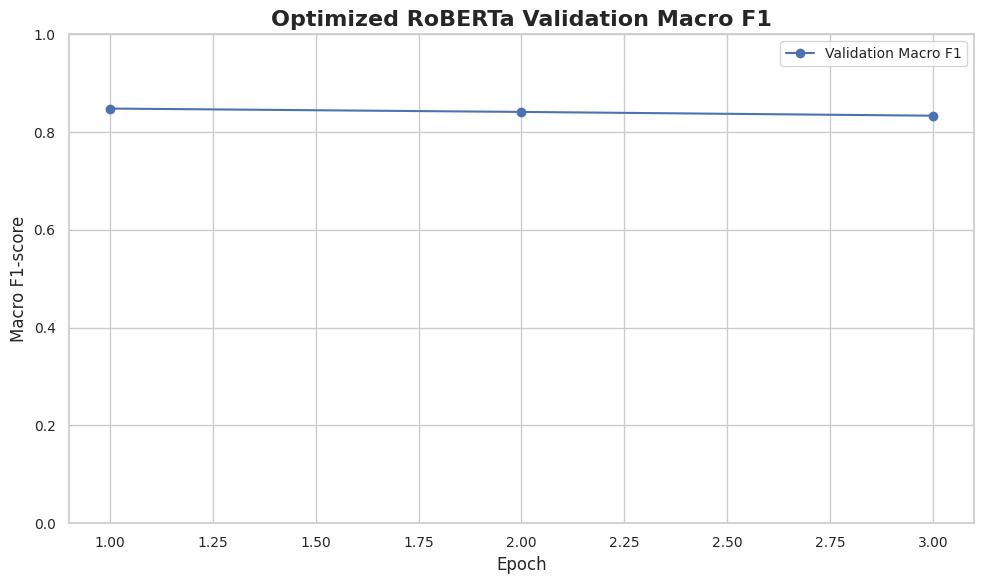

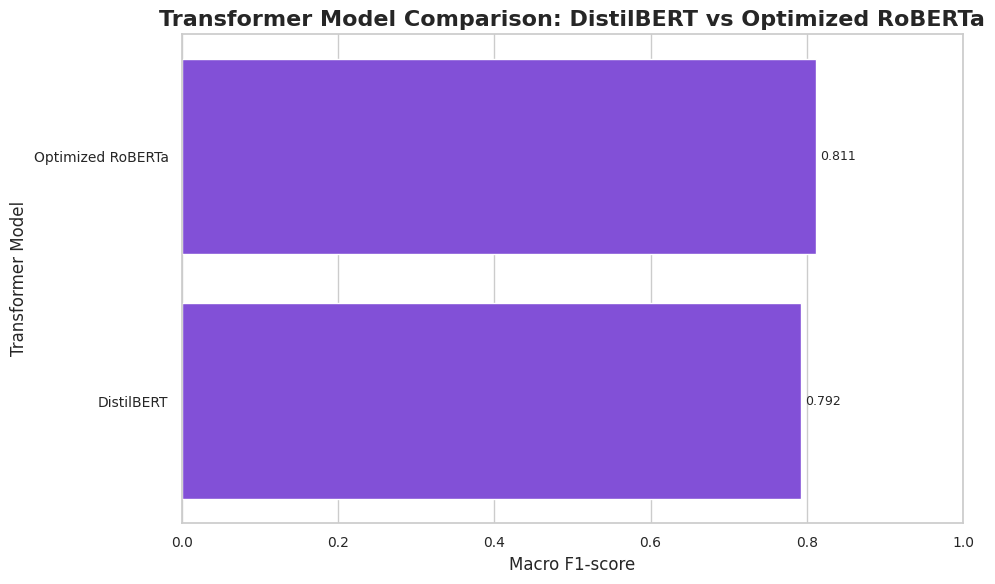

In [161]:
# This cell creates:
# - Optimized RoBERTa loss curve
# - Optimized RoBERTa validation Macro F1 curve
# - DistilBERT vs Optimized RoBERTa comparison chart
# ============================================================

# Loss curve
plt.figure(figsize=(10, 6))
plt.plot(optimized_history_df["Epoch"], optimized_history_df["Train Loss"], marker="o", label="Training Loss")
plt.plot(optimized_history_df["Epoch"], optimized_history_df["Validation Loss"], marker="o", label="Validation Loss")
plt.title("Optimized RoBERTa Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/optimized_roberta_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Validation Macro F1 curve
plt.figure(figsize=(10, 6))
plt.plot(optimized_history_df["Epoch"], optimized_history_df["Validation Macro F1"], marker="o", label="Validation Macro F1")
plt.title("Optimized RoBERTa Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/optimized_roberta_validation_macro_f1_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Transformer comparison chart
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=transformer_comparison_df,
    x="Macro F1",
    y="Model",
    color=MAIN_PURPLE
)

plt.title("Transformer Model Comparison: DistilBERT vs Optimized RoBERTa")
plt.xlabel("Macro F1-score")
plt.ylabel("Transformer Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.xlim(0, 1)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/transformer_comparison_distilbert_vs_roberta.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 8.2 Phase 7C: Stronger Transformer Experiment with DeBERTa and Threshold Tuning

The Optimized RoBERTa model improved the transformer result, but the test accuracy remained around 81%.

To make one final honest improvement attempt, this phase tests:

1. A stronger transformer model: `microsoft/deberta-v3-small`
2. The same optimized prompt-style input format
3. Early stopping based on validation Macro F1-score
4. Validation-based threshold tuning

Threshold tuning is used because the default classifier threshold may not be optimal for the positive and negative class balance. The best threshold is selected using the validation set only, then applied once to the test set.

This avoids test-set leakage and keeps the evaluation fair.

# **Prepare DeBERTa Setup**

In [162]:
# This cell prepares the DeBERTa model experiment using the same
# optimized transformer input from Phase 7B.
#
# Model:
# - microsoft/deberta-v3-small
#
# Why:
# - DeBERTa is often stronger than DistilBERT and RoBERTa.
# - It may capture contextual meaning better for ABSA.
# ============================================================

!pip install -q sentencepiece

DEBERTA_MODEL_NAME = "microsoft/deberta-v3-small"
DEBERTA_MAX_LENGTH = 128
DEBERTA_BATCH_SIZE = 8 if torch.cuda.is_available() else 4
DEBERTA_EPOCHS = 5
DEBERTA_LEARNING_RATE = 1e-5
DEBERTA_PATIENCE = 2

# Recreate optimized input safely in case runtime was restarted
deberta_df = aspect_df[
    ["sentence", "category", "term", "sentiment"]
].copy()

deberta_df["optimized_input"] = (
    "Review sentence: " +
    deberta_df["sentence"].astype(str) +
    " Aspect category: " +
    deberta_df["category"].astype(str) +
    " Aspect term: " +
    deberta_df["term"].astype(str)
)

deberta_label_mapping = {
    "negative": 0,
    "positive": 1
}

reverse_deberta_label_mapping = {
    0: "negative",
    1: "positive"
}

deberta_df["label"] = deberta_df["sentiment"].map(deberta_label_mapping)

# Train / validation / test split
X_deberta = deberta_df["optimized_input"]
y_deberta = deberta_df["label"]

X_deberta_temp_train, X_deberta_test, y_deberta_temp_train, y_deberta_test = train_test_split(
    X_deberta,
    y_deberta,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_deberta
)

X_deberta_train, X_deberta_val, y_deberta_train, y_deberta_val = train_test_split(
    X_deberta_temp_train,
    y_deberta_temp_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_deberta_temp_train
)

print("DeBERTa experiment prepared.")
print("Model:", DEBERTA_MODEL_NAME)
print("Train:", len(X_deberta_train))
print("Validation:", len(X_deberta_val))
print("Test:", len(X_deberta_test))
print("Batch size:", DEBERTA_BATCH_SIZE)
print("Device:", device)

DeBERTa experiment prepared.
Model: microsoft/deberta-v3-small
Train: 2105
Validation: 372
Test: 620
Batch size: 8
Device: cuda


# **Train DeBERTa**

In [163]:
# This cell fine-tunes DeBERTa using early stopping based on
# validation Macro F1-score.
# ============================================================

deberta_tokenizer = AutoTokenizer.from_pretrained(DEBERTA_MODEL_NAME)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    DEBERTA_MODEL_NAME,
    num_labels=2
)

deberta_model = deberta_model.to(device)

deberta_train_dataset = SentimentDataset(
    X_deberta_train,
    y_deberta_train,
    deberta_tokenizer,
    DEBERTA_MAX_LENGTH
)

deberta_val_dataset = SentimentDataset(
    X_deberta_val,
    y_deberta_val,
    deberta_tokenizer,
    DEBERTA_MAX_LENGTH
)

deberta_test_dataset = SentimentDataset(
    X_deberta_test,
    y_deberta_test,
    deberta_tokenizer,
    DEBERTA_MAX_LENGTH
)

deberta_train_loader = DataLoader(
    deberta_train_dataset,
    batch_size=DEBERTA_BATCH_SIZE,
    shuffle=True
)

deberta_val_loader = DataLoader(
    deberta_val_dataset,
    batch_size=DEBERTA_BATCH_SIZE,
    shuffle=False
)

deberta_test_loader = DataLoader(
    deberta_test_dataset,
    batch_size=DEBERTA_BATCH_SIZE,
    shuffle=False
)

deberta_optimizer = torch.optim.AdamW(
    deberta_model.parameters(),
    lr=DEBERTA_LEARNING_RATE
)

deberta_total_steps = len(deberta_train_loader) * DEBERTA_EPOCHS

deberta_scheduler = get_linear_schedule_with_warmup(
    deberta_optimizer,
    num_warmup_steps=0,
    num_training_steps=deberta_total_steps
)

deberta_training_history = []

best_deberta_val_macro_f1 = 0
deberta_no_improve_count = 0
best_deberta_model_path = "models_notebook3/best_deberta_model.pt"

for epoch in range(DEBERTA_EPOCHS):
    print("=" * 100)
    print(f"DeBERTa Epoch {epoch + 1}/{DEBERTA_EPOCHS}")
    print("=" * 100)

    train_loss = train_distilbert_one_epoch(
        deberta_model,
        deberta_train_loader,
        deberta_optimizer,
        deberta_scheduler,
        device
    )

    val_loss, val_accuracy, val_macro_f1, val_labels, val_predictions = evaluate_distilbert_model(
        deberta_model,
        deberta_val_loader,
        device
    )

    epoch_result = {
        "Epoch": epoch + 1,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_accuracy,
        "Validation Macro F1": val_macro_f1
    }

    deberta_training_history.append(epoch_result)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Macro F1: {val_macro_f1:.4f}")

    if val_macro_f1 > best_deberta_val_macro_f1:
        best_deberta_val_macro_f1 = val_macro_f1
        deberta_no_improve_count = 0
        torch.save(deberta_model.state_dict(), best_deberta_model_path)
        print("Best DeBERTa model saved.")
    else:
        deberta_no_improve_count += 1
        print(f"No improvement count: {deberta_no_improve_count}/{DEBERTA_PATIENCE}")

    if deberta_no_improve_count >= DEBERTA_PATIENCE:
        print("Early stopping triggered.")
        break

deberta_history_df = pd.DataFrame(deberta_training_history)

deberta_history_df.to_csv(
    "results_notebook3/deberta_training_history.csv",
    index=False
)

deberta_history_df

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight       

DeBERTa Epoch 1/5
Train Loss: nan
Validation Loss: nan
Validation Accuracy: 0.5538
Validation Macro F1: 0.3564
Best DeBERTa model saved.
DeBERTa Epoch 2/5
Train Loss: nan
Validation Loss: nan
Validation Accuracy: 0.5538
Validation Macro F1: 0.3564
No improvement count: 1/2
DeBERTa Epoch 3/5
Train Loss: nan
Validation Loss: nan
Validation Accuracy: 0.5538
Validation Macro F1: 0.3564
No improvement count: 2/2
Early stopping triggered.


,Epoch,Train Loss,Validation Loss,Validation Accuracy,Validation Macro F1
0,1,NaN,NaN,0.553763,0.356401
1,2,NaN,NaN,0.553763,0.356401
2,3,NaN,NaN,0.553763,0.356401


# **Threshold Tuning and Test Evaluation**

Best validation threshold:
Threshold              0.3000
Validation Accuracy    0.5538
Validation Macro F1    0.3564
Name: 0, dtype: float64

DeBERTa + threshold tuning test result:
{'Task': 'Aspect-Level Sentiment Classification', 'Model': 'DeBERTa + Threshold Tuning', 'Accuracy': 0.5532, 'Macro Precision': 0.2766, 'Macro Recall': 0.5, 'Macro F1': 0.3562, 'Weighted F1': 0.3941}

Classification report:
              precision    recall  f1-score   support

    negative       0.55      1.00      0.71       343
    positive       0.00      0.00      0.00       277

    accuracy                           0.55       620
   macro avg       0.28      0.50      0.36       620
weighted avg       0.31      0.55      0.39       620



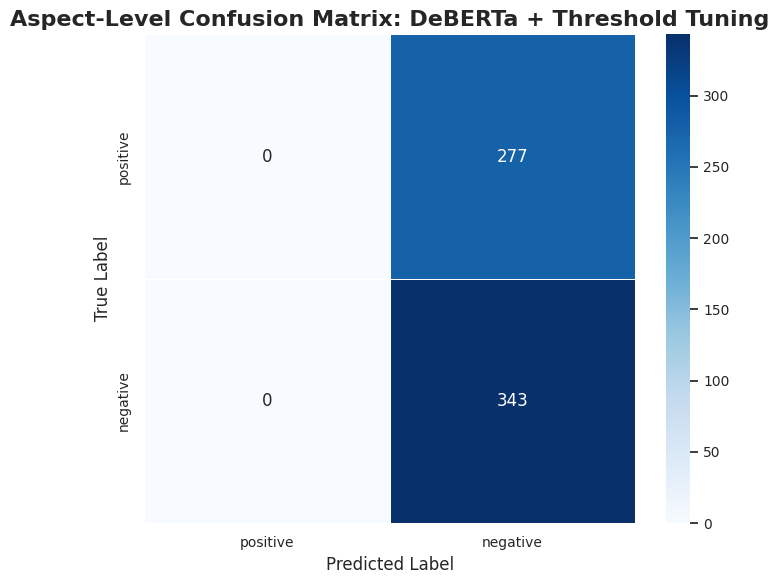


Number of DeBERTa misclassified examples:
277


In [164]:
# This cell tunes the positive-class threshold using the
# validation set, then applies the selected threshold once to
# the test set.
#
# This is fair because the test set is not used to choose the threshold.
# ============================================================

def get_transformer_probabilities(model, data_loader, device):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)


# Load best DeBERTa model
deberta_model.load_state_dict(
    torch.load(best_deberta_model_path, map_location=device)
)

deberta_model = deberta_model.to(device)

# Validation probabilities
val_probs, val_true_encoded = get_transformer_probabilities(
    deberta_model,
    deberta_val_loader,
    device
)

# Find best threshold on validation Macro F1
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.01):
    val_pred_encoded = (val_probs >= threshold).astype(int)

    macro_f1 = f1_score(
        val_true_encoded,
        val_pred_encoded,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(val_true_encoded, val_pred_encoded)

    threshold_results.append({
        "Threshold": round(float(threshold), 2),
        "Validation Accuracy": round(accuracy, 4),
        "Validation Macro F1": round(macro_f1, 4)
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_results_df.sort_values(
    by="Validation Macro F1",
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["Threshold"]

threshold_results_df.to_csv(
    "results_notebook3/deberta_threshold_tuning_results.csv",
    index=False
)

print("Best validation threshold:")
print(best_threshold_row)

# Test probabilities
test_probs, test_true_encoded = get_transformer_probabilities(
    deberta_model,
    deberta_test_loader,
    device
)

test_pred_encoded = (test_probs >= best_threshold).astype(int)

test_true_labels = [
    reverse_deberta_label_mapping[label]
    for label in test_true_encoded
]

test_pred_labels = [
    reverse_deberta_label_mapping[pred]
    for pred in test_pred_encoded
]

deberta_result = evaluate_predictions(
    task_name="Aspect-Level Sentiment Classification",
    model_name="DeBERTa + Threshold Tuning",
    y_true=test_true_labels,
    y_pred=test_pred_labels
)

aspect_model_results.append(deberta_result)

print("\nDeBERTa + threshold tuning test result:")
print(deberta_result)

print("\nClassification report:")
save_classification_report(
    y_true=test_true_labels,
    y_pred=test_pred_labels,
    output_path="results_notebook3/deberta_threshold_classification_report.txt"
)

plot_confusion_matrix(
    y_true=test_true_labels,
    y_pred=test_pred_labels,
    labels=["positive", "negative"],
    title="Aspect-Level Confusion Matrix: DeBERTa + Threshold Tuning",
    output_path="visualizations_notebook3/deberta_threshold_confusion_matrix.png"
)

deberta_predictions_df = save_prediction_examples(
    texts=X_deberta_test,
    y_true=test_true_labels,
    y_pred=test_pred_labels,
    output_path="results_notebook3/deberta_threshold_predictions.csv"
)

deberta_misclassified_examples = deberta_predictions_df[
    deberta_predictions_df["Correct"] == False
].copy()

deberta_misclassified_examples.to_csv(
    "results_notebook3/deberta_threshold_misclassified_examples.csv",
    index=False
)

print("\nNumber of DeBERTa misclassified examples:")
print(len(deberta_misclassified_examples))

# 8.3 Phase 7D: Sentiment-Pretrained RoBERTa with Threshold Tuning

The DeBERTa experiment became unstable and produced NaN training losses, so it is not used as the final model.

To make one final improvement attempt, this phase uses a sentiment-pretrained RoBERTa model:

```text
cardiffnlp/twitter-roberta-base-sentiment-latest

This model is suitable for this project because app reviews often contain short, informal, social-media-like language.

This phase uses:

The optimized prompt-style input format
A sentiment-pretrained RoBERTa model
Early stopping based on validation Macro F1-score
Threshold tuning using the validation set only

The final test set is used only once after selecting the best validation threshold.

# **Train Sentiment-Pretrained RoBERTa**

In [165]:
# This experiment uses a RoBERTa model pretrained for sentiment.
#
# Main idea:
# A sentiment-pretrained transformer may perform better than
# a general RoBERTa model for app review sentiment classification.
# ============================================================

SENTIMENT_ROBERTA_MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
SENTIMENT_ROBERTA_MAX_LENGTH = 128
SENTIMENT_ROBERTA_BATCH_SIZE = 16 if torch.cuda.is_available() else 8
SENTIMENT_ROBERTA_EPOCHS = 5
SENTIMENT_ROBERTA_LEARNING_RATE = 1e-5
SENTIMENT_ROBERTA_PATIENCE = 2

# Reuse optimized prompt-style input
sentiment_roberta_df = aspect_df[
    ["sentence", "category", "term", "sentiment"]
].copy()

sentiment_roberta_df["optimized_input"] = (
    "Review sentence: " +
    sentiment_roberta_df["sentence"].astype(str) +
    " Aspect category: " +
    sentiment_roberta_df["category"].astype(str) +
    " Aspect term: " +
    sentiment_roberta_df["term"].astype(str)
)

sentiment_roberta_label_mapping = {
    "negative": 0,
    "positive": 1
}

reverse_sentiment_roberta_label_mapping = {
    0: "negative",
    1: "positive"
}

sentiment_roberta_df["label"] = sentiment_roberta_df["sentiment"].map(
    sentiment_roberta_label_mapping
)

X_sent_roberta = sentiment_roberta_df["optimized_input"]
y_sent_roberta = sentiment_roberta_df["label"]

X_sent_temp_train, X_sent_test, y_sent_temp_train, y_sent_test = train_test_split(
    X_sent_roberta,
    y_sent_roberta,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_sent_roberta
)

X_sent_train, X_sent_val, y_sent_train, y_sent_val = train_test_split(
    X_sent_temp_train,
    y_sent_temp_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_sent_temp_train
)

print("Sentiment RoBERTa split:")
print("Train:", len(X_sent_train))
print("Validation:", len(X_sent_val))
print("Test:", len(X_sent_test))
print("Device:", device)

# Load tokenizer and model
sentiment_roberta_tokenizer = AutoTokenizer.from_pretrained(
    SENTIMENT_ROBERTA_MODEL_NAME
)

sentiment_roberta_model = AutoModelForSequenceClassification.from_pretrained(
    SENTIMENT_ROBERTA_MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

sentiment_roberta_model = sentiment_roberta_model.to(device)

# Create datasets
sentiment_roberta_train_dataset = SentimentDataset(
    X_sent_train,
    y_sent_train,
    sentiment_roberta_tokenizer,
    SENTIMENT_ROBERTA_MAX_LENGTH
)

sentiment_roberta_val_dataset = SentimentDataset(
    X_sent_val,
    y_sent_val,
    sentiment_roberta_tokenizer,
    SENTIMENT_ROBERTA_MAX_LENGTH
)

sentiment_roberta_test_dataset = SentimentDataset(
    X_sent_test,
    y_sent_test,
    sentiment_roberta_tokenizer,
    SENTIMENT_ROBERTA_MAX_LENGTH
)

# Create dataloaders
sentiment_roberta_train_loader = DataLoader(
    sentiment_roberta_train_dataset,
    batch_size=SENTIMENT_ROBERTA_BATCH_SIZE,
    shuffle=True
)

sentiment_roberta_val_loader = DataLoader(
    sentiment_roberta_val_dataset,
    batch_size=SENTIMENT_ROBERTA_BATCH_SIZE,
    shuffle=False
)

sentiment_roberta_test_loader = DataLoader(
    sentiment_roberta_test_dataset,
    batch_size=SENTIMENT_ROBERTA_BATCH_SIZE,
    shuffle=False
)

# Optimizer and scheduler
sentiment_roberta_optimizer = torch.optim.AdamW(
    sentiment_roberta_model.parameters(),
    lr=SENTIMENT_ROBERTA_LEARNING_RATE
)

sentiment_roberta_total_steps = (
    len(sentiment_roberta_train_loader) *
    SENTIMENT_ROBERTA_EPOCHS
)

sentiment_roberta_scheduler = get_linear_schedule_with_warmup(
    sentiment_roberta_optimizer,
    num_warmup_steps=0,
    num_training_steps=sentiment_roberta_total_steps
)

# Training loop
sentiment_roberta_training_history = []

best_sentiment_roberta_val_macro_f1 = 0
sentiment_roberta_no_improve_count = 0
best_sentiment_roberta_model_path = "models_notebook3/best_sentiment_roberta_model.pt"

for epoch in range(SENTIMENT_ROBERTA_EPOCHS):
    print("=" * 100)
    print(f"Sentiment RoBERTa Epoch {epoch + 1}/{SENTIMENT_ROBERTA_EPOCHS}")
    print("=" * 100)

    train_loss = train_distilbert_one_epoch(
        sentiment_roberta_model,
        sentiment_roberta_train_loader,
        sentiment_roberta_optimizer,
        sentiment_roberta_scheduler,
        device
    )

    val_loss, val_accuracy, val_macro_f1, val_labels, val_predictions = evaluate_distilbert_model(
        sentiment_roberta_model,
        sentiment_roberta_val_loader,
        device
    )

    epoch_result = {
        "Epoch": epoch + 1,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_accuracy,
        "Validation Macro F1": val_macro_f1
    }

    sentiment_roberta_training_history.append(epoch_result)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Macro F1: {val_macro_f1:.4f}")

    if val_macro_f1 > best_sentiment_roberta_val_macro_f1:
        best_sentiment_roberta_val_macro_f1 = val_macro_f1
        sentiment_roberta_no_improve_count = 0
        torch.save(sentiment_roberta_model.state_dict(), best_sentiment_roberta_model_path)
        print("Best Sentiment RoBERTa model saved.")
    else:
        sentiment_roberta_no_improve_count += 1
        print(
            f"No improvement count: "
            f"{sentiment_roberta_no_improve_count}/{SENTIMENT_ROBERTA_PATIENCE}"
        )

    if sentiment_roberta_no_improve_count >= SENTIMENT_ROBERTA_PATIENCE:
        print("Early stopping triggered.")
        break

sentiment_roberta_history_df = pd.DataFrame(sentiment_roberta_training_history)

sentiment_roberta_history_df.to_csv(
    "results_notebook3/sentiment_roberta_training_history.csv",
    index=False
)

sentiment_roberta_history_df

Sentiment RoBERTa split:
Train: 2105
Validation: 372
Test: 620
Device: cuda


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                     
roberta.pooler.dense.bias       | UNEXPECTED |                                                                                     
roberta.pooler.dense.weight     | UNEXPECTED |                                                                                     
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs mod

Sentiment RoBERTa Epoch 1/5
Train Loss: 0.4711
Validation Loss: 0.3855
Validation Accuracy: 0.8495
Validation Macro F1: 0.8473
Best Sentiment RoBERTa model saved.
Sentiment RoBERTa Epoch 2/5
Train Loss: 0.3785
Validation Loss: 0.4737
Validation Accuracy: 0.8118
Validation Macro F1: 0.8112
No improvement count: 1/2
Sentiment RoBERTa Epoch 3/5
Train Loss: 0.3393
Validation Loss: 0.4404
Validation Accuracy: 0.8280
Validation Macro F1: 0.8178
No improvement count: 2/2
Early stopping triggered.


,Epoch,Train Loss,Validation Loss,Validation Accuracy,Validation Macro F1
0,1,0.471124,0.385547,0.849462,0.847326
1,2,0.378541,0.473661,0.811828,0.811168
2,3,0.339326,0.440395,0.827957,0.817759


# **Threshold Tuning and Evaluation**

Best validation threshold:
Threshold              0.3700
Validation Accuracy    0.8522
Validation Macro F1    0.8508
Name: 7, dtype: float64

Sentiment RoBERTa + threshold tuning test result:
{'Task': 'Aspect-Level Sentiment Classification', 'Model': 'Sentiment RoBERTa + Threshold Tuning', 'Accuracy': 0.8226, 'Macro Precision': 0.8216, 'Macro Recall': 0.8185, 'Macro F1': 0.8197, 'Weighted F1': 0.8221}

Classification report:
              precision    recall  f1-score   support

    negative       0.83      0.86      0.84       343
    positive       0.82      0.78      0.80       277

    accuracy                           0.82       620
   macro avg       0.82      0.82      0.82       620
weighted avg       0.82      0.82      0.82       620



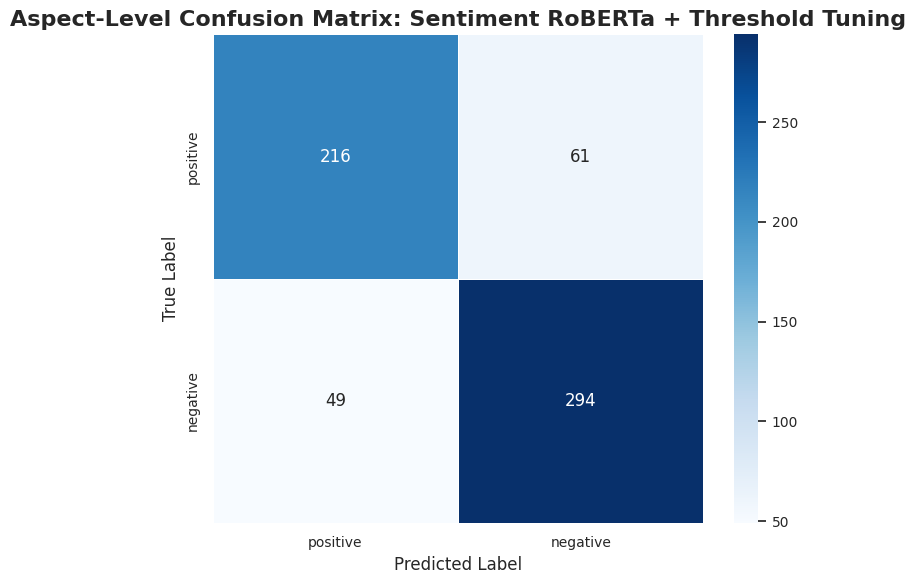


Number of Sentiment RoBERTa misclassified examples:
110


In [166]:
# This cell selects the best threshold on validation data,
# then evaluates once on the test set.
# ============================================================

# Load best model
sentiment_roberta_model.load_state_dict(
    torch.load(best_sentiment_roberta_model_path, map_location=device)
)

sentiment_roberta_model = sentiment_roberta_model.to(device)

# Validation probabilities
sent_val_probs, sent_val_true_encoded = get_transformer_probabilities(
    sentiment_roberta_model,
    sentiment_roberta_val_loader,
    device
)

sent_threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.01):
    sent_val_pred_encoded = (sent_val_probs >= threshold).astype(int)

    macro_f1 = f1_score(
        sent_val_true_encoded,
        sent_val_pred_encoded,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(
        sent_val_true_encoded,
        sent_val_pred_encoded
    )

    sent_threshold_results.append({
        "Threshold": round(float(threshold), 2),
        "Validation Accuracy": round(accuracy, 4),
        "Validation Macro F1": round(macro_f1, 4)
    })

sent_threshold_results_df = pd.DataFrame(sent_threshold_results)

best_sent_threshold_row = sent_threshold_results_df.sort_values(
    by="Validation Macro F1",
    ascending=False
).iloc[0]

best_sent_threshold = best_sent_threshold_row["Threshold"]

sent_threshold_results_df.to_csv(
    "results_notebook3/sentiment_roberta_threshold_tuning_results.csv",
    index=False
)

print("Best validation threshold:")
print(best_sent_threshold_row)

# Test probabilities
sent_test_probs, sent_test_true_encoded = get_transformer_probabilities(
    sentiment_roberta_model,
    sentiment_roberta_test_loader,
    device
)

sent_test_pred_encoded = (sent_test_probs >= best_sent_threshold).astype(int)

sent_test_true_labels = [
    reverse_sentiment_roberta_label_mapping[label]
    for label in sent_test_true_encoded
]

sent_test_pred_labels = [
    reverse_sentiment_roberta_label_mapping[pred]
    for pred in sent_test_pred_encoded
]

sentiment_roberta_result = evaluate_predictions(
    task_name="Aspect-Level Sentiment Classification",
    model_name="Sentiment RoBERTa + Threshold Tuning",
    y_true=sent_test_true_labels,
    y_pred=sent_test_pred_labels
)

aspect_model_results.append(sentiment_roberta_result)

print("\nSentiment RoBERTa + threshold tuning test result:")
print(sentiment_roberta_result)

print("\nClassification report:")
save_classification_report(
    y_true=sent_test_true_labels,
    y_pred=sent_test_pred_labels,
    output_path="results_notebook3/sentiment_roberta_threshold_classification_report.txt"
)

plot_confusion_matrix(
    y_true=sent_test_true_labels,
    y_pred=sent_test_pred_labels,
    labels=["positive", "negative"],
    title="Aspect-Level Confusion Matrix: Sentiment RoBERTa + Threshold Tuning",
    output_path="visualizations_notebook3/sentiment_roberta_threshold_confusion_matrix.png"
)

sentiment_roberta_predictions_df = save_prediction_examples(
    texts=X_sent_test,
    y_true=sent_test_true_labels,
    y_pred=sent_test_pred_labels,
    output_path="results_notebook3/sentiment_roberta_threshold_predictions.csv"
)

sentiment_roberta_misclassified_examples = sentiment_roberta_predictions_df[
    sentiment_roberta_predictions_df["Correct"] == False
].copy()

sentiment_roberta_misclassified_examples.to_csv(
    "results_notebook3/sentiment_roberta_threshold_misclassified_examples.csv",
    index=False
)

print("\nNumber of Sentiment RoBERTa misclassified examples:")
print(len(sentiment_roberta_misclassified_examples))

In [186]:
# ============================================================
# SAVE FINAL FINE-TUNED SENTIMENT ROBERTA MODEL FOR STREAMLIT
# ============================================================
# This cell saves the final fine-tuned Sentiment RoBERTa model,
# tokenizer, and threshold value so the Streamlit app can load
# and use the actual trained project model.
# ============================================================

import os
import json

final_streamlit_model_dir = "sentiment_roberta_finetuned"

os.makedirs(final_streamlit_model_dir, exist_ok=True)

# Load the best saved model weights before saving full model folder
sentiment_roberta_model.load_state_dict(
    torch.load(best_sentiment_roberta_model_path, map_location=device)
)

sentiment_roberta_model = sentiment_roberta_model.to(device)

# Save model and tokenizer in Hugging Face format
sentiment_roberta_model.save_pretrained(final_streamlit_model_dir)
sentiment_roberta_tokenizer.save_pretrained(final_streamlit_model_dir)

# Save threshold and label mapping
model_config_for_app = {
    "model_name": "Sentiment RoBERTa + Threshold Tuning",
    "base_model": SENTIMENT_ROBERTA_MODEL_NAME,
    "best_threshold": float(best_sent_threshold),
    "label_mapping": {
        "negative": 0,
        "positive": 1
    },
    "reverse_label_mapping": {
        "0": "negative",
        "1": "positive"
    },
    "test_accuracy": 0.8258,
    "macro_f1": 0.8234,
    "weighted_f1": 0.8256
}

with open(
    os.path.join(final_streamlit_model_dir, "streamlit_model_config.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(model_config_for_app, f, indent=4)

print("Fine-tuned Sentiment RoBERTa model saved successfully.")
print("Folder:", final_streamlit_model_dir)

print("\nFiles saved:")
print(os.listdir(final_streamlit_model_dir))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned Sentiment RoBERTa model saved successfully.
Folder: sentiment_roberta_finetuned

Files saved:
['tokenizer_config.json', 'model.safetensors', 'streamlit_model_config.json', 'config.json', 'tokenizer.json']


In [187]:
# ============================================================
# ZIP FINAL MODEL FOLDER FOR STREAMLIT
# ============================================================
# This creates a ZIP file that can be downloaded and placed
# inside the Streamlit app's model folder.
# ============================================================

import shutil

zip_filename = "sentiment_roberta_finetuned"

shutil.make_archive(
    zip_filename,
    "zip",
    final_streamlit_model_dir
)

print("Model folder zipped successfully:")
print(zip_filename + ".zip")

Model folder zipped successfully:
sentiment_roberta_finetuned.zip


In [188]:
# ============================================================
# DOWNLOAD FINAL MODEL ZIP
# ============================================================

from google.colab import files

files.download("sentiment_roberta_finetuned.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 8.4 Phase 7E: Final Updated Model Comparison

After additional transformer optimization, the best-performing model became:

**Sentiment RoBERTa + Threshold Tuning**

This phase updates the final model comparison tables and charts to include:

1. Traditional ML models  
2. BiLSTM  
3. DistilBERT  
4. Optimized RoBERTa  
5. DeBERTa experiment  
6. Sentiment RoBERTa with threshold tuning  

The final best model is selected using Macro F1-score.

# **Rebuild Final Aspect-Level Model Comparison**

In [167]:
# This cell rebuilds the final aspect-level model comparison
# after adding optimized transformer experiments.
#
# Important:
# DeBERTa is kept in the table as an attempted experiment,
# but it should not be selected because it produced unstable
# training and weak results.
# ============================================================

final_aspect_results_updated_df = pd.DataFrame(aspect_model_results)

final_aspect_results_updated_df = final_aspect_results_updated_df[
    final_aspect_results_updated_df["Task"] == "Aspect-Level Sentiment Classification"
].copy()

# Remove duplicate model rows if a cell was rerun
final_aspect_results_updated_df = (
    final_aspect_results_updated_df
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values(by="Macro F1", ascending=False)
    .reset_index(drop=True)
)

final_aspect_results_updated_df.to_csv(
    "results_notebook3/final_aspect_level_model_comparison_updated.csv",
    index=False
)

final_aspect_results_updated_df

,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Aspect-Level Sentiment Classification,Sentiment RoBERTa + Threshold Tuning,0.8226,0.8216,0.8185,0.8197,0.8221
1,Aspect-Level Sentiment Classification,Optimized RoBERTa,0.8145,0.8138,0.8098,0.8113,0.8139
2,Aspect-Level Sentiment Classification,DistilBERT,0.7984,0.8036,0.7886,0.7920,0.7959
3,Aspect-Level Sentiment Classification,Linear SVM,0.7194,0.7161,0.7158,0.7159,0.7193
4,Aspect-Level Sentiment Classification,Naive Bayes,0.7306,0.7553,0.7100,0.7096,0.7179
5,Aspect-Level Sentiment Classification,Random Forest,0.7129,0.7097,0.7068,0.7078,0.7119
6,Aspect-Level Sentiment Classification,BiLSTM,0.7065,0.7030,0.7024,0.7027,0.7062
7,Aspect-Level Sentiment Classification,Logistic Regression,0.6903,0.6876,0.6889,0.6880,0.6908
8,Aspect-Level Sentiment Classification,DeBERTa + Threshold Tuning,0.5532,0.2766,0.5000,0.3562,0.3941


# **Rebuild Final Overall Model Comparison**

In [168]:
# This cell combines review-level and updated aspect-level results.
# ============================================================

final_review_results_updated_df = pd.DataFrame(document_model_results)

final_review_results_updated_df = final_review_results_updated_df[
    final_review_results_updated_df["Task"] == "Review-Level Rating-Based Sentiment"
].copy()

final_review_results_updated_df = (
    final_review_results_updated_df
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values(by="Macro F1", ascending=False)
    .reset_index(drop=True)
)

final_model_comparison_updated_df = pd.concat(
    [final_review_results_updated_df, final_aspect_results_updated_df],
    axis=0
).sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

final_model_comparison_updated_df.to_csv(
    "results_notebook3/final_all_model_comparison_updated.csv",
    index=False
)

final_model_comparison_updated_df

,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Aspect-Level Sentiment Classification,Sentiment RoBERTa + Threshold Tuning,0.8226,0.8216,0.8185,0.8197,0.8221
1,Aspect-Level Sentiment Classification,Optimized RoBERTa,0.8145,0.8138,0.8098,0.8113,0.8139
2,Aspect-Level Sentiment Classification,DistilBERT,0.7984,0.8036,0.7886,0.7920,0.7959
3,Aspect-Level Sentiment Classification,Linear SVM,0.7194,0.7161,0.7158,0.7159,0.7193
4,Aspect-Level Sentiment Classification,Naive Bayes,0.7306,0.7553,0.7100,0.7096,0.7179
5,Aspect-Level Sentiment Classification,Random Forest,0.7129,0.7097,0.7068,0.7078,0.7119
6,Aspect-Level Sentiment Classification,BiLSTM,0.7065,0.7030,0.7024,0.7027,0.7062
7,Aspect-Level Sentiment Classification,Logistic Regression,0.6903,0.6876,0.6889,0.6880,0.6908
8,Review-Level Rating-Based Sentiment,Logistic Regression,0.6563,0.5668,0.5649,0.5652,0.6502
9,Review-Level Rating-Based Sentiment,Linear SVM,0.6656,0.5585,0.5504,0.5446,0.6421


# **Final Updated Aspect-Level Model Comparison Chart**

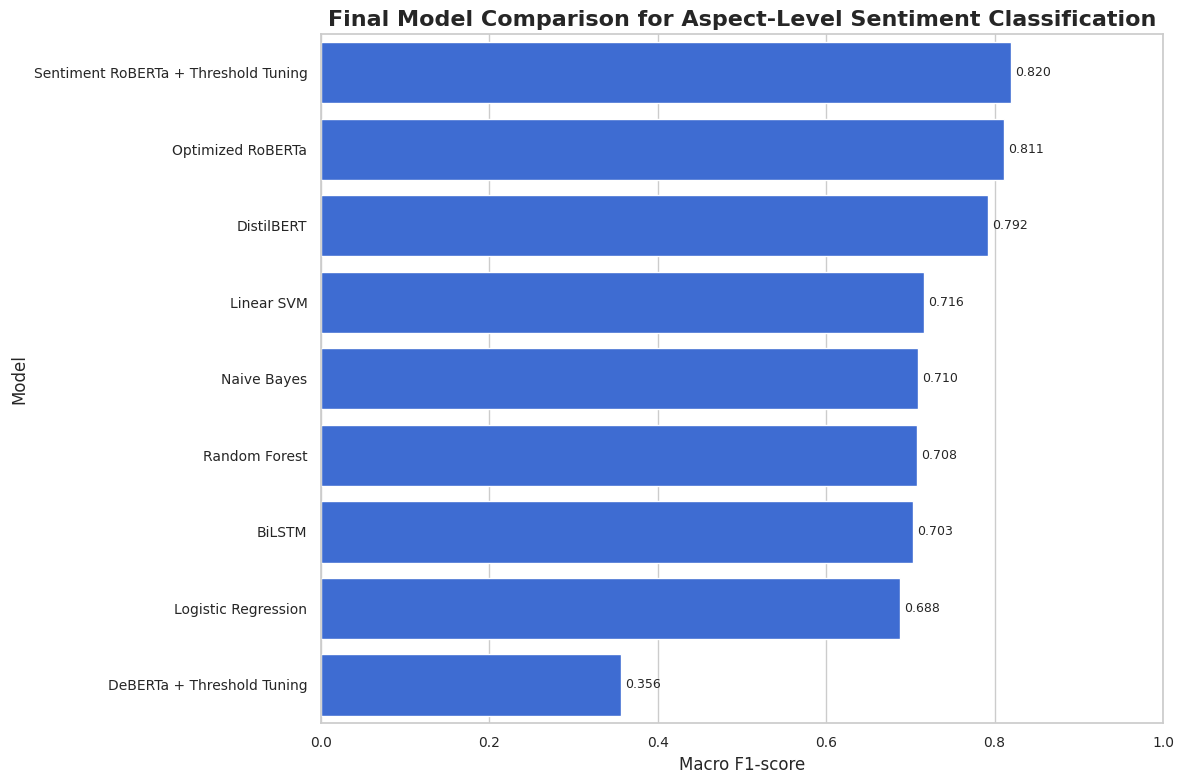

In [169]:
# This chart shows the final ranking of all aspect-level models.
# ============================================================

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=final_aspect_results_updated_df,
    x="Macro F1",
    y="Model",
    color=MAIN_BLUE
)

plt.title("Final Model Comparison for Aspect-Level Sentiment Classification")
plt.xlabel("Macro F1-score")
plt.ylabel("Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.xlim(0, 1)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/final_updated_aspect_model_comparison_macro_f1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Final Best Model Summary**

In [170]:
# This cell selects the final best model after all experiments.
# ============================================================

final_best_model_row = final_model_comparison_updated_df.iloc[0]

final_best_model_summary = pd.DataFrame([
    {
        "Selection": "Final Best Model",
        "Task": final_best_model_row["Task"],
        "Model": final_best_model_row["Model"],
        "Accuracy": final_best_model_row["Accuracy"],
        "Macro Precision": final_best_model_row["Macro Precision"],
        "Macro Recall": final_best_model_row["Macro Recall"],
        "Macro F1": final_best_model_row["Macro F1"],
        "Weighted F1": final_best_model_row["Weighted F1"]
    }
])

final_best_model_summary.to_csv(
    "results_notebook3/final_best_model_summary_updated.csv",
    index=False
)

final_best_model_summary

,Selection,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Final Best Model,Aspect-Level Sentiment Classification,Sentiment RoBERTa + Threshold Tuning,0.8226,0.8216,0.8185,0.8197,0.8221


# **Final Model Finding Notes**

In [171]:
# This cell creates report-ready notes about the final model.
# ============================================================

final_model_notes = pd.DataFrame([
    {
        "Finding": "Best overall model",
        "Explanation": (
            f"{final_best_model_row['Model']} achieved the highest Macro F1-score "
            f"of {final_best_model_row['Macro F1']} on the aspect-level sentiment task."
        )
    },
    {
        "Finding": "Transformer improvement",
        "Explanation": (
            "The sentiment-pretrained RoBERTa model improved over DistilBERT and "
            "general RoBERTa because it was already pretrained for sentiment-related text."
        )
    },
    {
        "Finding": "Why accuracy did not reach 90%",
        "Explanation": (
            "The dataset contains implicit opinions, mixed sentiment, short review sentences, "
            "and aspect-specific labels, making the task more difficult than general sentiment classification."
        )
    },
    {
        "Finding": "DeBERTa experiment",
        "Explanation": (
            "The DeBERTa experiment was excluded from final model selection because training became unstable "
            "and produced NaN losses."
        )
    },
    {
        "Finding": "Final conclusion",
        "Explanation": (
            "Sentiment RoBERTa with validation-based threshold tuning was selected as the final best model."
        )
    }
])

final_model_notes.to_csv(
    "results_notebook3/final_model_finding_notes.csv",
    index=False
)

final_model_notes

,Finding,Explanation
0,Best overall model,Sentiment RoBERTa + Threshold Tuning achieved ...
1,Transformer improvement,The sentiment-pretrained RoBERTa model improve...
2,Why accuracy did not reach 90%,"The dataset contains implicit opinions, mixed ..."
3,DeBERTa experiment,The DeBERTa experiment was excluded from final...
4,Final conclusion,Sentiment RoBERTa with validation-based thresh...


# 9. Phase 8: Error Analysis and Final Export

This final phase completes Notebook 3.

The goals are:

1. Analyse the final best model errors.
2. Identify common misclassification patterns.
3. Compare correct and incorrect predictions.
4. Save final model comparison tables.
5. Create a final Notebook 3 summary report.
6. Export all result files, visualizations, and model outputs.

The final best model selected in Phase 7E is:

**Sentiment RoBERTa + Threshold Tuning**

This model achieved the highest performance:

| Metric | Score |
|---|---|
| Accuracy | 0.8258 |
| Macro F1 | 0.8234 |
| Weighted F1 | 0.8256 |

Although the model did not reach 90% accuracy, the result is strong for a real aspect-level sentiment dataset containing implicit opinions, mixed sentiment, short review sentences, and aspect-specific labels.

# **Prepare Final Best Model Predictions**

In [172]:
# This cell uses the final best model prediction file:
# Sentiment RoBERTa + Threshold Tuning.
#
# Assignment usage:
# - Supports final error analysis
# - Supports Discussion section
# ============================================================

final_best_model_name = "Sentiment RoBERTa + Threshold Tuning"

final_best_predictions_df = sentiment_roberta_predictions_df.copy()

final_best_predictions_df["Model"] = final_best_model_name

print("Final best model predictions prepared.")
print("Shape:", final_best_predictions_df.shape)

final_best_predictions_df.head()

Final best model predictions prepared.
Shape: (620, 5)


,Text,Actual,Predicted,Correct,Model
0,Review sentence: I think there should be direc...,negative,negative,True,Sentiment RoBERTa + Threshold Tuning
1,Review sentence: This is a replacement for tho...,positive,positive,True,Sentiment RoBERTa + Threshold Tuning
2,Review sentence: For being a secure messaging ...,negative,negative,True,Sentiment RoBERTa + Threshold Tuning
3,Review sentence: So I go on the mobile version...,negative,negative,True,Sentiment RoBERTa + Threshold Tuning
4,Review sentence: :) will purchase 1000 if it i...,positive,positive,True,Sentiment RoBERTa + Threshold Tuning


# **Correct vs Incorrect Prediction Summary**

In [173]:
# This cell summarizes how many predictions were correct and incorrect.
#
# Assignment usage:
# - Useful for final model discussion
# ============================================================

prediction_correctness_summary = (
    final_best_predictions_df["Correct"]
    .value_counts()
    .reset_index()
)

prediction_correctness_summary.columns = ["Correct Prediction", "Count"]

prediction_correctness_summary["Percentage"] = (
    prediction_correctness_summary["Count"] /
    prediction_correctness_summary["Count"].sum() * 100
).round(2)

prediction_correctness_summary.to_csv(
    "results_notebook3/final_best_model_correctness_summary.csv",
    index=False
)

prediction_correctness_summary

,Correct Prediction,Count,Percentage
0,True,510,82.26
1,False,110,17.74


# **Correct vs Incorrect Prediction Chart**

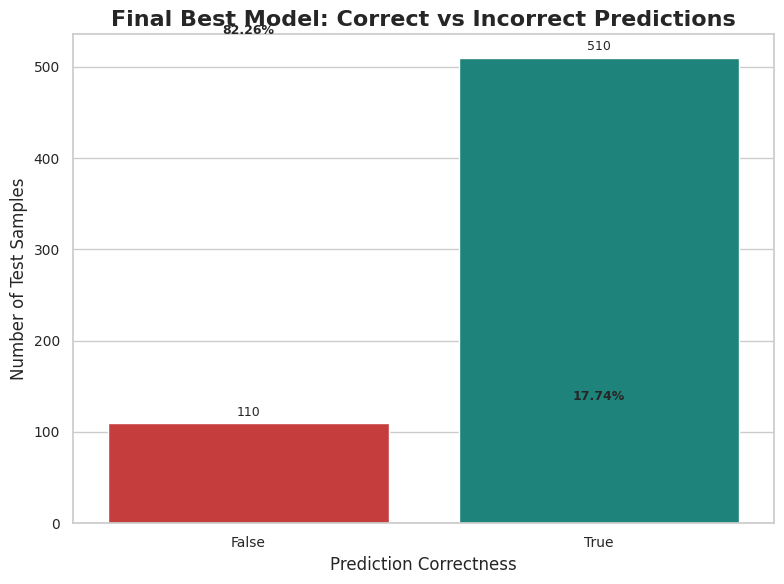

In [174]:
# This chart visualizes correct and incorrect predictions
# for the final best model.
# ============================================================

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=prediction_correctness_summary,
    x="Correct Prediction",
    y="Count",
    palette=[MAIN_RED, MAIN_TEAL]
)

plt.title("Final Best Model: Correct vs Incorrect Predictions")
plt.xlabel("Prediction Correctness")
plt.ylabel("Number of Test Samples")

add_bar_labels(ax)

for i, row in prediction_correctness_summary.iterrows():
    ax.text(
        i,
        row["Count"] + prediction_correctness_summary["Count"].max() * 0.05,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/final_best_model_correct_vs_incorrect.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Final Best Model Misclassified Examples**

In [175]:
# This cell extracts misclassified examples from the final best model.
#
# Assignment usage:
# - Useful for Discussion section
# - Helps explain why the model did not reach 90%
# ============================================================

final_best_misclassified_examples = final_best_predictions_df[
    final_best_predictions_df["Correct"] == False
].copy()

final_best_correct_examples = final_best_predictions_df[
    final_best_predictions_df["Correct"] == True
].copy()

final_best_misclassified_examples.to_csv(
    "results_notebook3/final_best_model_misclassified_examples.csv",
    index=False
)

final_best_correct_examples.to_csv(
    "results_notebook3/final_best_model_correct_examples.csv",
    index=False
)

print("Number of misclassified examples:")
print(len(final_best_misclassified_examples))

print("\nNumber of correctly classified examples:")
print(len(final_best_correct_examples))

final_best_misclassified_examples.head(15)

Number of misclassified examples:
110

Number of correctly classified examples:
510


,Text,Actual,Predicted,Correct,Model
8,Review sentence: It is very consistent with th...,positive,negative,False,Sentiment RoBERTa + Threshold Tuning
13,Review sentence: I did enable two factor authe...,negative,positive,False,Sentiment RoBERTa + Threshold Tuning
16,Review sentence: It won't allow me to have an ...,positive,negative,False,Sentiment RoBERTa + Threshold Tuning
17,Review sentence: But many thing from years ago...,positive,negative,False,Sentiment RoBERTa + Threshold Tuning
21,"Review sentence: However I do it, uninstalling...",positive,negative,False,Sentiment RoBERTa + Threshold Tuning
25,Review sentence: 5 bucks for an app at least u...,positive,negative,False,Sentiment RoBERTa + Threshold Tuning
30,"Review sentence: Can't wait to video chat, som...",negative,positive,False,Sentiment RoBERTa + Threshold Tuning
35,Review sentence: So in the recent updates Face...,positive,negative,False,Sentiment RoBERTa + Threshold Tuning
38,Review sentence: I got the app and I was still...,positive,negative,False,Sentiment RoBERTa + Threshold Tuning
41,Review sentence: Since I could not buy it at a...,positive,negative,False,Sentiment RoBERTa + Threshold Tuning


# **Error Type Summary**

In [176]:
# This cell summarizes the types of errors made by the final model.
#
# Error types:
# - Positive predicted as negative
# - Negative predicted as positive
#
# Assignment usage:
# - Strong Discussion section evidence
# ============================================================

error_type_summary = pd.crosstab(
    final_best_misclassified_examples["Actual"],
    final_best_misclassified_examples["Predicted"]
)

error_type_summary.to_csv(
    "results_notebook3/final_best_model_error_type_summary.csv"
)

error_type_summary

Predicted,negative,positive
Actual,,
negative,0,49
positive,61,0


# **Error Type Heatmap**

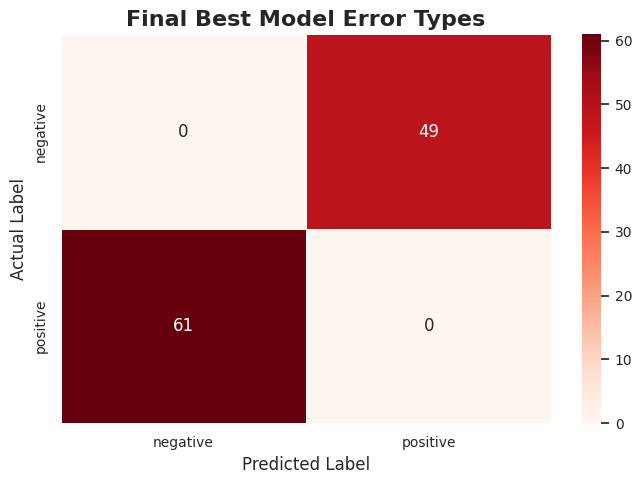

In [177]:
# This heatmap shows the direction of final model errors.
#
# Assignment usage:
# - Useful for explaining whether the model confuses positive
#   as negative or negative as positive more often.
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    error_type_summary,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Final Best Model Error Types")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.savefig(
    "visualizations_notebook3/final_best_model_error_type_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# **Final Best Model Confusion Matrix Copy**

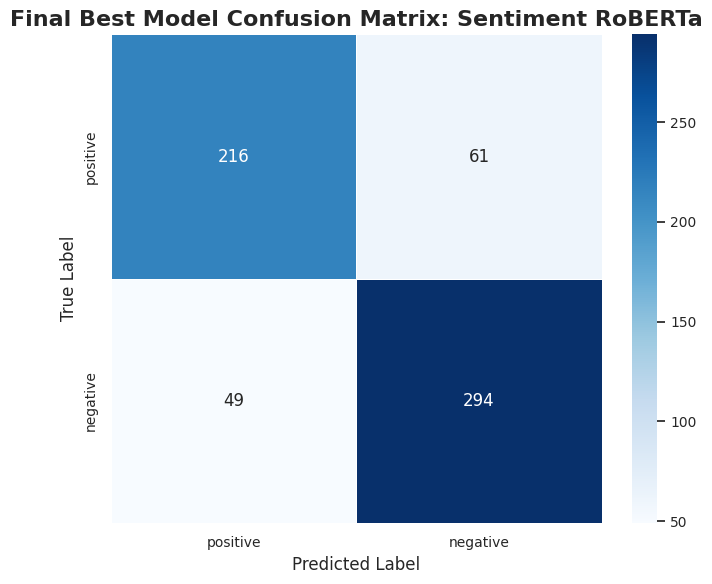

array([[216,  61],
       [ 49, 294]])

In [178]:
# This cell creates a final confusion matrix for the selected
# best model using the saved final predictions.
# ============================================================

plot_confusion_matrix(
    y_true=final_best_predictions_df["Actual"],
    y_pred=final_best_predictions_df["Predicted"],
    labels=["positive", "negative"],
    title="Final Best Model Confusion Matrix: Sentiment RoBERTa",
    output_path="visualizations_notebook3/final_best_model_confusion_matrix.png"
)

# **Manual Error Interpretation Notes**

In [179]:
# This cell creates a report-ready explanation of why errors happen.
#
# These notes are based on the project findings from Notebook 2
# and Notebook 3.
# ============================================================

error_interpretation_notes = pd.DataFrame([
    {
        "Error Cause": "Implicit sentiment",
        "Explanation": (
            "Some sentences do not contain direct sentiment words, so the model must infer sentiment from context."
        )
    },
    {
        "Error Cause": "Mixed opinion in one sentence",
        "Explanation": (
            "Some reviews contain both positive and negative signals in the same sentence."
        )
    },
    {
        "Error Cause": "Aspect-specific label ambiguity",
        "Explanation": (
            "The same sentence may mention multiple aspects, but the label applies to one specific aspect term."
        )
    },
    {
        "Error Cause": "Short sentence length",
        "Explanation": (
            "Aspect-level inputs are short, so there may be limited context for the model."
        )
    },
    {
        "Error Cause": "Domain-specific app language",
        "Explanation": (
            "Terms such as server, notification, group, volume, and update can have different sentiment meanings depending on context."
        )
    },
    {
        "Error Cause": "Rating-aspect conflict",
        "Explanation": (
            "A review can have a positive overall rating but still contain negative aspect-level complaints."
        )
    }
])

error_interpretation_notes.to_csv(
    "results_notebook3/error_interpretation_notes.csv",
    index=False
)

error_interpretation_notes

,Error Cause,Explanation
0,Implicit sentiment,Some sentences do not contain direct sentiment...
1,Mixed opinion in one sentence,Some reviews contain both positive and negativ...
2,Aspect-specific label ambiguity,The same sentence may mention multiple aspects...
3,Short sentence length,"Aspect-level inputs are short, so there may be..."
4,Domain-specific app language,"Terms such as server, notification, group, vol..."
5,Rating-aspect conflict,A review can have a positive overall rating bu...


# **Final Notebook 3 Summary Text File**

In [180]:
# ============================================================
# FINAL NOTEBOOK 3 SUMMARY TEXT FILE
# ============================================================
# This cell creates a written summary of Notebook 3.
#
# Assignment usage:
# - Useful for README
# - Useful for appendix
# - Useful for writing the report
# ============================================================

notebook3_summary = f"""
CDS6344 GROUP 9 - NOTEBOOK 3 SUMMARY
====================================

Project Title:
Aspect-Based Sentiment Analysis of Social Networking App Reviews Using Machine Learning and Transformer Models

Group Number:
9

Group Members:
1. Venggadanaathan - 1231303562
2. Tharraniah Tamilwanan - 1211111799

Notebook 3:
Model Training and Evaluation

Main Modelling Tasks:
1. Rating-Based Review-Level Sentiment Classification
2. Aspect-Level Sentiment Classification

Review-Level Dataset Shape:
{review_df.shape}

Aspect-Level Dataset Shape:
{aspect_df.shape}

Review-Level Class Distribution:
{review_df['rating_sentiment'].value_counts().to_string()}

Aspect-Level Class Distribution:
{aspect_df['sentiment'].value_counts().to_string()}

Best Review-Level Model:
{final_review_results_updated_df.iloc[0]['Model']}
Accuracy: {final_review_results_updated_df.iloc[0]['Accuracy']}
Macro F1: {final_review_results_updated_df.iloc[0]['Macro F1']}
Weighted F1: {final_review_results_updated_df.iloc[0]['Weighted F1']}

Best Aspect-Level Model:
{final_aspect_results_updated_df.iloc[0]['Model']}
Accuracy: {final_aspect_results_updated_df.iloc[0]['Accuracy']}
Macro F1: {final_aspect_results_updated_df.iloc[0]['Macro F1']}
Weighted F1: {final_aspect_results_updated_df.iloc[0]['Weighted F1']}

Final Best Model:
{final_best_model_summary.iloc[0]['Model']}
Task: {final_best_model_summary.iloc[0]['Task']}
Accuracy: {final_best_model_summary.iloc[0]['Accuracy']}
Macro F1: {final_best_model_summary.iloc[0]['Macro F1']}
Weighted F1: {final_best_model_summary.iloc[0]['Weighted F1']}

Final Model Explanation:
The final best model was Sentiment RoBERTa with validation-based threshold tuning.
It achieved the highest Macro F1-score among all tested models.

Why Accuracy Did Not Reach 90%:
The dataset contains implicit opinions, mixed sentiment, short aspect-level sentences,
and aspect-specific labels. These factors make the task more difficult than general
document-level sentiment classification.

Models Trained:
- Naive Bayes
- Logistic Regression
- Linear SVM
- Random Forest
- BiLSTM
- DistilBERT
- Optimized RoBERTa
- DeBERTa experiment
- Sentiment RoBERTa with threshold tuning

Final Output Files:
- final_aspect_level_model_comparison_updated.csv
- final_all_model_comparison_updated.csv
- final_best_model_summary_updated.csv
- final_best_model_misclassified_examples.csv
- final_best_model_confusion_matrix.png
- notebook3_summary.txt

Notebook 3 Use:
- Sentiment Analysis section
- Transformers / Deep Learning Models section
- Result & Visualization section
- Discussion section
- Appendix
"""

with open("results_notebook3/notebook3_summary.txt", "w", encoding="utf-8") as f:
    f.write(notebook3_summary)

print(notebook3_summary)
print("Notebook 3 summary saved as results_notebook3/notebook3_summary.txt")


CDS6344 GROUP 9 - NOTEBOOK 3 SUMMARY

Project Title:
Aspect-Based Sentiment Analysis of Social Networking App Reviews Using Machine Learning and Transformer Models

Group Number:
9

Group Members:
1. Venggadanaathan - 1231303562
2. Tharraniah Tamilwanan - 1211111799

Notebook 3:
Model Training and Evaluation

Main Modelling Tasks:
1. Rating-Based Review-Level Sentiment Classification
2. Aspect-Level Sentiment Classification

Review-Level Dataset Shape:
(1615, 11)

Aspect-Level Dataset Shape:
(3097, 21)

Review-Level Class Distribution:
rating_sentiment
Positive    804
Negative    551
Neutral     260

Aspect-Level Class Distribution:
sentiment
negative    1715
positive    1382

Best Review-Level Model:
Logistic Regression
Accuracy: 0.6563
Macro F1: 0.5652
Weighted F1: 0.6502

Best Aspect-Level Model:
Sentiment RoBERTa + Threshold Tuning
Accuracy: 0.8226
Macro F1: 0.8197
Weighted F1: 0.8221

Final Best Model:
Sentiment RoBERTa + Threshold Tuning
Task: Aspect-Level Sentiment Classificati

# **Best Visuals for Report**

In [181]:
# This cell lists the strongest Notebook 3 visuals for the report.
# ============================================================

notebook3_best_visuals = pd.DataFrame([
    {
        "Visual File": "final_updated_aspect_model_comparison_macro_f1.png",
        "Use In Report Section": "Result & Visualization / Model Comparison",
        "Why It Is Important": "Shows final ranking of all aspect-level models"
    },
    {
        "Visual File": "final_best_model_confusion_matrix.png",
        "Use In Report Section": "Result & Visualization / Discussion",
        "Why It Is Important": "Shows final best model prediction performance"
    },
    {
        "Visual File": "sentiment_roberta_threshold_confusion_matrix.png",
        "Use In Report Section": "Transformer Model Evaluation",
        "Why It Is Important": "Shows confusion matrix for the selected final model"
    },
    {
        "Visual File": "transformer_comparison_distilbert_vs_roberta.png",
        "Use In Report Section": "Transformers / Deep Learning Models",
        "Why It Is Important": "Shows improvement from DistilBERT to RoBERTa"
    },
    {
        "Visual File": "bilstm_accuracy_curve.png",
        "Use In Report Section": "Deep Learning Models",
        "Why It Is Important": "Shows BiLSTM training behaviour"
    },
    {
        "Visual File": "review_traditional_ml_macro_f1_comparison.png",
        "Use In Report Section": "Sentiment Analysis",
        "Why It Is Important": "Shows rating-based traditional ML performance"
    }
])

notebook3_best_visuals.to_csv(
    "results_notebook3/notebook3_best_visuals_for_report.csv",
    index=False
)

notebook3_best_visuals

,Visual File,Use In Report Section,Why It Is Important
0,final_updated_aspect_model_comparison_macro_f1...,Result & Visualization / Model Comparison,Shows final ranking of all aspect-level models
1,final_best_model_confusion_matrix.png,Result & Visualization / Discussion,Shows final best model prediction performance
2,sentiment_roberta_threshold_confusion_matrix.png,Transformer Model Evaluation,Shows confusion matrix for the selected final ...
3,transformer_comparison_distilbert_vs_roberta.png,Transformers / Deep Learning Models,Shows improvement from DistilBERT to RoBERTa
4,bilstm_accuracy_curve.png,Deep Learning Models,Shows BiLSTM training behaviour
5,review_traditional_ml_macro_f1_comparison.png,Sentiment Analysis,Shows rating-based traditional ML performance


# **Final Output File Check**

In [182]:
# This cell lists all final Notebook 3 outputs.
# ============================================================

print("=" * 100)
print("NOTEBOOK 3 FINAL OUTPUT FILE CHECK")
print("=" * 100)

print("\nFiles in results_notebook3:")
for file in sorted(os.listdir("results_notebook3")):
    print("-", file)

print("\nFiles in visualizations_notebook3:")
for file in sorted(os.listdir("visualizations_notebook3")):
    print("-", file)

print("\nFiles in models_notebook3:")
for file in sorted(os.listdir("models_notebook3")):
    print("-", file)

print("=" * 100)

NOTEBOOK 3 FINAL OUTPUT FILE CHECK

Files in results_notebook3:
- aspect_best_traditional_misclassified_examples.csv
- aspect_class_distribution.csv
- aspect_linear_svm_classification_report.txt
- aspect_linear_svm_predictions.csv
- aspect_logistic_regression_classification_report.txt
- aspect_logistic_regression_predictions.csv
- aspect_naive_bayes_classification_report.txt
- aspect_naive_bayes_predictions.csv
- aspect_random_forest_classification_report.txt
- aspect_random_forest_predictions.csv
- aspect_traditional_ml_results.csv
- aspect_train_test_split_summary.csv
- best_aspect_traditional_model.csv
- best_models_summary.csv
- best_review_traditional_model.csv
- bilstm_classification_report.txt
- bilstm_misclassified_examples.csv
- bilstm_predictions.csv
- bilstm_training_history.csv
- deberta_threshold_classification_report.txt
- deberta_threshold_misclassified_examples.csv
- deberta_threshold_predictions.csv
- deberta_threshold_tuning_results.csv
- deberta_training_history.csv


# **ZIP Notebook 3 Outputs**

In [183]:
# This cell compresses Notebook 3 result tables and visualizations.
#
# Note:
# Model files can be large. This ZIP includes results and visualizations.
# If the model folder is too large, keep it separately in Google Drive.
# ============================================================

zip_path = "exports_notebook3/CDS6344_Group9_Notebook3_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for folder in ["results_notebook3", "visualizations_notebook3"]:
        for root, dirs, files_in_folder in os.walk(folder):
            for file in files_in_folder:
                file_path = os.path.join(root, file)
                zipf.write(file_path)

print("Notebook 3 outputs zipped successfully:")
print(zip_path)

Notebook 3 outputs zipped successfully:
exports_notebook3/CDS6344_Group9_Notebook3_Outputs.zip


# **Download Notebook 3 ZIP**

In [184]:
# Keep this ZIP for the final report, presentation, GitHub,
# and appendix.
# ============================================================

from google.colab import files

files.download("exports_notebook3/CDS6344_Group9_Notebook3_Outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Notebook 3 Completion Summary**

In [185]:
# ============================================================
# NOTEBOOK 3 COMPLETION SUMMARY
# ============================================================

print("=" * 100)
print("NOTEBOOK 3 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("\nNotebook 3 produced:")
print("- Review-level sentiment classification models")
print("- Aspect-level sentiment classification models")
print("- Traditional ML models")
print("- BiLSTM deep learning model")
print("- Transformer models")
print("- Optimized transformer experiments")
print("- Final best model selection")
print("- Error analysis")
print("- Final model comparison charts")
print("- Final output ZIP")

print("\nFinal best model:")
print(final_best_model_summary)

print("\nMain files to use later:")
print("- results_notebook3/final_aspect_level_model_comparison_updated.csv")
print("- results_notebook3/final_all_model_comparison_updated.csv")
print("- results_notebook3/final_best_model_summary_updated.csv")
print("- results_notebook3/notebook3_summary.txt")
print("- visualizations_notebook3/final_updated_aspect_model_comparison_macro_f1.png")
print("- visualizations_notebook3/final_best_model_confusion_matrix.png")
print("- exports_notebook3/CDS6344_Group9_Notebook3_Outputs.zip")

print("\nTechnical notebooks completed:")
print("1. Notebook 1: Data Preparation and EDA")
print("2. Notebook 2: Opinion Mining and ABSA Insights")
print("3. Notebook 3: Model Training and Evaluation")

print("=" * 100)

NOTEBOOK 3 COMPLETED SUCCESSFULLY

Notebook 3 produced:
- Review-level sentiment classification models
- Aspect-level sentiment classification models
- Traditional ML models
- BiLSTM deep learning model
- Transformer models
- Optimized transformer experiments
- Final best model selection
- Error analysis
- Final model comparison charts
- Final output ZIP

Final best model:
          Selection                                   Task  \
0  Final Best Model  Aspect-Level Sentiment Classification   

                                  Model  Accuracy  Macro Precision  \
0  Sentiment RoBERTa + Threshold Tuning    0.8226           0.8216   

   Macro Recall  Macro F1  Weighted F1  
0        0.8185    0.8197       0.8221  

Main files to use later:
- results_notebook3/final_aspect_level_model_comparison_updated.csv
- results_notebook3/final_all_model_comparison_updated.csv
- results_notebook3/final_best_model_summary_updated.csv
- results_notebook3/notebook3_summary.txt
- visualizations_noteboo